# Step 2. 강원도 산불발생 날씨·지수 대조군 재분석

산불 발생과 비발생 비교를 위한 사건, 격자, 누수 방지 기상, 캐나다 지수를 준비한다.

## 노트북 구성

- `0. 공통 설정과 데이터 로딩`: S2-01부터 S2-10까지 이어서 재사용하는 입력 경로, 원천 파일, 정제 산불, 격자, 시간기상 키를 준비한다.
- `S2-01`: 정제 산불·분석 단위·공간조인 감사를 수행한다.
- `S2-02` 이후 분석은 `S2-01 종료 / S2-02 추가 위치` 아래에 이어서 추가한다.

결과 해석은 이 노트북에 작성하지 않고 대응 `진행예정로그.md`에만 기록한다.

## 0. 공통 설정과 입력 경로 (S2 전체 공통)

In [1]:
from pathlib import Path
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

ANALYSIS_ID = "S2-01"
BOUNDARY_DISTANCE_M = 100.0

cwd = Path.cwd().resolve()
REPO_ROOT = next(
    path
    for path in [cwd, *cwd.parents]
    if (path / "data").exists() and (path / "jsw" / "강원_재_EDA").exists()
)
PROJECT_DIR = REPO_ROOT / "jsw" / "강원_재_EDA"
TABLE_DIR = PROJECT_DIR / "outputs" / "Step2" / "tables"
PLOT_DIR = PROJECT_DIR / "outputs" / "Step2" / "plots"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

FIRE_RAW_PATH = REPO_ROOT / "data" / "강원도_데이터" / "강원도_산불발생.csv"
FIRE_CLEAN_PATH = REPO_ROOT / "data" / "학습데이터" / "산불발생_정제.csv"
FIRE_NEAR_DUP_PATH = REPO_ROOT / "data" / "학습데이터" / "산불발생_준중복제외.csv"
GRID_PATH = REPO_ROOT / "data" / "강원도_날씨데이터" / "강원도날씨_격자.geojson"
CLIMATE_TYPE_PATH = REPO_ROOT / "data" / "강원도_날씨데이터" / "강원도날씨_기후지형유형_셀분류.csv"
WEATHER_DERIVED_PATH = REPO_ROOT / "data" / "학습데이터" / "기상_시간단위_파생.csv"

SOURCE_PATHS = {
    "raw_fire": FIRE_RAW_PATH,
    "clean_fire": FIRE_CLEAN_PATH,
    "near_duplicate_audit": FIRE_NEAR_DUP_PATH,
    "weather_grid": GRID_PATH,
    "climate_type": CLIMATE_TYPE_PATH,
    "hourly_weather_derived": WEATHER_DERIVED_PATH,
}

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


## 0-1. 원천 파일 존재 여부와 공통 데이터 로딩 (S2 전체 공통)

In [2]:
source_audit = pd.DataFrame(
    [
        {
            "source": name,
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / 1024 / 1024, 3) if path.exists() else np.nan,
            "path": str(path),
        }
        for name, path in SOURCE_PATHS.items()
    ]
)
display(source_audit)
assert source_audit["exists"].all(), source_audit.loc[~source_audit["exists"], "path"].tolist()

raw_fire = pd.read_csv(FIRE_RAW_PATH, encoding="utf-8-sig")
clean_fire = pd.read_csv(FIRE_CLEAN_PATH, encoding="utf-8-sig", parse_dates=["기준시각"])
near_duplicate_audit = pd.read_csv(FIRE_NEAR_DUP_PATH, encoding="utf-8-sig", parse_dates=["기준시각", "대표_기준시각"])
grid = gpd.read_file(GRID_PATH).to_crs("EPSG:4326")
climate_type = pd.read_csv(CLIMATE_TYPE_PATH, encoding="utf-8-sig")
weather_keys = pd.read_csv(
    WEATHER_DERIVED_PATH,
    encoding="utf-8-sig",
    usecols=["기상셀ID", "일시"],
    parse_dates=["일시"],
)

print(f"raw_fire rows: {len(raw_fire):,}")
print(f"clean_fire rows: {len(clean_fire):,}")
print(f"near_duplicate_audit rows: {len(near_duplicate_audit):,}")
print(f"weather key rows: {len(weather_keys):,}")
display(clean_fire.head())


,source,exists,size_mb,path
0,raw_fire,True,0.389,D:\farm-system-public-02\data\강원도_데이터\강원도_산불발생...
1,clean_fire,True,0.323,D:\farm-system-public-02\data\학습데이터\산불발생_정제.csv
2,near_duplicate_audit,True,0.242,D:\farm-system-public-02\data\학습데이터\산불발생_준중복제외...
3,weather_grid,True,0.093,D:\farm-system-public-02\data\강원도_날씨데이터\강원도날씨_...
4,climate_type,True,0.003,D:\farm-system-public-02\data\강원도_날씨데이터\강원도날씨_...
5,hourly_weather_derived,True,438.450,D:\farm-system-public-02\data\학습데이터\기상_시간단위_파생...


raw_fire rows: 3,405
clean_fire rows: 1,558
near_duplicate_audit rows: 827
weather key rows: 1,614,048


,fire_id,기준시각,위도,경도,기상셀ID,기후지형유형,addr_type,월_key,시간_key,샘플유형,도로_최단거리_m,시가화_최단거리_m,농업_최단거리_m,임도_최단거리_m,등산로_최단거리_m,산림_최단거리_m
0,F_003556,2020-04-30 18:00:00,37.432421,127.803653,YS_0064,영서 내륙형,임야번지(산),4,18,Target_1,537.634126,537.634126,928.034538,988.046202,7323.495857,0.000000
1,F_007615,2020-01-01 12:00:00,37.761451,128.841125,YD_0001,영동 해안형,일반번지,1,12,Target_1,0.000000,0.000000,12.485628,5390.738332,1382.826305,14.793308
2,F_007616,2020-01-03 12:00:00,37.329735,129.043221,YS_0049,고지·산간형,일반번지,1,12,Target_1,18.420913,18.431781,0.000000,3248.910864,731.857233,40.516817
3,F_007617,2020-01-03 12:00:00,37.979453,127.648790,YS_0001,영서 내륙형,임야번지(산),1,12,Target_1,11.818464,4.919859,36.822587,2824.776711,386.711336,39.814064
4,F_007618,2020-01-04 13:00:00,37.974399,127.737484,YS_0037,영서 내륙형,임야번지(산),1,13,Target_1,88.988279,84.682180,18.366295,948.331816,611.004740,0.000000


## S2-01. 정제 산불·분석 단위·공간조인 감사

### S2-01-1. 정제 단계별 행 수 감사

In [3]:
raw_fire = raw_fire.copy()
raw_fire["발생일시"] = pd.to_datetime(
    dict(year=raw_fire["연도"], month=raw_fire["월"], day=raw_fire["일"]),
    errors="coerce",
) + pd.to_timedelta(raw_fire["시간"].fillna(0).astype(int), unit="h")
raw_fire["기준시각"] = raw_fire["발생일시"].dt.floor("h")

raw_fire_gdf = gpd.GeoDataFrame(
    raw_fire,
    geometry=gpd.points_from_xy(raw_fire["경도"], raw_fire["위도"]),
    crs="EPSG:4326",
)
raw_joined = gpd.sjoin(
    raw_fire_gdf,
    grid[["기상셀ID", "geometry"]],
    how="left",
    predicate="within",
).drop(columns=["index_right"], errors="ignore")
raw_joined = pd.DataFrame(raw_joined.drop(columns=["geometry"], errors="ignore"))

spatial_matched_raw = raw_joined[raw_joined["기상셀ID"].notna()].copy()
raw_spatial_unmatched = raw_joined[raw_joined["기상셀ID"].isna()].copy()
after_exact = spatial_matched_raw.drop_duplicates(
    subset=["위도", "경도", "기준시각"],
    keep="first",
).reset_index(drop=True)

expected_clean_rows = len(after_exact) - len(near_duplicate_audit)
unique_exposures = clean_fire[["기상셀ID", "기준시각"]].drop_duplicates().copy()
unique_coord_time = clean_fire[["위도", "경도", "기준시각"]].drop_duplicates()

cleaning_stage_audit = pd.DataFrame(
    [
        {
            "stage": "원본 산불",
            "rows": len(raw_fire),
            "removed_from_previous": 0,
            "basis": "data/강원도_데이터/강원도_산불발생.csv",
        },
        {
            "stage": "기상셀 공간조인 성공",
            "rows": len(spatial_matched_raw),
            "removed_from_previous": len(raw_fire) - len(spatial_matched_raw),
            "basis": "원본 좌표가 92개 기상셀 polygon 안에 포함된 행",
        },
        {
            "stage": "완전중복 좌표-시각 제거 후",
            "rows": len(after_exact),
            "removed_from_previous": len(spatial_matched_raw) - len(after_exact),
            "basis": "subset=[위도, 경도, 기준시각], keep=first",
        },
        {
            "stage": "동시각 100m 준중복 제거 후 정제 사건",
            "rows": len(clean_fire),
            "removed_from_previous": len(near_duplicate_audit),
            "basis": "data/학습데이터/산불발생_준중복제외.csv 감사 행 수",
        },
        {
            "stage": "고유 기상 노출",
            "rows": len(unique_exposures),
            "removed_from_previous": len(clean_fire) - len(unique_exposures),
            "basis": "고유 기상셀ID × 기준시각",
        },
    ]
)

display(cleaning_stage_audit)


,stage,rows,removed_from_previous,basis
0,원본 산불,3405,0,data/강원도_데이터/강원도_산불발생.csv
1,기상셀 공간조인 성공,3401,4,원본 좌표가 92개 기상셀 polygon 안에 포함된 행
2,완전중복 좌표-시각 제거 후,2385,1016,"subset=[위도, 경도, 기준시각], keep=first"
3,동시각 100m 준중복 제거 후 정제 사건,1558,827,data/학습데이터/산불발생_준중복제외.csv 감사 행 수
4,고유 기상 노출,1150,408,고유 기상셀ID × 기준시각


### S2-01-2. 분석 단위·키 품질·결측 감사

In [4]:
def haversine_m(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 6371000 * 2 * np.arcsin(np.sqrt(a))


def residual_near_duplicate_pairs(df, threshold_m):
    rows = []
    for 기준시각, group in df.groupby("기준시각", sort=False):
        if len(group) < 2:
            continue
        group = group.reset_index(drop=True)
        lon = group["경도"].to_numpy(dtype=float)
        lat = group["위도"].to_numpy(dtype=float)
        for i in range(len(group) - 1):
            dists = haversine_m(lon[i], lat[i], lon[i + 1 :], lat[i + 1 :])
            for offset in np.where(dists <= threshold_m)[0]:
                j = i + 1 + int(offset)
                rows.append(
                    {
                        "기준시각": 기준시각,
                        "fire_id_1": group.loc[i, "fire_id"],
                        "fire_id_2": group.loc[j, "fire_id"],
                        "distance_m": float(dists[offset]),
                    }
                )
    return pd.DataFrame(rows)


required_clean_columns = [
    "fire_id",
    "기준시각",
    "위도",
    "경도",
    "기상셀ID",
    "기후지형유형",
    "월_key",
    "시간_key",
    "샘플유형",
]
distance_columns = [col for col in clean_fire.columns if col.endswith("_최단거리_m")]

valid_cell_ids = set(grid["기상셀ID"])
climate_lookup = climate_type.set_index("기상셀ID")["기후지형유형"]
clean_with_climate = clean_fire.merge(
    climate_type.rename(columns={"기후지형유형": "기후지형유형_기준표"}),
    on="기상셀ID",
    how="left",
)

exposure_group_sizes = clean_fire.groupby(["기상셀ID", "기준시각"], dropna=False).size().rename("events_per_exposure").reset_index()
exposure_duplicate_distribution = (
    exposure_group_sizes["events_per_exposure"]
    .value_counts()
    .sort_index()
    .rename_axis("events_per_cell_time")
    .reset_index(name="exposure_count")
)
exposure_duplicate_distribution["event_rows"] = (
    exposure_duplicate_distribution["events_per_cell_time"] * exposure_duplicate_distribution["exposure_count"]
)
exposure_duplicate_distribution["share_of_exposures"] = (
    exposure_duplicate_distribution["exposure_count"] / exposure_duplicate_distribution["exposure_count"].sum()
)

weather_key_duplicates = int(weather_keys.duplicated(["기상셀ID", "일시"]).sum())
weather_key_set = weather_keys.rename(columns={"일시": "기준시각"})
exposure_weather_join = unique_exposures.merge(
    weather_key_set,
    on=["기상셀ID", "기준시각"],
    how="left",
    indicator=True,
)
missing_weather_exposures = exposure_weather_join[exposure_weather_join["_merge"] != "both"].copy()

residual_pairs = residual_near_duplicate_pairs(clean_fire, BOUNDARY_DISTANCE_M)

clean_fire_gdf = gpd.GeoDataFrame(
    clean_fire.copy(),
    geometry=gpd.points_from_xy(clean_fire["경도"], clean_fire["위도"]),
    crs="EPSG:4326",
)
grid_5186 = grid.to_crs("EPSG:5186")
clean_fire_5186 = clean_fire_gdf.to_crs("EPSG:5186")
cell_geometry = grid_5186.set_index("기상셀ID").geometry
clean_fire_5186["cell_boundary_distance_m"] = [
    point.distance(cell_geometry.loc[cell_id].boundary) if cell_id in cell_geometry.index else np.nan
    for point, cell_id in zip(clean_fire_5186.geometry, clean_fire_5186["기상셀ID"])
]
boundary_points = clean_fire_5186[clean_fire_5186["cell_boundary_distance_m"] <= BOUNDARY_DISTANCE_M].copy()
boundary_points_wgs84 = boundary_points.to_crs("EPSG:4326")

period_start = pd.Timestamp("2020-01-01 00:00:00")
period_end_exclusive = pd.Timestamp("2022-01-01 00:00:00")

clean_missing = clean_fire[required_clean_columns + distance_columns].isna().sum().reset_index()
clean_missing.columns = ["column", "missing_n"]
clean_missing["dataset"] = "clean_fire"
clean_missing["rows"] = len(clean_fire)
clean_missing["missing_pct"] = clean_missing["missing_n"] / len(clean_fire) * 100

raw_required_columns = ["fire_id", "연도", "월", "일", "시간", "위도", "경도", "기준시각"]
raw_missing = raw_fire[raw_required_columns].isna().sum().reset_index()
raw_missing.columns = ["column", "missing_n"]
raw_missing["dataset"] = "raw_fire"
raw_missing["rows"] = len(raw_fire)
raw_missing["missing_pct"] = raw_missing["missing_n"] / len(raw_fire) * 100

missingness_audit = pd.concat([raw_missing, clean_missing], ignore_index=True)[
    ["dataset", "column", "rows", "missing_n", "missing_pct"]
]

clean_fire_id_duplicate_rows = int(clean_fire.duplicated(["fire_id"], keep=False).sum())
clean_exact_coord_time_duplicate_rows = int(clean_fire.duplicated(["위도", "경도", "기준시각"], keep=False).sum())
clean_required_missing_total = int(clean_fire[required_clean_columns].isna().sum().sum())
invalid_cell_rows = int((~clean_fire["기상셀ID"].isin(valid_cell_ids)).sum())
climate_missing_rows = int(clean_with_climate["기후지형유형_기준표"].isna().sum())
climate_mismatch_rows = int(
    (
        clean_with_climate["기후지형유형_기준표"].notna()
        & (clean_with_climate["기후지형유형"] != clean_with_climate["기후지형유형_기준표"])
    ).sum()
)
out_of_period_rows = int(((clean_fire["기준시각"] < period_start) | (clean_fire["기준시각"] >= period_end_exclusive)).sum())

ys0071 = clean_fire[clean_fire["기상셀ID"] == "YS_0071"].copy()
ys0071_audit = pd.DataFrame(
    [
        {
            "기상셀ID": "YS_0071",
            "event_rows": len(ys0071),
            "unique_weather_exposures": ys0071[["기상셀ID", "기준시각"]].drop_duplicates().shape[0],
            "unique_dates": ys0071["기준시각"].dt.date.nunique(),
            "min_time": ys0071["기준시각"].min(),
            "max_time": ys0071["기준시각"].max(),
        }
    ]
)

population_validation = pd.DataFrame(
    [
        {"metric": "analysis_id", "value": ANALYSIS_ID, "notes": "정제 산불·분석 단위·공간조인 감사"},
        {"metric": "period", "value": "2020-01-01 <= 기준시각 < 2022-01-01", "notes": "Step1 고정 범위"},
        {"metric": "weather_cells_total", "value": int(grid["기상셀ID"].nunique()), "notes": "Step1 모집단 셀 수"},
        {"metric": "raw_fire_rows", "value": len(raw_fire), "notes": "원본 산불 행"},
        {"metric": "clean_fire_event_rows", "value": len(clean_fire), "notes": "정제 사건 단위 행"},
        {"metric": "control_rows", "value": 0, "notes": "S2-01에서는 대조군을 아직 생성하지 않음"},
        {"metric": "unique_fire_id", "value": int(clean_fire["fire_id"].nunique()), "notes": "정제 사건 고유 ID"},
        {"metric": "unique_coordinate_time", "value": len(unique_coord_time), "notes": "고유 위도·경도·기준시각"},
        {"metric": "unique_cell_time_exposures", "value": len(unique_exposures), "notes": "고유 기상셀ID×기준시각"},
        {"metric": "duplicate_cell_time_extra_event_rows", "value": len(clean_fire) - len(unique_exposures), "notes": "기상 비교에서는 중복 표본으로 쓰지 않을 행 수"},
        {"metric": "required_key_missing_total", "value": clean_required_missing_total, "notes": "정제 사건 필수 키 결측 총합"},
        {"metric": "clean_fire_id_duplicate_rows", "value": clean_fire_id_duplicate_rows, "notes": "fire_id 중복 행"},
        {"metric": "raw_spatial_unmatched_rows", "value": len(raw_spatial_unmatched), "notes": "원본 중 기상셀 polygon within 실패"},
        {"metric": "boundary_points_le_100m", "value": len(boundary_points), "notes": "정제 사건 중 matched cell 경계 100m 이내"},
        {"metric": "YS_0071_event_rows", "value": len(ys0071), "notes": "Step1 품질검토대상 셀 사건 수"},
        {"metric": "YS_0071_unique_exposures", "value": ys0071_audit.loc[0, "unique_weather_exposures"], "notes": "Step1 품질검토대상 셀 고유 노출 수"},
    ]
)

key_quality_audit = pd.DataFrame(
    [
        {"check_name": "pipeline_stage_row_count_match", "value": int(len(clean_fire) == expected_clean_rows), "pass": bool(len(clean_fire) == expected_clean_rows), "details": f"expected={expected_clean_rows}, actual={len(clean_fire)}"},
        {"check_name": "clean_fire_id_duplicate_rows", "value": clean_fire_id_duplicate_rows, "pass": clean_fire_id_duplicate_rows == 0, "details": "정제 fire_id 중복"},
        {"check_name": "clean_required_key_missing_total", "value": clean_required_missing_total, "pass": clean_required_missing_total == 0, "details": ",".join(required_clean_columns)},
        {"check_name": "clean_exact_coordinate_time_duplicate_rows", "value": clean_exact_coord_time_duplicate_rows, "pass": clean_exact_coord_time_duplicate_rows == 0, "details": "위도·경도·기준시각 완전중복"},
        {"check_name": "residual_near_duplicate_pairs_100m", "value": len(residual_pairs), "pass": len(residual_pairs) == 0, "details": "정제 후 동일시각 100m 이내 잔존 쌍"},
        {"check_name": "invalid_weather_cell_rows", "value": invalid_cell_rows, "pass": invalid_cell_rows == 0, "details": "92개 기상셀ID 범위 밖"},
        {"check_name": "climate_type_missing_rows", "value": climate_missing_rows, "pass": climate_missing_rows == 0, "details": "기후지형유형 기준표 미결합"},
        {"check_name": "climate_type_mismatch_rows", "value": climate_mismatch_rows, "pass": climate_mismatch_rows == 0, "details": "정제 파일과 기준표 기후지형유형 불일치"},
        {"check_name": "out_of_2020_2021_period_rows", "value": out_of_period_rows, "pass": out_of_period_rows == 0, "details": "Step1 고정 기간 위반"},
        {"check_name": "hourly_weather_key_duplicate_rows", "value": weather_key_duplicates, "pass": weather_key_duplicates == 0, "details": "기상_시간단위_파생 기상셀ID×일시 중복"},
        {"check_name": "unique_exposures_missing_hourly_weather", "value": len(missing_weather_exposures), "pass": len(missing_weather_exposures) == 0, "details": "고유 기상 노출의 시간기상 결합 실패"},
        {"check_name": "duplicate_cell_time_extra_event_rows_recorded", "value": len(clean_fire) - len(unique_exposures), "pass": True, "details": "사건 단위에는 유지, 기상 비교에서는 unique exposure 사용"},
    ]
)

sample_group_counts = (
    clean_fire["샘플유형"]
    .value_counts(dropna=False)
    .rename_axis("sample_group")
    .reset_index(name="rows")
)
sample_group_counts = pd.concat(
    [
        sample_group_counts,
        pd.DataFrame([{"sample_group": "Target_0_control_not_created_in_S2_01", "rows": 0}]),
    ],
    ignore_index=True,
)

raw_unmatched_records = raw_spatial_unmatched.copy()
raw_unmatched_records["audit_type"] = "raw_spatial_unmatched"
raw_unmatched_records["reason"] = "원본 좌표가 기상셀 polygon within 조건에 매칭되지 않음"
raw_unmatched_records["cell_boundary_distance_m"] = np.nan

final_out_of_range = clean_fire[
    (~clean_fire["기상셀ID"].isin(valid_cell_ids))
    | (clean_fire["기준시각"] < period_start)
    | (clean_fire["기준시각"] >= period_end_exclusive)
].copy()
final_out_of_range["audit_type"] = "clean_out_of_range"
final_out_of_range["reason"] = "정제 파일의 셀 또는 기간 범위 위반"
final_out_of_range["cell_boundary_distance_m"] = np.nan

boundary_records = pd.DataFrame(boundary_points_wgs84.drop(columns=["geometry"], errors="ignore")).copy()
boundary_records["audit_type"] = f"clean_cell_boundary_le_{int(BOUNDARY_DISTANCE_M)}m"
boundary_records["reason"] = "matched 기상셀 경계 100m 이내"

audit_record_columns = [
    "audit_type",
    "reason",
    "fire_id",
    "기준시각",
    "위도",
    "경도",
    "기상셀ID",
    "기후지형유형",
    "cell_boundary_distance_m",
]
unmatched_boundary_out_of_range = pd.concat(
    [raw_unmatched_records, final_out_of_range, boundary_records],
    ignore_index=True,
    sort=False,
)
for col in audit_record_columns:
    if col not in unmatched_boundary_out_of_range.columns:
        unmatched_boundary_out_of_range[col] = np.nan
unmatched_boundary_out_of_range = unmatched_boundary_out_of_range[audit_record_columns].sort_values(
    ["audit_type", "기준시각", "fire_id"],
    na_position="last",
)

unique_fire_exposures = exposure_group_sizes.merge(
    clean_fire.groupby(["기상셀ID", "기준시각"], dropna=False)
    .agg(
        fire_ids=("fire_id", lambda values: "|".join(map(str, values))),
        first_latitude=("위도", "first"),
        first_longitude=("경도", "first"),
        climate_type=("기후지형유형", "first"),
        month=("월_key", "first"),
        hour=("시간_key", "first"),
    )
    .reset_index(),
    on=["기상셀ID", "기준시각"],
    how="left",
)

tables = {
    "S2-01_source_audit.csv": source_audit,
    "S2-01_population_validation.csv": population_validation,
    "S2-01_cleaning_stage_audit.csv": cleaning_stage_audit,
    "S2-01_key_quality_audit.csv": key_quality_audit,
    "S2-01_missingness_audit.csv": missingness_audit,
    "S2-01_sample_group_counts.csv": sample_group_counts,
    "S2-01_exposure_duplicate_distribution.csv": exposure_duplicate_distribution,
    "S2-01_unmatched_boundary_out_of_range.csv": unmatched_boundary_out_of_range,
    "S2-01_ys0071_audit.csv": ys0071_audit,
    "S2-01_residual_near_duplicate_pairs.csv": residual_pairs,
    "S2-01_unique_weather_exposures.csv": unique_fire_exposures,
}

for filename, df in tables.items():
    df.to_csv(TABLE_DIR / filename, index=False, encoding="utf-8-sig")

display(population_validation)
display(key_quality_audit)
display(exposure_duplicate_distribution)
display(ys0071_audit)
display(unmatched_boundary_out_of_range.head(20))


,metric,value,notes
0,analysis_id,S2-01,정제 산불·분석 단위·공간조인 감사
1,period,2020-01-01 <= 기준시각 < 2022-01-01,Step1 고정 범위
2,weather_cells_total,92,Step1 모집단 셀 수
3,raw_fire_rows,3405,원본 산불 행
4,clean_fire_event_rows,1558,정제 사건 단위 행
5,control_rows,0,S2-01에서는 대조군을 아직 생성하지 않음
6,unique_fire_id,1558,정제 사건 고유 ID
7,unique_coordinate_time,1558,고유 위도·경도·기준시각
8,unique_cell_time_exposures,1150,고유 기상셀ID×기준시각
9,duplicate_cell_time_extra_event_rows,408,기상 비교에서는 중복 표본으로 쓰지 않을 행 수


,check_name,value,pass,details
0,pipeline_stage_row_count_match,1,True,"expected=1558, actual=1558"
1,clean_fire_id_duplicate_rows,0,True,정제 fire_id 중복
2,clean_required_key_missing_total,0,True,"fire_id,기준시각,위도,경도,기상셀ID,기후지형유형,월_key,시간_key,샘플유형"
3,clean_exact_coordinate_time_duplicate_rows,0,True,위도·경도·기준시각 완전중복
4,residual_near_duplicate_pairs_100m,0,True,정제 후 동일시각 100m 이내 잔존 쌍
5,invalid_weather_cell_rows,0,True,92개 기상셀ID 범위 밖
6,climate_type_missing_rows,0,True,기후지형유형 기준표 미결합
7,climate_type_mismatch_rows,0,True,정제 파일과 기준표 기후지형유형 불일치
8,out_of_2020_2021_period_rows,0,True,Step1 고정 기간 위반
9,hourly_weather_key_duplicate_rows,0,True,기상_시간단위_파생 기상셀ID×일시 중복


,events_per_cell_time,exposure_count,event_rows,share_of_exposures
0,1,998,998,0.867826
1,2,106,212,0.092174
2,3,19,57,0.016522
3,4,7,28,0.006087
4,5,3,15,0.002609
5,6,7,42,0.006087
6,7,1,7,0.000870
7,15,1,15,0.000870
8,16,1,16,0.000870
9,18,1,18,0.000870


,기상셀ID,event_rows,unique_weather_exposures,unique_dates,min_time,max_time
0,YS_0071,14,12,11,2020-01-31 11:00:00,2021-05-14 10:00:00


,audit_type,reason,fire_id,기준시각,위도,경도,기상셀ID,기후지형유형,cell_boundary_distance_m
39,clean_cell_boundary_le_100m,matched 기상셀 경계 100m 이내,F_010697,2020-01-03 11:00:00,37.775827,128.867506,YD_0006,영동 해안형,18.055432
5,clean_cell_boundary_le_100m,matched 기상셀 경계 100m 이내,F_007634,2020-01-30 14:00:00,38.149916,128.607695,YD_0004,영동 해안형,99.010951
40,clean_cell_boundary_le_100m,matched 기상셀 경계 100m 이내,F_010745,2020-02-12 07:00:00,38.314439,128.508888,YD_0005,영동 해안형,74.371527
6,clean_cell_boundary_le_100m,matched 기상셀 경계 100m 이내,F_007678,2020-03-15 14:00:00,37.789128,128.886785,YD_0006,영동 해안형,58.831844
7,clean_cell_boundary_le_100m,matched 기상셀 경계 100m 이내,F_007683,2020-03-16 11:00:00,37.142523,128.403239,YS_0010,영서 내륙형,56.054590
8,clean_cell_boundary_le_100m,matched 기상셀 경계 100m 이내,F_007710,2020-04-01 14:00:00,37.796241,128.891253,YD_0007,영동 해안형,58.592547
9,clean_cell_boundary_le_100m,matched 기상셀 경계 100m 이내,F_007716,2020-04-04 03:00:00,37.346663,129.261103,YD_0011,영동 해안형,65.782923
41,clean_cell_boundary_le_100m,matched 기상셀 경계 100m 이내,F_010873,2020-04-11 13:00:00,37.757438,128.924241,YD_0001,영동 해안형,92.815588
42,clean_cell_boundary_le_100m,matched 기상셀 경계 100m 이내,F_010898,2020-04-24 11:00:00,38.222317,127.350784,YS_0052,영서 내륙형,4.581006
4,clean_cell_boundary_le_100m,matched 기상셀 경계 100m 이내,F_003556,2020-04-30 18:00:00,37.432421,127.803653,YS_0064,영서 내륙형,4.251482


### S2-01-3. 정제 사건 위치 지도 저장

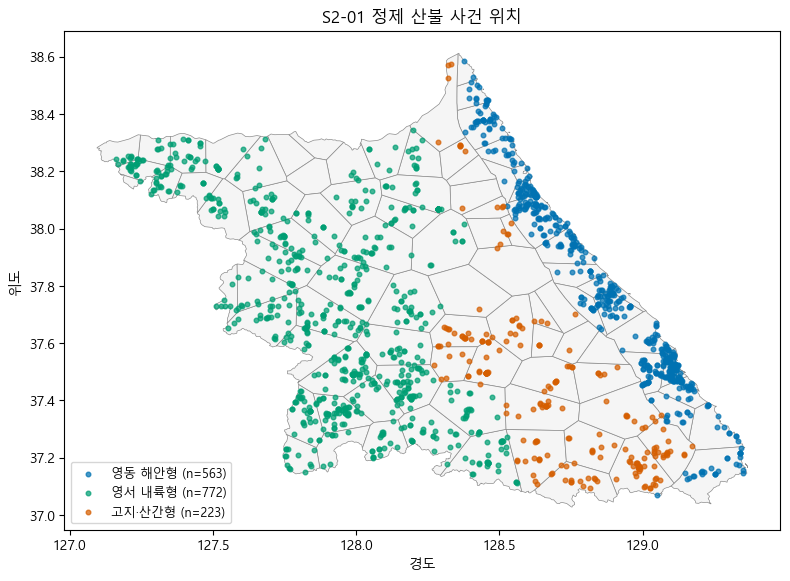

D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\plots\S2-01_cleaned_fire_location_map.png


In [5]:
cleaned_location_plot = PLOT_DIR / "S2-01_cleaned_fire_location_map.png"

type_palette = {
    "영동 해안형": "#0072B2",
    "영서 내륙형": "#009E73",
    "고지·산간형": "#D55E00",
}

fig, ax = plt.subplots(figsize=(8, 9))
grid.plot(ax=ax, facecolor="#f5f5f5", edgecolor="#8c8c8c", linewidth=0.5)
for climate_name, color in type_palette.items():
    subset = clean_fire_gdf[clean_fire_gdf["기후지형유형"] == climate_name]
    if not subset.empty:
        subset.plot(ax=ax, markersize=11, color=color, alpha=0.72, label=f"{climate_name} (n={len(subset)})")
ax.set_title("S2-01 정제 산불 사건 위치")
ax.set_xlabel("경도")
ax.set_ylabel("위도")
ax.legend(loc="lower left", frameon=True, fontsize=9)
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(cleaned_location_plot, dpi=180, bbox_inches="tight")
plt.show()

print(cleaned_location_plot)


### S2-01-4. 미매칭·경계점 위치 지도 저장

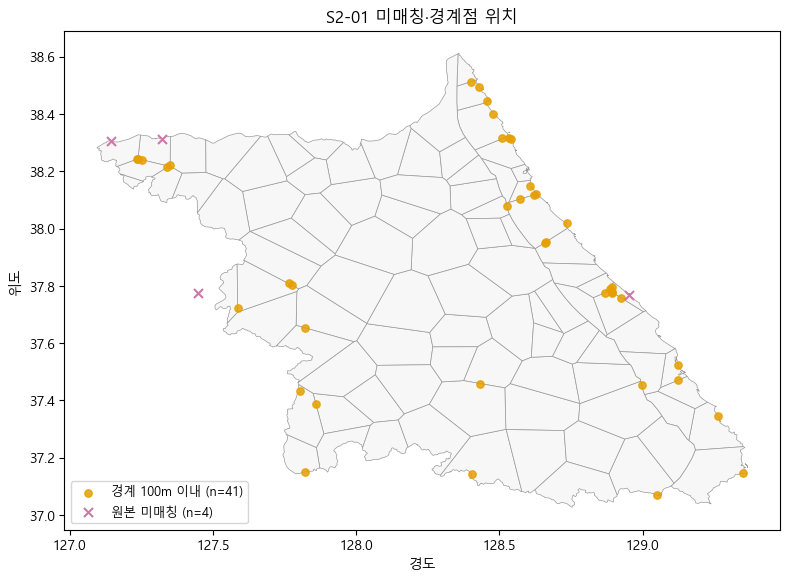

D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\plots\S2-01_unmatched_boundary_location_map.png


In [6]:
boundary_location_plot = PLOT_DIR / "S2-01_unmatched_boundary_location_map.png"

raw_unmatched_gdf = gpd.GeoDataFrame(
    raw_spatial_unmatched.copy(),
    geometry=gpd.points_from_xy(raw_spatial_unmatched["경도"], raw_spatial_unmatched["위도"]) if len(raw_spatial_unmatched) else [],
    crs="EPSG:4326",
)
boundary_points_plot = boundary_points_wgs84.copy()

fig, ax = plt.subplots(figsize=(8, 9))
grid.plot(ax=ax, facecolor="#f7f7f7", edgecolor="#9a9a9a", linewidth=0.5)
if not boundary_points_plot.empty:
    boundary_points_plot.plot(
        ax=ax,
        markersize=28,
        color="#E69F00",
        alpha=0.85,
        label=f"경계 {int(BOUNDARY_DISTANCE_M)}m 이내 (n={len(boundary_points_plot)})",
    )
if not raw_unmatched_gdf.empty:
    raw_unmatched_gdf.plot(
        ax=ax,
        markersize=42,
        color="#CC79A7",
        marker="x",
        linewidth=1.5,
        label=f"원본 미매칭 (n={len(raw_unmatched_gdf)})",
    )
if boundary_points_plot.empty and raw_unmatched_gdf.empty:
    ax.text(0.5, 0.5, "미매칭·경계점 0건", transform=ax.transAxes, ha="center", va="center", fontsize=12)
ax.set_title("S2-01 미매칭·경계점 위치")
ax.set_xlabel("경도")
ax.set_ylabel("위도")
ax.legend(loc="lower left", frameon=True, fontsize=9)
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(boundary_location_plot, dpi=180, bbox_inches="tight")
plt.show()

print(boundary_location_plot)


### S2-01-5. 산출물 목록과 최종 감사 통과 확인

In [7]:
artifact_manifest = pd.DataFrame(
    [
        {
            "artifact_type": "table",
            "filename": filename,
            "path": str(TABLE_DIR / filename),
            "rows": len(df),
            "columns": len(df.columns),
        }
        for filename, df in tables.items()
    ]
    + [
        {
            "artifact_type": "plot",
            "filename": cleaned_location_plot.name,
            "path": str(cleaned_location_plot),
            "rows": np.nan,
            "columns": np.nan,
        },
        {
            "artifact_type": "plot",
            "filename": boundary_location_plot.name,
            "path": str(boundary_location_plot),
            "rows": np.nan,
            "columns": np.nan,
        },
    ]
)
artifact_manifest.to_csv(TABLE_DIR / "S2-01_artifact_manifest.csv", index=False, encoding="utf-8-sig")

fatal_failed_checks = key_quality_audit.loc[~key_quality_audit["pass"]].copy()
display(artifact_manifest)
display(fatal_failed_checks)
assert fatal_failed_checks.empty, fatal_failed_checks.to_string(index=False)

print(f"{ANALYSIS_ID} execution complete")


,artifact_type,filename,path,rows,columns
0,table,S2-01_source_audit.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,6.0,4.0
1,table,S2-01_population_validation.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,16.0,3.0
2,table,S2-01_cleaning_stage_audit.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,5.0,4.0
3,table,S2-01_key_quality_audit.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,12.0,4.0
4,table,S2-01_missingness_audit.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,23.0,5.0
5,table,S2-01_sample_group_counts.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,2.0,2.0
6,table,S2-01_exposure_duplicate_distribution.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,15.0,4.0
7,table,S2-01_unmatched_boundary_out_of_range.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,45.0,9.0
8,table,S2-01_ys0071_audit.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,1.0,6.0
9,table,S2-01_residual_near_duplicate_pairs.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,0.0,0.0


,check_name,value,pass,details


S2-01 execution complete


## S2-01 종료 / S2-02 추가 위치

S2-02 월별·시간대별·권역별 발생 분포 코드는 이 아래에 추가한다.

## S2-02. 정제 산불의 월별·시간대별·권역별 분포

In [8]:
ANALYSIS_ID = "S2-02"
S2_02_PERIOD_START = pd.Timestamp("2020-01-01 00:00:00")
S2_02_PERIOD_END_EXCLUSIVE = pd.Timestamp("2022-01-01 00:00:00")
MONTH_ORDER = list(range(1, 13))
HOUR_ORDER = list(range(24))
TYPE_ORDER = ["영동 해안형", "영서 내륙형", "고지·산간형"]
SEASON_ORDER = ["겨울(12-2월)", "봄(3-5월)", "여름(6-8월)", "가을(9-11월)"]


def season_label(month):
    if month in [12, 1, 2]:
        return "겨울(12-2월)"
    if month in [3, 4, 5]:
        return "봄(3-5월)"
    if month in [6, 7, 8]:
        return "여름(6-8월)"
    return "가을(9-11월)"


s2_fire_before_rows = len(clean_fire)
s2_fire = clean_fire.copy()
s2_fire["기준시각"] = pd.to_datetime(s2_fire["기준시각"])
s2_fire = s2_fire[
    (s2_fire["기준시각"] >= S2_02_PERIOD_START)
    & (s2_fire["기준시각"] < S2_02_PERIOD_END_EXCLUSIVE)
].copy()
s2_fire["month"] = s2_fire["기준시각"].dt.month.astype(int)
s2_fire["hour"] = s2_fire["기준시각"].dt.hour.astype(int)
s2_fire["date"] = s2_fire["기준시각"].dt.date.astype(str)
s2_fire["season"] = s2_fire["month"].map(season_label)

fire_exposures = (
    s2_fire.groupby(["기상셀ID", "기준시각"], as_index=False)
    .agg(
        raw_event_n=("fire_id", "size"),
        fire_ids=("fire_id", lambda values: ";".join(values.astype(str))),
        first_fire_id=("fire_id", "first"),
        first_latitude=("위도", "first"),
        first_longitude=("경도", "first"),
        climate_type=("기후지형유형", "first"),
        climate_type_unique_n=("기후지형유형", "nunique"),
    )
)
fire_exposures["month"] = fire_exposures["기준시각"].dt.month.astype(int)
fire_exposures["hour"] = fire_exposures["기준시각"].dt.hour.astype(int)
fire_exposures["date"] = fire_exposures["기준시각"].dt.date.astype(str)
fire_exposures["season"] = fire_exposures["month"].map(season_label)

weather_population = weather_keys.rename(columns={"일시": "기준시각"}).copy()
weather_population["기준시각"] = pd.to_datetime(weather_population["기준시각"])
weather_population = weather_population[
    (weather_population["기준시각"] >= S2_02_PERIOD_START)
    & (weather_population["기준시각"] < S2_02_PERIOD_END_EXCLUSIVE)
].copy()
weather_population = weather_population.merge(
    climate_type[["기상셀ID", "기후지형유형"]],
    on="기상셀ID",
    how="left",
)
weather_population["month"] = weather_population["기준시각"].dt.month.astype(int)
weather_population["hour"] = weather_population["기준시각"].dt.hour.astype(int)
weather_population["date"] = weather_population["기준시각"].dt.date.astype(str)
weather_population["season"] = weather_population["month"].map(season_label)

analysis_scope = pd.DataFrame(
    [
        {
            "item": "분석 질문",
            "value": "정제 산불의 월별·시간대별·기후지형유형별 집중이 고유 기상 노출 단위와 cell-hour 보정 뒤에도 남는가?",
        },
        {"item": "분석 ID", "value": ANALYSIS_ID},
        {"item": "분석 단위", "value": "정제 사건 fire_id와 고유 기상셀ID×기준시각 노출을 분리 집계"},
        {
            "item": "모집단",
            "value": "data/학습데이터/산불발생_정제.csv 중 2020-01-01 00:00 이상 2022-01-01 00:00 미만",
        },
        {"item": "비교집단", "value": "대조군 미생성. 월·시간·기후지형유형별 cell-hour 배경 모집단 대비 발생 노출률 비교"},
        {"item": "기간", "value": "2020-01-01 00:00:00 <= 기준시각 < 2022-01-01 00:00:00"},
        {
            "item": "통제·층화·매칭 조건",
            "value": "기후지형유형 층화, 월·시간별 cell-hour 노출 보정. 매칭 대조군은 S2-04에서 생성하므로 S2-02에서는 사용하지 않음",
        },
        {"item": "포함 조건", "value": "S2-01 감사 통과 정제 산불과 시간기상 키가 존재하는 92개 기상셀 cell-hour"},
        {"item": "제외 조건", "value": "S2-01 정제 파일 외 원본 미매칭·준중복 제외 행은 포함하지 않음"},
    ]
)

s2_02_scope_path = TABLE_DIR / "S2-02_analysis_scope.csv"
analysis_scope.to_csv(s2_02_scope_path, index=False, encoding="utf-8-sig")
display(analysis_scope)
print(s2_02_scope_path)


,item,value
0,분석 질문,정제 산불의 월별·시간대별·기후지형유형별 집중이 고유 기상 노출 단위와 cell-h...
1,분석 ID,S2-02
2,분석 단위,정제 사건 fire_id와 고유 기상셀ID×기준시각 노출을 분리 집계
3,모집단,data/학습데이터/산불발생_정제.csv 중 2020-01-01 00:00 이상 2...
4,비교집단,대조군 미생성. 월·시간·기후지형유형별 cell-hour 배경 모집단 대비 발생 노...
5,기간,2020-01-01 00:00:00 <= 기준시각 < 2022-01-01 00:00:00
6,통제·층화·매칭 조건,"기후지형유형 층화, 월·시간별 cell-hour 노출 보정. 매칭 대조군은 S2-0..."
7,포함 조건,S2-01 감사 통과 정제 산불과 시간기상 키가 존재하는 92개 기상셀 cell-hour
8,제외 조건,S2-01 정제 파일 외 원본 미매칭·준중복 제외 행은 포함하지 않음


D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\tables\S2-02_analysis_scope.csv


### S2-02-1. 분석 범위·결측·중복·표본 수 감사

In [9]:
from scipy.stats import chi2, chi2_contingency, chisquare, norm


def poisson_rate_ci(count, exposure, scale=100_000, alpha=0.05):
    if exposure <= 0:
        return np.nan, np.nan
    lower = 0.0 if count == 0 else 0.5 * chi2.ppf(alpha / 2, 2 * count) / exposure * scale
    upper = 0.5 * chi2.ppf(1 - alpha / 2, 2 * (count + 1)) / exposure * scale
    return lower, upper


def add_poisson_rate_columns(df, count_col, exposure_col, scale=100_000):
    out = df.copy()
    out["unique_exposure_rate_per_100k_cell_hour"] = np.where(
        out[exposure_col] > 0,
        out[count_col] / out[exposure_col] * scale,
        np.nan,
    )
    ci_values = out.apply(lambda row: poisson_rate_ci(row[count_col], row[exposure_col], scale=scale), axis=1)
    out["rate_ci95_low"] = [value[0] for value in ci_values]
    out["rate_ci95_high"] = [value[1] for value in ci_values]
    return out


def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    q_values = np.full(len(p_values), np.nan)
    valid = ~np.isnan(p_values)
    if not valid.any():
        return q_values
    valid_indices = np.where(valid)[0]
    order = np.argsort(p_values[valid])
    ranked = p_values[valid][order]
    m = len(ranked)
    adjusted = ranked * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)
    q_values[valid_indices[order]] = adjusted
    return q_values


def poisson_rate_contrast(label, group_a, count_a, exposure_a, group_b, count_b, exposure_b, note):
    rate_a = count_a / exposure_a * 100_000 if exposure_a > 0 else np.nan
    rate_b = count_b / exposure_b * 100_000 if exposure_b > 0 else np.nan
    diff = rate_a - rate_b if pd.notna(rate_a) and pd.notna(rate_b) else np.nan
    if count_a > 0 and count_b > 0 and exposure_a > 0 and exposure_b > 0:
        rate_ratio = (count_a / exposure_a) / (count_b / exposure_b)
        se = np.sqrt((1 / count_a) + (1 / count_b))
        log_rr = np.log(rate_ratio)
        ci_low = np.exp(log_rr - 1.96 * se)
        ci_high = np.exp(log_rr + 1.96 * se)
        z_value = log_rr / se
        p_value = 2 * norm.sf(abs(z_value))
    else:
        rate_ratio = np.nan
        ci_low = np.nan
        ci_high = np.nan
        p_value = np.nan
    return {
        "contrast": label,
        "group_a": group_a,
        "group_b": group_b,
        "n_a": int(count_a),
        "n_b": int(count_b),
        "cell_hour_a": int(exposure_a),
        "cell_hour_b": int(exposure_b),
        "rate_a_per_100k_cell_hour": rate_a,
        "rate_b_per_100k_cell_hour": rate_b,
        "rate_difference_per_100k_cell_hour": diff,
        "rate_ratio": rate_ratio,
        "rate_ratio_ci95_low": ci_low,
        "rate_ratio_ci95_high": ci_high,
        "p_value": p_value,
        "effect_size_type": "Poisson rate ratio",
        "note": note,
    }


required_columns = ["fire_id", "기준시각", "위도", "경도", "기상셀ID", "기후지형유형", "월_key", "시간_key"]
missingness_audit = (
    s2_fire[required_columns]
    .isna()
    .sum()
    .rename("missing_n")
    .reset_index()
    .rename(columns={"index": "column"})
)
missingness_audit["dataset"] = "S2-02 clean fire after period filter"
missingness_audit["row_n"] = len(s2_fire)
missingness_audit["missing_pct"] = missingness_audit["missing_n"] / len(s2_fire) * 100

weather_population_duplicate_cell_time = int(weather_population.duplicated(["기상셀ID", "기준시각"]).sum())
exposure_weather_join = fire_exposures[["기상셀ID", "기준시각"]].merge(
    weather_population[["기상셀ID", "기준시각"]],
    on=["기상셀ID", "기준시각"],
    how="left",
    indicator=True,
)
weather_missing_exposure_n = int((exposure_weather_join["_merge"] != "both").sum())

duplicate_key_audit = pd.DataFrame(
    [
        {"check_name": "fire_id duplicate rows", "duplicate_n": int(s2_fire.duplicated(["fire_id"]).sum()), "expected": 0},
        {
            "check_name": "coordinate-time duplicate rows",
            "duplicate_n": int(s2_fire.duplicated(["위도", "경도", "기준시각"]).sum()),
            "expected": 0,
        },
        {
            "check_name": "cell-time extra event rows",
            "duplicate_n": int(len(s2_fire) - len(fire_exposures)),
            "expected": "recorded, not fatal",
        },
        {
            "check_name": "exposure climate type conflicts",
            "duplicate_n": int((fire_exposures["climate_type_unique_n"] > 1).sum()),
            "expected": 0,
        },
        {
            "check_name": "weather population duplicate cell-time rows",
            "duplicate_n": weather_population_duplicate_cell_time,
            "expected": 0,
        },
        {"check_name": "fire exposures missing weather key", "duplicate_n": weather_missing_exposure_n, "expected": 0},
    ]
)

population_validation = pd.DataFrame(
    [
        {"metric": "analysis_id", "value": ANALYSIS_ID, "notes": "월별·시간대별·권역별 발생 분포"},
        {"metric": "period", "value": "2020-01-01 <= 기준시각 < 2022-01-01", "notes": "Step1 고정 범위"},
        {"metric": "clean_fire_rows_before_period_filter", "value": s2_fire_before_rows, "notes": "분석 전 정제 사건 행 수"},
        {"metric": "clean_fire_rows_after_period_filter", "value": len(s2_fire), "notes": "분석 후 정제 사건 행 수"},
        {"metric": "unique_fire_id", "value": s2_fire["fire_id"].nunique(), "notes": "정제 사건 고유 ID"},
        {"metric": "unique_cell_time_exposures", "value": len(fire_exposures), "notes": "고유 기상셀ID×기준시각 노출"},
        {"metric": "control_rows", "value": 0, "notes": "S2-02에서는 대조군을 생성하지 않음"},
        {"metric": "required_key_missing_total", "value": int(missingness_audit["missing_n"].sum()), "notes": "필수 키 결측 총합"},
        {"metric": "fire_id_duplicate_rows", "value": int(s2_fire.duplicated(["fire_id"]).sum()), "notes": "기대값 0"},
        {
            "metric": "coordinate_time_duplicate_rows",
            "value": int(s2_fire.duplicated(["위도", "경도", "기준시각"]).sum()),
            "notes": "기대값 0",
        },
        {
            "metric": "duplicate_cell_time_extra_event_rows",
            "value": int(len(s2_fire) - len(fire_exposures)),
            "notes": "동일 기상 노출 공유 사건 수",
        },
        {"metric": "weather_population_rows", "value": len(weather_population), "notes": "92개 셀의 2020~2021 cell-hour"},
        {"metric": "weather_population_cells", "value": weather_population["기상셀ID"].nunique(), "notes": "Step1 고정 92개 셀"},
        {
            "metric": "weather_population_duplicate_cell_time",
            "value": weather_population_duplicate_cell_time,
            "notes": "기대값 0",
        },
        {"metric": "fire_exposures_missing_weather_key", "value": weather_missing_exposure_n, "notes": "기대값 0"},
    ]
)

sample_group_rows = [
    {
        "sample_group": "정제 산불 사건",
        "climate_type": "전체",
        "row_n": len(s2_fire),
        "unique_fire_id_n": s2_fire["fire_id"].nunique(),
        "unique_exposure_n": len(fire_exposures),
        "cell_n": s2_fire["기상셀ID"].nunique(),
        "cell_hour_n": np.nan,
    },
    {
        "sample_group": "고유 산불 노출",
        "climate_type": "전체",
        "row_n": len(fire_exposures),
        "unique_fire_id_n": np.nan,
        "unique_exposure_n": len(fire_exposures),
        "cell_n": fire_exposures["기상셀ID"].nunique(),
        "cell_hour_n": np.nan,
    },
    {
        "sample_group": "대조군",
        "climate_type": "전체",
        "row_n": 0,
        "unique_fire_id_n": np.nan,
        "unique_exposure_n": 0,
        "cell_n": np.nan,
        "cell_hour_n": np.nan,
    },
]
for climate_name in TYPE_ORDER:
    sample_group_rows.append(
        {
            "sample_group": "기후지형유형별 정제 사건",
            "climate_type": climate_name,
            "row_n": int((s2_fire["기후지형유형"] == climate_name).sum()),
            "unique_fire_id_n": int(s2_fire.loc[s2_fire["기후지형유형"] == climate_name, "fire_id"].nunique()),
            "unique_exposure_n": int((fire_exposures["climate_type"] == climate_name).sum()),
            "cell_n": int(climate_type.loc[climate_type["기후지형유형"] == climate_name, "기상셀ID"].nunique()),
            "cell_hour_n": int((weather_population["기후지형유형"] == climate_name).sum()),
        }
    )
sample_group_counts = pd.DataFrame(sample_group_rows)

month_index = pd.DataFrame({"month": MONTH_ORDER})
monthly_events = s2_fire.groupby("month").agg(raw_event_n=("fire_id", "size"), fire_date_n=("date", "nunique")).reset_index()
monthly_exposures = (
    fire_exposures.groupby("month")
    .agg(
        unique_exposure_n=("기상셀ID", "size"),
        exposure_fire_date_n=("date", "nunique"),
        mean_events_per_exposure=("raw_event_n", "mean"),
        max_events_per_exposure=("raw_event_n", "max"),
    )
    .reset_index()
)
monthly_population = weather_population.groupby("month").size().rename("cell_hour_n").reset_index()
monthly_summary = (
    month_index.merge(monthly_events, on="month", how="left")
    .merge(monthly_exposures, on="month", how="left")
    .merge(monthly_population, on="month", how="left")
)
monthly_summary[["raw_event_n", "fire_date_n", "unique_exposure_n", "exposure_fire_date_n"]] = monthly_summary[
    ["raw_event_n", "fire_date_n", "unique_exposure_n", "exposure_fire_date_n"]
].fillna(0).astype(int)
monthly_summary[["mean_events_per_exposure", "max_events_per_exposure"]] = monthly_summary[
    ["mean_events_per_exposure", "max_events_per_exposure"]
].fillna(0)
monthly_summary = add_poisson_rate_columns(monthly_summary, "unique_exposure_n", "cell_hour_n")
monthly_summary["raw_event_share_pct"] = monthly_summary["raw_event_n"] / monthly_summary["raw_event_n"].sum() * 100
monthly_summary["unique_exposure_share_pct"] = (
    monthly_summary["unique_exposure_n"] / monthly_summary["unique_exposure_n"].sum() * 100
)
monthly_summary["cell_hour_share_pct"] = monthly_summary["cell_hour_n"] / monthly_summary["cell_hour_n"].sum() * 100

hour_index = pd.DataFrame({"hour": HOUR_ORDER})
hourly_events = s2_fire.groupby("hour").agg(raw_event_n=("fire_id", "size"), fire_date_n=("date", "nunique")).reset_index()
hourly_exposures = (
    fire_exposures.groupby("hour")
    .agg(
        unique_exposure_n=("기상셀ID", "size"),
        exposure_fire_date_n=("date", "nunique"),
        mean_events_per_exposure=("raw_event_n", "mean"),
        max_events_per_exposure=("raw_event_n", "max"),
    )
    .reset_index()
)
hourly_population = weather_population.groupby("hour").size().rename("cell_hour_n").reset_index()
hourly_summary = (
    hour_index.merge(hourly_events, on="hour", how="left")
    .merge(hourly_exposures, on="hour", how="left")
    .merge(hourly_population, on="hour", how="left")
)
hourly_summary[["raw_event_n", "fire_date_n", "unique_exposure_n", "exposure_fire_date_n"]] = hourly_summary[
    ["raw_event_n", "fire_date_n", "unique_exposure_n", "exposure_fire_date_n"]
].fillna(0).astype(int)
hourly_summary[["mean_events_per_exposure", "max_events_per_exposure"]] = hourly_summary[
    ["mean_events_per_exposure", "max_events_per_exposure"]
].fillna(0)
hourly_summary = add_poisson_rate_columns(hourly_summary, "unique_exposure_n", "cell_hour_n")
hourly_summary["raw_event_share_pct"] = hourly_summary["raw_event_n"] / hourly_summary["raw_event_n"].sum() * 100
hourly_summary["unique_exposure_share_pct"] = hourly_summary["unique_exposure_n"] / hourly_summary["unique_exposure_n"].sum() * 100
hourly_summary["cell_hour_share_pct"] = hourly_summary["cell_hour_n"] / hourly_summary["cell_hour_n"].sum() * 100

type_index = pd.DataFrame({"climate_type": TYPE_ORDER})
type_events = (
    s2_fire.groupby("기후지형유형")
    .agg(raw_event_n=("fire_id", "size"), fire_date_n=("date", "nunique"), fire_cell_n=("기상셀ID", "nunique"))
    .rename_axis("climate_type")
    .reset_index()
)
type_exposures = (
    fire_exposures.groupby("climate_type")
    .agg(
        unique_exposure_n=("기상셀ID", "size"),
        exposure_fire_date_n=("date", "nunique"),
        exposure_cell_n=("기상셀ID", "nunique"),
        mean_events_per_exposure=("raw_event_n", "mean"),
        max_events_per_exposure=("raw_event_n", "max"),
    )
    .reset_index()
)
type_population = (
    weather_population.groupby("기후지형유형")
    .agg(cell_hour_n=("기상셀ID", "size"), cell_n=("기상셀ID", "nunique"))
    .rename_axis("climate_type")
    .reset_index()
)
type_summary = (
    type_index.merge(type_events, on="climate_type", how="left")
    .merge(type_exposures, on="climate_type", how="left")
    .merge(type_population, on="climate_type", how="left")
)
for col in ["raw_event_n", "fire_date_n", "fire_cell_n", "unique_exposure_n", "exposure_fire_date_n", "exposure_cell_n", "cell_hour_n", "cell_n"]:
    type_summary[col] = type_summary[col].fillna(0).astype(int)
type_summary[["mean_events_per_exposure", "max_events_per_exposure"]] = type_summary[
    ["mean_events_per_exposure", "max_events_per_exposure"]
].fillna(0)
type_summary = add_poisson_rate_columns(type_summary, "unique_exposure_n", "cell_hour_n")
type_summary["raw_event_share_pct"] = type_summary["raw_event_n"] / type_summary["raw_event_n"].sum() * 100
type_summary["unique_exposure_share_pct"] = type_summary["unique_exposure_n"] / type_summary["unique_exposure_n"].sum() * 100
type_summary["cell_hour_share_pct"] = type_summary["cell_hour_n"] / type_summary["cell_hour_n"].sum() * 100

type_month_index = pd.MultiIndex.from_product([TYPE_ORDER, MONTH_ORDER], names=["climate_type", "month"]).to_frame(index=False)
type_month_events = (
    s2_fire.groupby(["기후지형유형", "month"])
    .agg(raw_event_n=("fire_id", "size"), fire_date_n=("date", "nunique"))
    .rename_axis(["climate_type", "month"])
    .reset_index()
)
type_month_exposures = (
    fire_exposures.groupby(["climate_type", "month"])
    .agg(unique_exposure_n=("기상셀ID", "size"), exposure_fire_date_n=("date", "nunique"))
    .reset_index()
)
type_month_population = (
    weather_population.groupby(["기후지형유형", "month"])
    .size()
    .rename("cell_hour_n")
    .rename_axis(["climate_type", "month"])
    .reset_index()
)
type_month_summary = (
    type_month_index.merge(type_month_events, on=["climate_type", "month"], how="left")
    .merge(type_month_exposures, on=["climate_type", "month"], how="left")
    .merge(type_month_population, on=["climate_type", "month"], how="left")
)
for col in ["raw_event_n", "fire_date_n", "unique_exposure_n", "exposure_fire_date_n"]:
    type_month_summary[col] = type_month_summary[col].fillna(0).astype(int)
type_month_summary = add_poisson_rate_columns(type_month_summary, "unique_exposure_n", "cell_hour_n")

type_season_index = pd.MultiIndex.from_product([TYPE_ORDER, SEASON_ORDER], names=["climate_type", "season"]).to_frame(index=False)
type_season_events = (
    s2_fire.groupby(["기후지형유형", "season"])
    .agg(raw_event_n=("fire_id", "size"), fire_date_n=("date", "nunique"))
    .rename_axis(["climate_type", "season"])
    .reset_index()
)
type_season_exposures = (
    fire_exposures.groupby(["climate_type", "season"])
    .agg(unique_exposure_n=("기상셀ID", "size"), exposure_fire_date_n=("date", "nunique"))
    .reset_index()
)
type_season_population = (
    weather_population.groupby(["기후지형유형", "season"])
    .size()
    .rename("cell_hour_n")
    .rename_axis(["climate_type", "season"])
    .reset_index()
)
type_season_summary = (
    type_season_index.merge(type_season_events, on=["climate_type", "season"], how="left")
    .merge(type_season_exposures, on=["climate_type", "season"], how="left")
    .merge(type_season_population, on=["climate_type", "season"], how="left")
)
for col in ["raw_event_n", "fire_date_n", "unique_exposure_n", "exposure_fire_date_n"]:
    type_season_summary[col] = type_season_summary[col].fillna(0).astype(int)
type_season_summary = add_poisson_rate_columns(type_season_summary, "unique_exposure_n", "cell_hour_n")

date_cluster_summary = (
    fire_exposures.groupby(["date", "month"], as_index=False)
    .agg(
        unique_exposure_n=("기상셀ID", "size"),
        raw_event_n=("raw_event_n", "sum"),
        climate_type_n=("climate_type", "nunique"),
        cell_n=("기상셀ID", "nunique"),
    )
    .sort_values(["unique_exposure_n", "raw_event_n"], ascending=False)
    .reset_index(drop=True)
)
date_cluster_summary["rank_by_unique_exposure"] = np.arange(1, len(date_cluster_summary) + 1)

monthly_top_date = date_cluster_summary.sort_values(["month", "unique_exposure_n", "raw_event_n"], ascending=[True, False, False])
monthly_top_date = monthly_top_date.groupby("month", as_index=False).head(1)
monthly_top3 = (
    date_cluster_summary.sort_values(["month", "unique_exposure_n", "raw_event_n"], ascending=[True, False, False])
    .groupby("month", as_index=False)
    .head(3)
    .groupby("month", as_index=False)
    .agg(top3_unique_exposure_n=("unique_exposure_n", "sum"), top3_raw_event_n=("raw_event_n", "sum"))
)
monthly_summary = monthly_summary.merge(
    monthly_top_date[["month", "date", "unique_exposure_n", "raw_event_n"]].rename(
        columns={
            "date": "top_date",
            "unique_exposure_n": "top_date_unique_exposure_n",
            "raw_event_n": "top_date_raw_event_n",
        }
    ),
    on="month",
    how="left",
).merge(monthly_top3, on="month", how="left")
monthly_summary[["top_date_unique_exposure_n", "top_date_raw_event_n", "top3_unique_exposure_n", "top3_raw_event_n"]] = monthly_summary[
    ["top_date_unique_exposure_n", "top_date_raw_event_n", "top3_unique_exposure_n", "top3_raw_event_n"]
].fillna(0).astype(int)
monthly_summary["top_date_share_of_month_exposures_pct"] = np.where(
    monthly_summary["unique_exposure_n"] > 0,
    monthly_summary["top_date_unique_exposure_n"] / monthly_summary["unique_exposure_n"] * 100,
    np.nan,
)
monthly_summary["top3_dates_share_of_month_exposures_pct"] = np.where(
    monthly_summary["unique_exposure_n"] > 0,
    monthly_summary["top3_unique_exposure_n"] / monthly_summary["unique_exposure_n"] * 100,
    np.nan,
)

stats_rows = []

month_observed = monthly_summary["unique_exposure_n"].to_numpy()
month_expected = month_observed.sum() * monthly_summary["cell_hour_n"].to_numpy() / monthly_summary["cell_hour_n"].sum()
month_stat, month_p = chisquare(month_observed, f_exp=month_expected)
stats_rows.append(
    {
        "test_name": "월별 고유 노출 분포 vs cell-hour 배경",
        "n": int(month_observed.sum()),
        "df": len(month_observed) - 1,
        "statistic": month_stat,
        "p_value": month_p,
        "effect_size_type": "Cohen's w",
        "effect_size": np.sqrt(month_stat / month_observed.sum()),
        "representative_pattern": f"{int(monthly_summary.loc[monthly_summary['unique_exposure_rate_per_100k_cell_hour'].idxmax(), 'month'])}월 노출률 최대",
    }
)

hour_observed = hourly_summary["unique_exposure_n"].to_numpy()
hour_expected = hour_observed.sum() * hourly_summary["cell_hour_n"].to_numpy() / hourly_summary["cell_hour_n"].sum()
hour_stat, hour_p = chisquare(hour_observed, f_exp=hour_expected)
stats_rows.append(
    {
        "test_name": "시간대별 고유 노출 분포 vs cell-hour 배경",
        "n": int(hour_observed.sum()),
        "df": len(hour_observed) - 1,
        "statistic": hour_stat,
        "p_value": hour_p,
        "effect_size_type": "Cohen's w",
        "effect_size": np.sqrt(hour_stat / hour_observed.sum()),
        "representative_pattern": f"{int(hourly_summary.loc[hourly_summary['unique_exposure_rate_per_100k_cell_hour'].idxmax(), 'hour'])}시 노출률 최대",
    }
)

type_observed = type_summary["unique_exposure_n"].to_numpy()
type_expected = type_observed.sum() * type_summary["cell_hour_n"].to_numpy() / type_summary["cell_hour_n"].sum()
type_stat, type_p = chisquare(type_observed, f_exp=type_expected)
stats_rows.append(
    {
        "test_name": "기후지형유형별 고유 노출 분포 vs cell-hour 배경",
        "n": int(type_observed.sum()),
        "df": len(type_observed) - 1,
        "statistic": type_stat,
        "p_value": type_p,
        "effect_size_type": "Cohen's w",
        "effect_size": np.sqrt(type_stat / type_observed.sum()),
        "representative_pattern": f"{type_summary.loc[type_summary['unique_exposure_rate_per_100k_cell_hour'].idxmax(), 'climate_type']} 노출률 최대",
    }
)

type_month_table = pd.crosstab(
    pd.Categorical(fire_exposures["climate_type"], categories=TYPE_ORDER, ordered=True),
    pd.Categorical(fire_exposures["month"], categories=MONTH_ORDER, ordered=True),
)
type_month_chi2, type_month_p, type_month_df, _ = chi2_contingency(type_month_table)
stats_rows.append(
    {
        "test_name": "산불 노출 내부 기후지형유형×월 독립성",
        "n": int(type_month_table.to_numpy().sum()),
        "df": int(type_month_df),
        "statistic": type_month_chi2,
        "p_value": type_month_p,
        "effect_size_type": "Cramer's V",
        "effect_size": np.sqrt(type_month_chi2 / (type_month_table.to_numpy().sum() * min(type_month_table.shape[0] - 1, type_month_table.shape[1] - 1))),
        "representative_pattern": "유형별 월 구성 차이 검정",
    }
)

type_season_table = pd.crosstab(
    pd.Categorical(fire_exposures["climate_type"], categories=TYPE_ORDER, ordered=True),
    pd.Categorical(fire_exposures["season"], categories=SEASON_ORDER, ordered=True),
)
type_season_chi2, type_season_p, type_season_df, _ = chi2_contingency(type_season_table)
stats_rows.append(
    {
        "test_name": "산불 노출 내부 기후지형유형×계절 독립성",
        "n": int(type_season_table.to_numpy().sum()),
        "df": int(type_season_df),
        "statistic": type_season_chi2,
        "p_value": type_season_p,
        "effect_size_type": "Cramer's V",
        "effect_size": np.sqrt(type_season_chi2 / (type_season_table.to_numpy().sum() * min(type_season_table.shape[0] - 1, type_season_table.shape[1] - 1))),
        "representative_pattern": "유형별 계절 구성 차이 검정",
    }
)

distribution_tests = pd.DataFrame(stats_rows)
distribution_tests["q_value_bh"] = benjamini_hochberg(distribution_tests["p_value"])

contrast_rows = []
total_count = int(len(fire_exposures))
total_cell_hours = int(len(weather_population))
peak_month_row = monthly_summary.loc[monthly_summary["unique_exposure_rate_per_100k_cell_hour"].idxmax()]
for fixed_month in [int(peak_month_row["month"]), 2, 10]:
    row = monthly_summary.loc[monthly_summary["month"] == fixed_month].iloc[0]
    contrast_rows.append(
        poisson_rate_contrast(
            label=f"{fixed_month}월 vs 나머지 월",
            group_a=f"{fixed_month}월",
            count_a=int(row["unique_exposure_n"]),
            exposure_a=int(row["cell_hour_n"]),
            group_b="나머지 월",
            count_b=total_count - int(row["unique_exposure_n"]),
            exposure_b=total_cell_hours - int(row["cell_hour_n"]),
            note="월별 노출률 비교. 최고월은 탐색 선택이며 2월·10월은 사전 확인 월",
        )
    )

peak_hour_row = hourly_summary.loc[hourly_summary["unique_exposure_rate_per_100k_cell_hour"].idxmax()]
contrast_rows.append(
    poisson_rate_contrast(
        label=f"{int(peak_hour_row['hour'])}시 vs 나머지 시간",
        group_a=f"{int(peak_hour_row['hour'])}시",
        count_a=int(peak_hour_row["unique_exposure_n"]),
        exposure_a=int(peak_hour_row["cell_hour_n"]),
        group_b="나머지 시간",
        count_b=total_count - int(peak_hour_row["unique_exposure_n"]),
        exposure_b=total_cell_hours - int(peak_hour_row["cell_hour_n"]),
        note="시간대별 최고 노출률 탐색 비교",
    )
)

peak_type_row = type_summary.loc[type_summary["unique_exposure_rate_per_100k_cell_hour"].idxmax()]
contrast_rows.append(
    poisson_rate_contrast(
        label=f"{peak_type_row['climate_type']} vs 나머지 유형",
        group_a=peak_type_row["climate_type"],
        count_a=int(peak_type_row["unique_exposure_n"]),
        exposure_a=int(peak_type_row["cell_hour_n"]),
        group_b="나머지 유형",
        count_b=total_count - int(peak_type_row["unique_exposure_n"]),
        exposure_b=total_cell_hours - int(peak_type_row["cell_hour_n"]),
        note="기후지형유형별 최고 노출률 탐색 비교",
    )
)

for climate_name, season_name in [("영동 해안형", "겨울(12-2월)"), ("영서 내륙형", "봄(3-5월)"), ("고지·산간형", "봄(3-5월)")]:
    target = type_season_summary[
        (type_season_summary["climate_type"] == climate_name) & (type_season_summary["season"] == season_name)
    ].iloc[0]
    within_type = type_season_summary[type_season_summary["climate_type"] == climate_name]
    contrast_rows.append(
        poisson_rate_contrast(
            label=f"{climate_name} {season_name} vs 같은 유형 나머지 계절",
            group_a=f"{climate_name} {season_name}",
            count_a=int(target["unique_exposure_n"]),
            exposure_a=int(target["cell_hour_n"]),
            group_b=f"{climate_name} 나머지 계절",
            count_b=int(within_type["unique_exposure_n"].sum() - target["unique_exposure_n"]),
            exposure_b=int(within_type["cell_hour_n"].sum() - target["cell_hour_n"]),
            note="Step1 사전 질문에 맞춘 유형 내 계절 노출률 비교",
        )
    )

key_rate_contrasts = pd.DataFrame(contrast_rows).drop_duplicates(subset=["contrast", "group_a", "group_b"]).reset_index(drop=True)
key_rate_contrasts["q_value_bh"] = benjamini_hochberg(key_rate_contrasts["p_value"])

s2_02_tables = {
    "S2-02_population_validation.csv": population_validation,
    "S2-02_missingness_audit.csv": missingness_audit,
    "S2-02_duplicate_key_audit.csv": duplicate_key_audit,
    "S2-02_sample_group_counts.csv": sample_group_counts,
    "S2-02_monthly_event_exposure_counts.csv": monthly_summary,
    "S2-02_hourly_event_exposure_counts.csv": hourly_summary,
    "S2-02_climate_type_counts_rates.csv": type_summary,
    "S2-02_climate_type_monthly_rates.csv": type_month_summary,
    "S2-02_climate_type_season_rates.csv": type_season_summary,
    "S2-02_date_cluster_summary.csv": date_cluster_summary,
    "S2-02_distribution_tests.csv": distribution_tests,
    "S2-02_key_rate_contrasts.csv": key_rate_contrasts,
    "S2-02_unique_weather_exposures.csv": fire_exposures,
}

for filename, df in s2_02_tables.items():
    df.to_csv(TABLE_DIR / filename, index=False, encoding="utf-8-sig")

display(population_validation)
display(monthly_summary)
display(hourly_summary.head(24))
display(type_summary)
display(distribution_tests)
display(key_rate_contrasts)

assert len(s2_fire) == s2_fire_before_rows
assert int(missingness_audit["missing_n"].sum()) == 0
assert int(s2_fire.duplicated(["fire_id"]).sum()) == 0
assert int(s2_fire.duplicated(["위도", "경도", "기준시각"]).sum()) == 0
assert int((fire_exposures["climate_type_unique_n"] > 1).sum()) == 0
assert weather_population_duplicate_cell_time == 0
assert weather_missing_exposure_n == 0


,metric,value,notes
0,analysis_id,S2-02,월별·시간대별·권역별 발생 분포
1,period,2020-01-01 <= 기준시각 < 2022-01-01,Step1 고정 범위
2,clean_fire_rows_before_period_filter,1558,분석 전 정제 사건 행 수
3,clean_fire_rows_after_period_filter,1558,분석 후 정제 사건 행 수
4,unique_fire_id,1558,정제 사건 고유 ID
5,unique_cell_time_exposures,1150,고유 기상셀ID×기준시각 노출
6,control_rows,0,S2-02에서는 대조군을 생성하지 않음
7,required_key_missing_total,0,필수 키 결측 총합
8,fire_id_duplicate_rows,0,기대값 0
9,coordinate_time_duplicate_rows,0,기대값 0


,month,raw_event_n,fire_date_n,unique_exposure_n,exposure_fire_date_n,mean_events_per_exposure,max_events_per_exposure,cell_hour_n,unique_exposure_rate_per_100k_cell_hour,rate_ci95_low,rate_ci95_high,raw_event_share_pct,unique_exposure_share_pct,cell_hour_share_pct,top_date,top_date_unique_exposure_n,top_date_raw_event_n,top3_unique_exposure_n,top3_raw_event_n,top_date_share_of_month_exposures_pct,top3_dates_share_of_month_exposures_pct
0,1,117,39,107,39,1.093458,3,136896,78.161524,64.055255,94.450201,7.509628,9.304348,8.481532,2021-01-29,17,21,29,34,15.887850,27.102804
1,2,698,42,390,42,1.789744,31,125856,309.877956,279.882957,342.211786,44.801027,33.913043,7.797538,2021-02-01,60,169,146,430,15.384615,37.435897
2,3,188,45,162,45,1.160494,3,136896,118.338008,100.816647,138.029180,12.066752,14.086957,8.481532,2021-03-11,12,13,30,36,7.407407,18.518519
3,4,242,47,208,47,1.163462,4,132480,157.004831,136.391708,179.853422,15.532734,18.086957,8.207934,2021-04-24,10,11,26,29,4.807692,12.500000
4,5,104,29,89,29,1.168539,5,136896,65.012856,52.210662,80.003914,6.675225,7.739130,8.481532,2020-05-01,9,10,24,28,10.112360,26.966292
5,6,24,13,23,13,1.043478,2,132480,17.361111,11.005455,26.050191,1.540436,2.000000,8.207934,2020-06-23,5,5,10,11,21.739130,43.478261
6,7,4,4,4,4,1.000000,1,136896,2.921926,0.796127,7.481291,0.256739,0.347826,8.481532,2020-07-03,1,1,3,3,25.000000,75.000000
7,8,1,1,1,1,1.000000,1,136896,0.730482,0.018494,4.069983,0.064185,0.086957,8.481532,2020-08-03,1,1,1,1,100.000000,100.000000
8,9,3,3,3,3,1.000000,1,132480,2.264493,0.466993,6.617809,0.192555,0.260870,8.207934,2020-09-03,1,1,3,3,33.333333,100.000000
9,10,86,21,79,21,1.088608,2,136896,57.708041,45.688000,71.921438,5.519897,6.869565,8.481532,2020-10-21,11,11,29,33,13.924051,36.708861


,hour,raw_event_n,fire_date_n,unique_exposure_n,exposure_fire_date_n,mean_events_per_exposure,max_events_per_exposure,cell_hour_n,unique_exposure_rate_per_100k_cell_hour,rate_ci95_low,rate_ci95_high,raw_event_share_pct,unique_exposure_share_pct,cell_hour_share_pct
0,0,3,3,3,3,1.000000,1,67252,4.460834,0.919931,13.036450,0.192555,0.260870,4.166667
1,1,3,3,3,3,1.000000,1,67252,4.460834,0.919931,13.036450,0.192555,0.260870,4.166667
2,2,2,2,2,2,1.000000,1,67252,2.973889,0.360152,10.742711,0.128370,0.173913,4.166667
3,3,4,4,4,4,1.000000,1,67252,5.947779,1.620569,15.228675,0.256739,0.347826,4.166667
4,4,2,2,2,2,1.000000,1,67252,2.973889,0.360152,10.742711,0.128370,0.173913,4.166667
5,5,6,6,6,6,1.000000,1,67252,8.921668,3.274095,19.418715,0.385109,0.521739,4.166667
6,6,12,11,12,11,1.000000,1,67252,17.843336,9.219912,31.168716,0.770218,1.043478,4.166667
7,7,14,14,14,14,1.000000,1,67252,20.817225,11.380970,34.927766,0.898588,1.217391,4.166667
8,8,40,35,40,35,1.000000,1,67252,59.477785,42.491802,80.991862,2.567394,3.478261,4.166667
9,9,133,79,117,79,1.136752,5,67252,173.972521,143.880015,208.501501,8.536585,10.173913,4.166667


,climate_type,raw_event_n,fire_date_n,fire_cell_n,unique_exposure_n,exposure_fire_date_n,exposure_cell_n,mean_events_per_exposure,max_events_per_exposure,cell_hour_n,cell_n,unique_exposure_rate_per_100k_cell_hour,rate_ci95_low,rate_ci95_high,raw_event_share_pct,unique_exposure_share_pct,cell_hour_share_pct
0,영동 해안형,563,165,21,354,165,21,1.590395,31,368424,21,96.084946,86.335199,106.634310,36.136072,30.782609,22.826087
1,영서 내륙형,772,208,41,615,208,41,1.255285,27,771936,44,79.669817,73.496825,86.222840,49.550706,53.478261,47.826087
2,고지·산간형,223,101,25,181,101,25,1.232044,6,473688,27,38.210805,32.846710,44.201121,14.313222,15.739130,29.347826


,test_name,n,df,statistic,p_value,effect_size_type,effect_size,representative_pattern,q_value_bh
0,월별 고유 노출 분포 vs cell-hour 배경,1150,11,1579.644276,0.000000e+00,Cohen's w,1.172008,2월 노출률 최대,0.000000e+00
1,시간대별 고유 노출 분포 vs cell-hour 배경,1150,23,1044.476522,4.631310e-206,Cohen's w,0.953017,10시 노출률 최대,1.157827e-205
2,기후지형유형별 고유 노출 분포 vs cell-hour 배경,1150,2,112.145734,4.444914e-25,Cohen's w,0.312279,영동 해안형 노출률 최대,7.408190e-25
3,산불 노출 내부 기후지형유형×월 독립성,1150,22,60.255297,2.048553e-05,Cramer's V,0.161858,유형별 월 구성 차이 검정,2.048553e-05
4,산불 노출 내부 기후지형유형×계절 독립성,1150,6,35.529886,3.401571e-06,Cramer's V,0.124289,유형별 계절 구성 차이 검정,4.251963e-06


,contrast,group_a,group_b,n_a,n_b,cell_hour_a,cell_hour_b,rate_a_per_100k_cell_hour,rate_b_per_100k_cell_hour,rate_difference_per_100k_cell_hour,rate_ratio,rate_ratio_ci95_low,rate_ratio_ci95_high,p_value,effect_size_type,note,q_value_bh
0,2월 vs 나머지 월,2월,나머지 월,390,760,125856,1488192,309.877956,51.068679,258.809276,6.067867,5.370501,6.855787,3.156871e-184,Poisson rate ratio,월별 노출률 비교. 최고월은 탐색 선택이며 2월·10월은 사전 확인 월,2.209810e-183
1,10월 vs 나머지 월,10월,나머지 월,79,1071,136896,1477152,57.708041,72.504387,-14.796346,0.795925,0.633335,1.000255,5.025197e-02,Poisson rate ratio,월별 노출률 비교. 최고월은 탐색 선택이며 2월·10월은 사전 확인 월,5.025197e-02
2,10시 vs 나머지 시간,10시,나머지 시간,130,1020,67252,1546796,193.302801,65.942762,127.360040,2.931373,2.442302,3.518379,7.521608e-31,Poisson rate ratio,시간대별 최고 노출률 탐색 비교,1.316281e-30
3,영동 해안형 vs 나머지 유형,영동 해안형,나머지 유형,354,796,368424,1245624,96.084946,63.903714,32.181231,1.503589,1.326631,1.704152,1.721514e-10,Poisson rate ratio,기후지형유형별 최고 노출률 탐색 비교,2.410119e-10
4,영동 해안형 겨울(12-2월) vs 같은 유형 나머지 계절,영동 해안형 겨울(12-2월),영동 해안형 나머지 계절,194,160,91224,277200,212.663334,57.720058,154.943276,3.684392,2.988562,4.542234,2.695907e-34,Poisson rate ratio,Step1 사전 질문에 맞춘 유형 내 계절 노출률 비교,9.435673e-34
5,영서 내륙형 봄(3-5월) vs 같은 유형 나머지 계절,영서 내륙형 봄(3-5월),영서 내륙형 나머지 계절,291,324,194304,577632,149.765316,56.091075,93.674241,2.670038,2.279133,3.127990,5.075187e-34,Poisson rate ratio,Step1 사전 질문에 맞춘 유형 내 계절 노출률 비교,1.184210e-33
6,고지·산간형 봄(3-5월) vs 같은 유형 나머지 계절,고지·산간형 봄(3-5월),고지·산간형 나머지 계절,64,117,119232,354456,53.676865,33.008328,20.668537,1.626161,1.199008,2.205491,1.763815e-03,Poisson rate ratio,Step1 사전 질문에 맞춘 유형 내 계절 노출률 비교,2.057784e-03


### S2-02-2. 핵심 플롯 저장

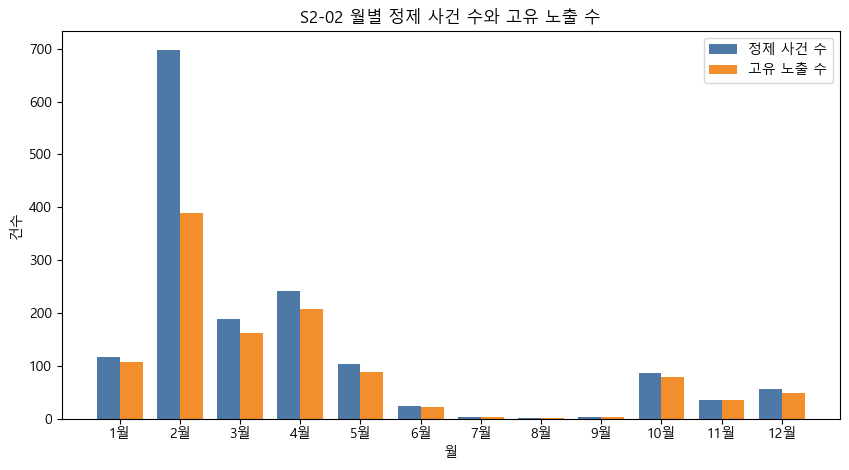

D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\plots\S2-02_monthly_event_count.png


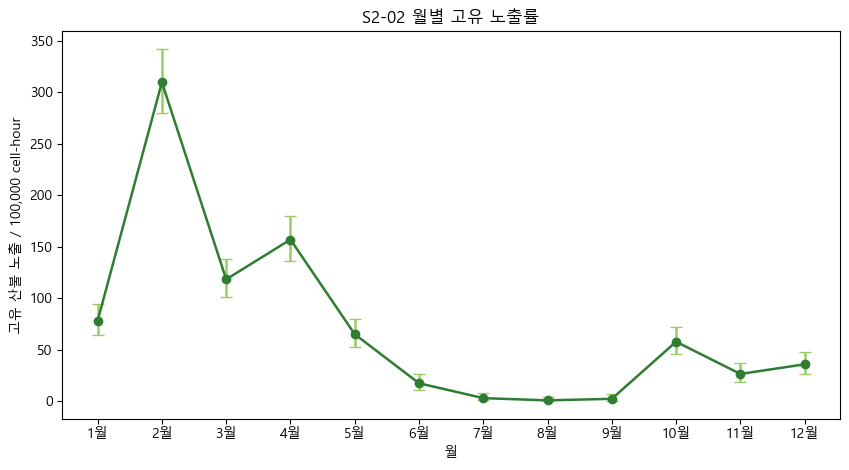

D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\plots\S2-02_monthly_exposure_rate.png


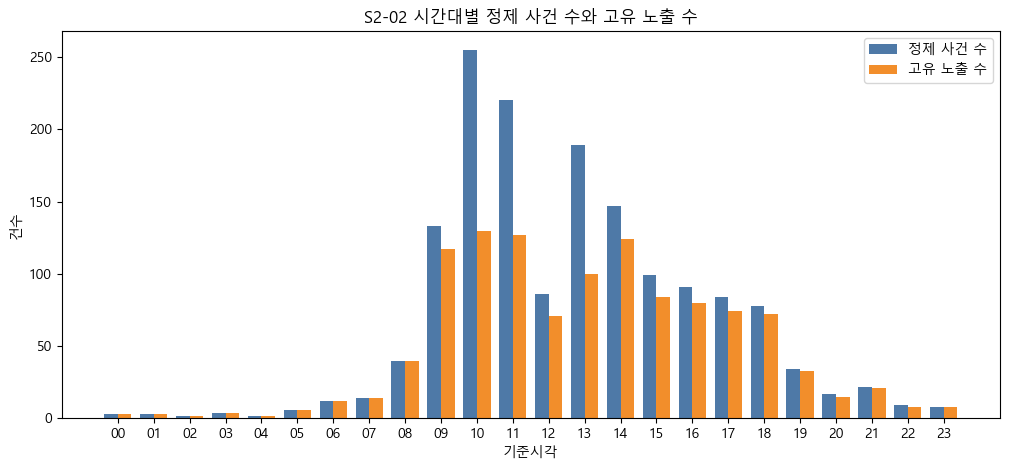

D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\plots\S2-02_hourly_event_count.png


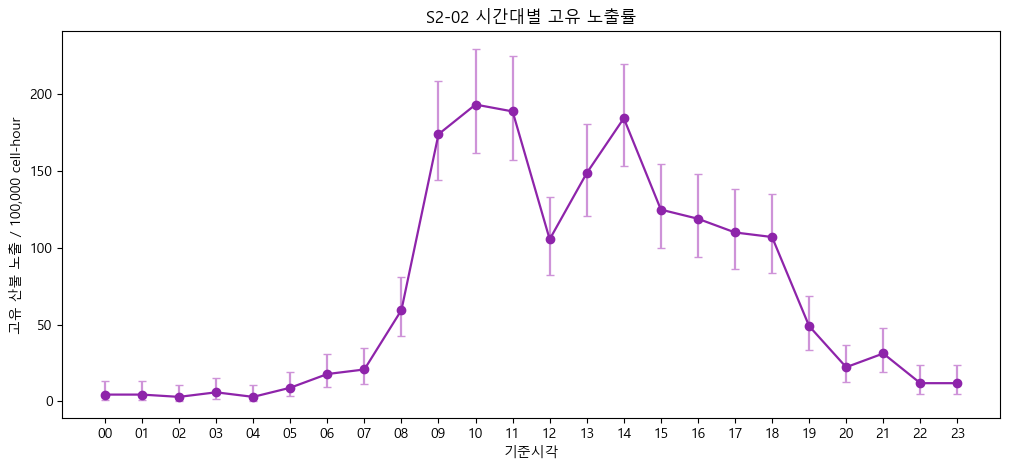

D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\plots\S2-02_hourly_exposure_rate.png


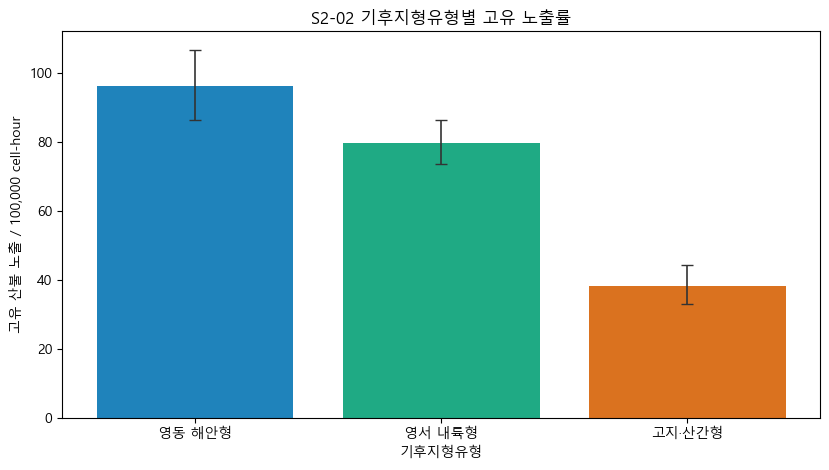

D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\plots\S2-02_climate_type_exposure_rate.png


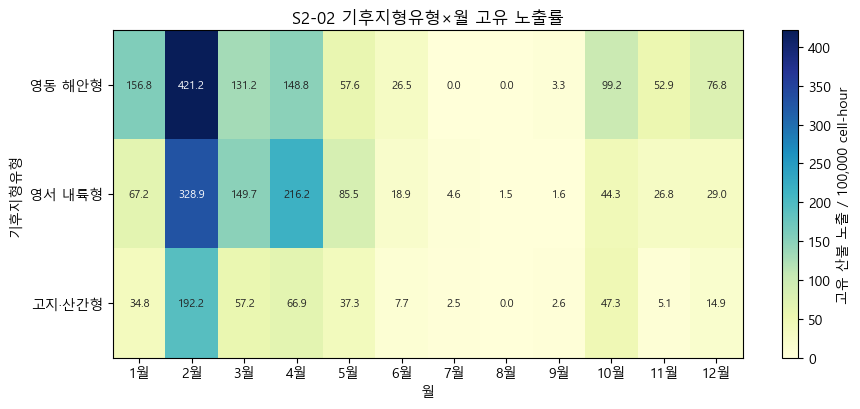

D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\plots\S2-02_climate_type_monthly_rate_heatmap.png


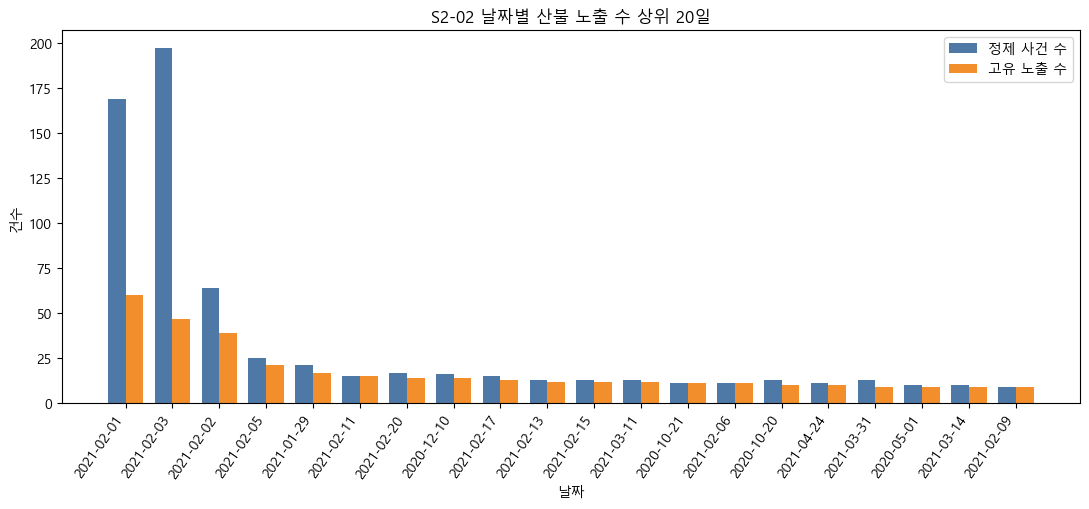

D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\plots\S2-02_daily_cluster_top_dates.png


WindowsPath('D:/farm-system-public-02/jsw/강원_재_EDA/outputs/Step2/plots/S2-02_daily_cluster_top_dates.png')

In [10]:
s2_02_plot_paths = []


def save_s2_02_plot(fig, filename):
    path = PLOT_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    s2_02_plot_paths.append(path)
    print(path)
    return path


month_labels = [f"{month}월" for month in MONTH_ORDER]
hour_labels = [f"{hour:02d}" for hour in HOUR_ORDER]

fig, ax = plt.subplots(figsize=(8.6, 4.8))
x = np.arange(len(monthly_summary))
width = 0.38
ax.bar(x - width / 2, monthly_summary["raw_event_n"], width=width, color="#4E79A7", label="정제 사건 수")
ax.bar(x + width / 2, monthly_summary["unique_exposure_n"], width=width, color="#F28E2B", label="고유 노출 수")
ax.set_title("S2-02 월별 정제 사건 수와 고유 노출 수")
ax.set_xlabel("월")
ax.set_ylabel("건수")
ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.legend(frameon=True)
save_s2_02_plot(fig, "S2-02_monthly_event_count.png")

fig, ax = plt.subplots(figsize=(8.6, 4.8))
rate = monthly_summary["unique_exposure_rate_per_100k_cell_hour"].to_numpy()
yerr = np.vstack([
    rate - monthly_summary["rate_ci95_low"].to_numpy(),
    monthly_summary["rate_ci95_high"].to_numpy() - rate,
])
ax.errorbar(x, rate, yerr=yerr, fmt="o-", color="#2E7D32", ecolor="#9CCC65", capsize=4, linewidth=1.8)
ax.set_title("S2-02 월별 고유 노출률")
ax.set_xlabel("월")
ax.set_ylabel("고유 산불 노출 / 100,000 cell-hour")
ax.set_xticks(x)
ax.set_xticklabels(month_labels)
save_s2_02_plot(fig, "S2-02_monthly_exposure_rate.png")

fig, ax = plt.subplots(figsize=(10.2, 4.8))
x = np.arange(len(hourly_summary))
width = 0.38
ax.bar(x - width / 2, hourly_summary["raw_event_n"], width=width, color="#4E79A7", label="정제 사건 수")
ax.bar(x + width / 2, hourly_summary["unique_exposure_n"], width=width, color="#F28E2B", label="고유 노출 수")
ax.set_title("S2-02 시간대별 정제 사건 수와 고유 노출 수")
ax.set_xlabel("기준시각")
ax.set_ylabel("건수")
ax.set_xticks(x)
ax.set_xticklabels(hour_labels, rotation=0)
ax.legend(frameon=True)
save_s2_02_plot(fig, "S2-02_hourly_event_count.png")

fig, ax = plt.subplots(figsize=(10.2, 4.8))
rate = hourly_summary["unique_exposure_rate_per_100k_cell_hour"].to_numpy()
yerr = np.vstack([
    rate - hourly_summary["rate_ci95_low"].to_numpy(),
    hourly_summary["rate_ci95_high"].to_numpy() - rate,
])
ax.errorbar(x, rate, yerr=yerr, fmt="o-", color="#8E24AA", ecolor="#CE93D8", capsize=3, linewidth=1.6)
ax.set_title("S2-02 시간대별 고유 노출률")
ax.set_xlabel("기준시각")
ax.set_ylabel("고유 산불 노출 / 100,000 cell-hour")
ax.set_xticks(x)
ax.set_xticklabels(hour_labels)
save_s2_02_plot(fig, "S2-02_hourly_exposure_rate.png")

fig, ax = plt.subplots(figsize=(8.4, 4.8))
x = np.arange(len(type_summary))
rate = type_summary["unique_exposure_rate_per_100k_cell_hour"].to_numpy()
yerr = np.vstack([
    rate - type_summary["rate_ci95_low"].to_numpy(),
    type_summary["rate_ci95_high"].to_numpy() - rate,
])
colors = [type_palette.get(name, "#808080") for name in type_summary["climate_type"]]
ax.bar(x, rate, color=colors, alpha=0.88)
ax.errorbar(x, rate, yerr=yerr, fmt="none", ecolor="#333333", capsize=4, linewidth=1.2)
ax.set_title("S2-02 기후지형유형별 고유 노출률")
ax.set_xlabel("기후지형유형")
ax.set_ylabel("고유 산불 노출 / 100,000 cell-hour")
ax.set_xticks(x)
ax.set_xticklabels(type_summary["climate_type"], rotation=0)
save_s2_02_plot(fig, "S2-02_climate_type_exposure_rate.png")

heatmap_data = (
    type_month_summary.pivot(index="climate_type", columns="month", values="unique_exposure_rate_per_100k_cell_hour")
    .reindex(index=TYPE_ORDER, columns=MONTH_ORDER)
)
fig, ax = plt.subplots(figsize=(9.2, 4.2))
image = ax.imshow(heatmap_data.to_numpy(), aspect="auto", cmap="YlGnBu")
ax.set_title("S2-02 기후지형유형×월 고유 노출률")
ax.set_xlabel("월")
ax.set_ylabel("기후지형유형")
ax.set_xticks(np.arange(len(MONTH_ORDER)))
ax.set_xticklabels(month_labels)
ax.set_yticks(np.arange(len(TYPE_ORDER)))
ax.set_yticklabels(TYPE_ORDER)
threshold = np.nanmax(heatmap_data.to_numpy()) * 0.55
for row_idx, climate_name in enumerate(TYPE_ORDER):
    for col_idx, month in enumerate(MONTH_ORDER):
        value = heatmap_data.loc[climate_name, month]
        color = "white" if value >= threshold else "#222222"
        ax.text(col_idx, row_idx, f"{value:.1f}", ha="center", va="center", color=color, fontsize=8)
cbar = fig.colorbar(image, ax=ax)
cbar.set_label("고유 산불 노출 / 100,000 cell-hour")
save_s2_02_plot(fig, "S2-02_climate_type_monthly_rate_heatmap.png")

top_dates = date_cluster_summary.head(20).copy()
fig, ax = plt.subplots(figsize=(11.0, 5.2))
x = np.arange(len(top_dates))
width = 0.38
ax.bar(x - width / 2, top_dates["raw_event_n"], width=width, color="#4E79A7", label="정제 사건 수")
ax.bar(x + width / 2, top_dates["unique_exposure_n"], width=width, color="#F28E2B", label="고유 노출 수")
ax.set_title("S2-02 날짜별 산불 노출 수 상위 20일")
ax.set_xlabel("날짜")
ax.set_ylabel("건수")
ax.set_xticks(x)
ax.set_xticklabels(top_dates["date"], rotation=55, ha="right")
ax.legend(frameon=True)
save_s2_02_plot(fig, "S2-02_daily_cluster_top_dates.png")


### S2-02-3. 산출물 목록과 최종 감사 통과 확인

In [11]:
s2_02_artifact_manifest = pd.DataFrame(
    [
        {
            "artifact_type": "table",
            "filename": filename,
            "path": str(TABLE_DIR / filename),
            "rows": len(df),
            "columns": len(df.columns),
        }
        for filename, df in {"S2-02_analysis_scope.csv": analysis_scope, **s2_02_tables}.items()
    ]
    + [
        {
            "artifact_type": "plot",
            "filename": path.name,
            "path": str(path),
            "rows": np.nan,
            "columns": np.nan,
        }
        for path in s2_02_plot_paths
    ]
)
s2_02_artifact_manifest.to_csv(TABLE_DIR / "S2-02_artifact_manifest.csv", index=False, encoding="utf-8-sig")

plot_file_audit = pd.DataFrame(
    [
        {"filename": path.name, "exists": path.exists(), "size_bytes": path.stat().st_size if path.exists() else 0}
        for path in s2_02_plot_paths
    ]
)
display(s2_02_artifact_manifest)
display(plot_file_audit)

assert len(s2_02_plot_paths) == 7
assert plot_file_audit["exists"].all()
assert (plot_file_audit["size_bytes"] > 0).all()
assert all((TABLE_DIR / filename).exists() for filename in ["S2-02_analysis_scope.csv", *s2_02_tables.keys()])

print(f"{ANALYSIS_ID} execution complete")


,artifact_type,filename,path,rows,columns
0,table,S2-02_analysis_scope.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,9.0,2.0
1,table,S2-02_population_validation.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,15.0,3.0
2,table,S2-02_missingness_audit.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,8.0,5.0
3,table,S2-02_duplicate_key_audit.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,6.0,3.0
4,table,S2-02_sample_group_counts.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,6.0,7.0
5,table,S2-02_monthly_event_exposure_counts.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,12.0,21.0
6,table,S2-02_hourly_event_exposure_counts.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,24.0,14.0
7,table,S2-02_climate_type_counts_rates.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,3.0,17.0
8,table,S2-02_climate_type_monthly_rates.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,36.0,10.0
9,table,S2-02_climate_type_season_rates.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,12.0,10.0


,filename,exists,size_bytes
0,S2-02_monthly_event_count.png,True,38726
1,S2-02_monthly_exposure_rate.png,True,67637
2,S2-02_hourly_event_count.png,True,39361
3,S2-02_hourly_exposure_rate.png,True,74803
4,S2-02_climate_type_exposure_rate.png,True,36815
5,S2-02_climate_type_monthly_rate_heatmap.png,True,83702
6,S2-02_daily_cluster_top_dates.png,True,56008


S2-02 execution complete


## S2-03. 전체 비발생 후보 생성과 누수 감사

In [12]:
ANALYSIS_ID = "S2-03"
S2_03_PERIOD_START = pd.Timestamp("2020-01-01 00:00:00")
S2_03_PERIOD_END_EXCLUSIVE = pd.Timestamp("2022-01-01 00:00:00")
S2_03_EXCLUSION_WINDOW_HOURS = 48

WEATHER_HOURLY_RAW_PATH = REPO_ROOT / "data" / "강원도_날씨데이터" / "강원도날씨_격자_시간단위.csv"
CANADA_FFMC_PATH = REPO_ROOT / "data" / "학습데이터" / "캐나다_FFMC_선행연구_일단위.csv"
CANADA_FWI_PATH = REPO_ROOT / "data" / "학습데이터" / "캐나다_FWI_일단위.csv"
WEATHER_ROLLING_SCRIPT_PATH = REPO_ROOT / "data" / "학습데이터" / "step3_weather_rolling.py"

s2_03_scope = pd.DataFrame(
    [
        {
            "item": "분석 질문",
            "value": "전체 시간기상 cell-hour에서 산불 동일 노출과 동일 셀 전후 48시간을 완전히 제거한 비발생 후보를 만들 수 있는가?",
        },
        {"item": "분석 ID", "value": ANALYSIS_ID},
        {"item": "분석 단위", "value": "기상셀ID × 기준시각 cell-hour"},
        {
            "item": "모집단",
            "value": "92개 기상셀의 2020-01-01 00:00 이상 2022-01-01 00:00 미만 시간기상 1,614,048행",
        },
        {"item": "비교집단", "value": "산불 고유 노출 1,150개와 전후 48시간을 제외한 전체 비발생 후보"},
        {"item": "기간", "value": "2020-01-01 00:00:00 <= 기준시각 < 2022-01-01 00:00:00"},
        {
            "item": "통제·층화·매칭 조건",
            "value": "아직 매칭하지 않음. 동일 기상셀에서 산불 기준시각 전후 48시간을 제외하고 월·시간·기후지형유형 분포를 감사",
        },
        {"item": "누수 제외 규칙", "value": "산불 동일 기상셀ID×기준시각 제외, 동일 기상셀 기준시각 ±48시간 제외"},
        {
            "item": "시점 안전 규칙",
            "value": "직전 rolling 변수는 원자료 기준 shift(1) 재계산으로 감사하고, 캐나다 지수는 기준시각 12시 as-of 규칙으로 감사",
        },
    ]
)
s2_03_scope.to_csv(TABLE_DIR / "S2-03_analysis_scope.csv", index=False, encoding="utf-8-sig")
display(s2_03_scope)
print(TABLE_DIR / "S2-03_analysis_scope.csv")


,item,value
0,분석 질문,전체 시간기상 cell-hour에서 산불 동일 노출과 동일 셀 전후 48시간을 완전...
1,분석 ID,S2-03
2,분석 단위,기상셀ID × 기준시각 cell-hour
3,모집단,92개 기상셀의 2020-01-01 00:00 이상 2022-01-01 00:00 ...
4,비교집단,"산불 고유 노출 1,150개와 전후 48시간을 제외한 전체 비발생 후보"
5,기간,2020-01-01 00:00:00 <= 기준시각 < 2022-01-01 00:00:00
6,통제·층화·매칭 조건,아직 매칭하지 않음. 동일 기상셀에서 산불 기준시각 전후 48시간을 제외하고 월·시...
7,누수 제외 규칙,"산불 동일 기상셀ID×기준시각 제외, 동일 기상셀 기준시각 ±48시간 제외"
8,시점 안전 규칙,"직전 rolling 변수는 원자료 기준 shift(1) 재계산으로 감사하고, 캐나다..."


D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\tables\S2-03_analysis_scope.csv


### S2-03-1. 시간기상 롤링·타임스탬프 감사

In [13]:
from scipy.stats import chisquare


def bh_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    q_values = np.full(len(p_values), np.nan)
    valid = ~np.isnan(p_values)
    if not valid.any():
        return q_values
    valid_indices = np.where(valid)[0]
    order = np.argsort(p_values[valid])
    ranked = p_values[valid][order]
    m = len(ranked)
    adjusted = ranked * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    q_values[valid_indices[order]] = np.clip(adjusted, 0, 1)
    return q_values


def compare_numeric_series(expected, observed, atol=1e-9):
    expected_arr = pd.to_numeric(expected, errors="coerce").to_numpy(dtype=float)
    observed_arr = pd.to_numeric(observed, errors="coerce").to_numpy(dtype=float)
    both_na = np.isnan(expected_arr) & np.isnan(observed_arr)
    close = np.isclose(expected_arr, observed_arr, atol=atol, rtol=1e-9, equal_nan=False)
    mismatch = ~(both_na | close)
    abs_diff = np.abs(expected_arr - observed_arr)
    max_abs_diff = np.nanmax(abs_diff) if np.isfinite(abs_diff).any() else 0.0
    return int(mismatch.sum()), float(max_abs_diff)


source_code = WEATHER_ROLLING_SCRIPT_PATH.read_text(encoding="utf-8")
rolling_source_code_audit = pd.DataFrame(
    [
        {
            "check_name": "rolling_current_row_excluded",
            "pass": "shift(1)" in source_code and "groupby" in source_code and "기상셀ID" in source_code,
            "evidence": "기상셀ID별 기온·풍속·습도·강수량 shift(1) 후 rolling 계산",
        },
        {
            "check_name": "rolling_min_periods_1",
            "pass": "min_periods=1" in source_code,
            "evidence": "직전 24/48시간 rolling에 min_periods=1 사용",
        },
        {
            "check_name": "d_lag_previous_dates",
            "pass": "pd.Timedelta(days=lag)" in source_code and "lag_df[\"날짜\"]" in source_code,
            "evidence": "일별 집계 후 lag일만큼 날짜를 앞으로 밀어 D-1~D-3를 기준일 이전 날짜로 병합",
        },
        {
            "check_name": "pressure_change_uses_past_3h",
            "pass": "shift(3)" in source_code,
            "evidence": "기압변동_3h는 같은 셀의 3시간 전 현지기압과 현재 현지기압 차이",
        },
    ]
)

rolling_columns = {
    "직전24h_평균풍속": ("풍속_m_s", 24, "mean"),
    "직전24h_최대풍속": ("풍속_m_s", 24, "max"),
    "직전24h_평균기온_C": ("기온_C", 24, "mean"),
    "직전24h_평균습도": ("습도_pct", 24, "mean"),
    "직전24h_최소습도": ("습도_pct", 24, "min"),
    "직전24h_강수량합": ("강수량_mm", 24, "sum"),
    "직전48h_평균풍속": ("풍속_m_s", 48, "mean"),
    "직전48h_최대풍속": ("풍속_m_s", 48, "max"),
    "직전48h_평균습도": ("습도_pct", 48, "mean"),
    "직전48h_최소습도": ("습도_pct", 48, "min"),
    "직전48h_강수량합": ("강수량_mm", 48, "sum"),
}
d_lag_columns = {
    "D-1_최소습도_pct": (1, "최소습도_pct"),
    "D-1_평균습도_pct": (1, "평균습도_pct"),
    "D-1_강수량합_mm": (1, "강수량합_mm"),
    "D-2_최소습도_pct": (2, "최소습도_pct"),
    "D-3_최소습도_pct": (3, "최소습도_pct"),
}

derived_usecols = ["기상셀ID", "일시", *rolling_columns.keys(), *d_lag_columns.keys()]
weather_derived_audit = pd.read_csv(
    WEATHER_DERIVED_PATH,
    encoding="utf-8-sig",
    usecols=derived_usecols,
    parse_dates=["일시"],
).sort_values(["기상셀ID", "일시"]).reset_index(drop=True)

hourly_raw = pd.read_csv(
    WEATHER_HOURLY_RAW_PATH,
    encoding="utf-8-sig",
    usecols=["기상셀ID", "일시", "기온_C", "풍속_m_s", "습도_pct", "강수량_mm", "현지기압_hPa"],
    parse_dates=["일시"],
).sort_values(["기상셀ID", "일시"]).reset_index(drop=True)

assert weather_derived_audit[["기상셀ID", "일시"]].equals(hourly_raw[["기상셀ID", "일시"]])

shifted_weather = hourly_raw.groupby("기상셀ID", sort=False)[["기온_C", "풍속_m_s", "습도_pct", "강수량_mm"]].shift(1)
shifted_grouped = shifted_weather.groupby(hourly_raw["기상셀ID"], sort=False)

rolling_rows = []
for derived_col, (source_col, window, agg_name) in rolling_columns.items():
    roller = shifted_grouped[source_col].rolling(window, min_periods=1)
    if agg_name == "mean":
        recomputed = roller.mean().reset_index(level=0, drop=True)
    elif agg_name == "max":
        recomputed = roller.max().reset_index(level=0, drop=True)
    elif agg_name == "min":
        recomputed = roller.min().reset_index(level=0, drop=True)
    elif agg_name == "sum":
        recomputed = roller.sum().reset_index(level=0, drop=True)
    else:
        raise ValueError(agg_name)
    mismatch_n, max_abs_diff = compare_numeric_series(recomputed, weather_derived_audit[derived_col])
    rolling_rows.append(
        {
            "feature": derived_col,
            "source_column": source_col,
            "window_hours": window,
            "aggregation": agg_name,
            "min_periods": 1,
            "expected_first_row_missing_per_cell": True,
            "actual_missing_n": int(weather_derived_audit[derived_col].isna().sum()),
            "recomputed_mismatch_n": mismatch_n,
            "max_abs_diff": max_abs_diff,
        }
    )

hourly_raw["날짜"] = hourly_raw["일시"].dt.floor("D")
daily_raw = hourly_raw.groupby(["기상셀ID", "날짜"], as_index=False).agg(
    평균습도_pct=("습도_pct", "mean"),
    최소습도_pct=("습도_pct", "min"),
    강수량합_mm=("강수량_mm", "sum"),
)
weather_d_lag_base = weather_derived_audit[["기상셀ID", "일시", *d_lag_columns.keys()]].copy()
weather_d_lag_base["날짜"] = weather_d_lag_base["일시"].dt.floor("D")

d_lag_rows = []
for derived_col, (lag_days, source_col) in d_lag_columns.items():
    lag_df = daily_raw[["기상셀ID", "날짜", source_col]].copy()
    lag_df["날짜"] = lag_df["날짜"] + pd.Timedelta(days=lag_days)
    lag_df = lag_df.rename(columns={source_col: "recomputed"})
    merged_lag = weather_d_lag_base[["기상셀ID", "날짜", derived_col]].merge(
        lag_df,
        on=["기상셀ID", "날짜"],
        how="left",
    )
    mismatch_n, max_abs_diff = compare_numeric_series(merged_lag["recomputed"], merged_lag[derived_col])
    d_lag_rows.append(
        {
            "feature": derived_col,
            "source_column": source_col,
            "lag_days": lag_days,
            "actual_missing_n": int(weather_derived_audit[derived_col].isna().sum()),
            "expected_missing_n": int(92 * 24 * lag_days),
            "recomputed_mismatch_n": mismatch_n,
            "max_abs_diff": max_abs_diff,
        }
    )

rolling_recalculation_audit = pd.DataFrame(rolling_rows)
d_lag_recalculation_audit = pd.DataFrame(d_lag_rows)

timestamp_diffs = (
    hourly_raw.groupby("기상셀ID")["일시"]
    .diff()
    .dropna()
    .dt.total_seconds()
    .div(3600)
)
timestamp_semantics_audit = pd.DataFrame(
    [
        {
            "source_file": str(WEATHER_HOURLY_RAW_PATH.relative_to(REPO_ROOT)),
            "timestamp_column": "일시",
            "min_timestamp": hourly_raw["일시"].min(),
            "max_timestamp": hourly_raw["일시"].max(),
            "unique_cell_n": hourly_raw["기상셀ID"].nunique(),
            "row_n": len(hourly_raw),
            "min_step_hours": timestamp_diffs.min(),
            "max_step_hours": timestamp_diffs.max(),
            "explicit_start_end_metadata_found": False,
            "decision": "시간 간격은 1시간으로 완전하지만 시작·종료·대표시각 여부 메타데이터는 확인되지 않아 시점_* 변수는 동시상태 기술값으로 유지",
        }
    ]
)

del shifted_weather, shifted_grouped, hourly_raw, daily_raw, weather_d_lag_base

display(rolling_source_code_audit)
display(rolling_recalculation_audit)
display(d_lag_recalculation_audit)
display(timestamp_semantics_audit)

assert rolling_source_code_audit["pass"].all()
assert int(rolling_recalculation_audit["recomputed_mismatch_n"].sum()) == 0
assert int(d_lag_recalculation_audit["recomputed_mismatch_n"].sum()) == 0


,check_name,pass,evidence
0,rolling_current_row_excluded,True,기상셀ID별 기온·풍속·습도·강수량 shift(1) 후 rolling 계산
1,rolling_min_periods_1,True,직전 24/48시간 rolling에 min_periods=1 사용
2,d_lag_previous_dates,True,일별 집계 후 lag일만큼 날짜를 앞으로 밀어 D-1~D-3를 기준일 이전 날짜로 병합
3,pressure_change_uses_past_3h,True,기압변동_3h는 같은 셀의 3시간 전 현지기압과 현재 현지기압 차이


,feature,source_column,window_hours,aggregation,min_periods,expected_first_row_missing_per_cell,actual_missing_n,recomputed_mismatch_n,max_abs_diff
0,직전24h_평균풍속,풍속_m_s,24,mean,1,True,92,0,1.776357e-15
1,직전24h_최대풍속,풍속_m_s,24,max,1,True,92,0,0.000000e+00
2,직전24h_평균기온_C,기온_C,24,mean,1,True,92,0,3.552714e-15
3,직전24h_평균습도,습도_pct,24,mean,1,True,92,0,1.421085e-14
4,직전24h_최소습도,습도_pct,24,min,1,True,92,0,0.000000e+00
5,직전24h_강수량합,강수량_mm,24,sum,1,True,92,0,5.684342e-14
6,직전48h_평균풍속,풍속_m_s,48,mean,1,True,92,0,1.776357e-15
7,직전48h_최대풍속,풍속_m_s,48,max,1,True,92,0,0.000000e+00
8,직전48h_평균습도,습도_pct,48,mean,1,True,92,0,1.421085e-14
9,직전48h_최소습도,습도_pct,48,min,1,True,92,0,0.000000e+00


,feature,source_column,lag_days,actual_missing_n,expected_missing_n,recomputed_mismatch_n,max_abs_diff
0,D-1_최소습도_pct,최소습도_pct,1,2208,2208,0,0.000000e+00
1,D-1_평균습도_pct,평균습도_pct,1,2208,2208,0,1.421085e-14
2,D-1_강수량합_mm,강수량합_mm,1,2208,2208,0,5.684342e-14
3,D-2_최소습도_pct,최소습도_pct,2,4416,4416,0,0.000000e+00
4,D-3_최소습도_pct,최소습도_pct,3,6624,6624,0,0.000000e+00


,source_file,timestamp_column,min_timestamp,max_timestamp,unique_cell_n,row_n,min_step_hours,max_step_hours,explicit_start_end_metadata_found,decision
0,data\강원도_날씨데이터\강원도날씨_격자_시간단위.csv,일시,2020-01-01,2021-12-31 23:00:00,92,1614048,1.0,1.0,False,시간 간격은 1시간으로 완전하지만 시작·종료·대표시각 여부 메타데이터는 확인되지 않...


### S2-03-2. 비발생 후보 생성과 산불 인접시간 제외 감사

In [14]:
weather_population = weather_keys.rename(columns={"일시": "기준시각"}).copy()
weather_population["기준시각"] = pd.to_datetime(weather_population["기준시각"])
weather_population = weather_population[
    (weather_population["기준시각"] >= S2_03_PERIOD_START)
    & (weather_population["기준시각"] < S2_03_PERIOD_END_EXCLUSIVE)
].copy()
weather_population = weather_population.merge(
    climate_type[["기상셀ID", "기후지형유형"]],
    on="기상셀ID",
    how="left",
)
weather_population = weather_population.sort_values(["기상셀ID", "기준시각"]).reset_index(drop=True)
weather_population["year"] = weather_population["기준시각"].dt.year.astype(int)
weather_population["month"] = weather_population["기준시각"].dt.month.astype(int)
weather_population["hour"] = weather_population["기준시각"].dt.hour.astype(int)
weather_population["date"] = weather_population["기준시각"].dt.date.astype(str)
weather_population["season"] = weather_population["month"].map(season_label)

fire_exposure_keys = fire_exposures[["기상셀ID", "기준시각", "raw_event_n", "fire_ids", "climate_type", "month", "hour", "date"]].copy()
fire_exposure_keys["기준시각"] = pd.to_datetime(fire_exposure_keys["기준시각"])
fire_exposure_keys = fire_exposure_keys.drop_duplicates(["기상셀ID", "기준시각"]).reset_index(drop=True)
fire_exposure_keys["fire_exposure_id"] = [f"FE_{idx:05d}" for idx in range(1, len(fire_exposure_keys) + 1)]

direct_fire_key = fire_exposure_keys[["기상셀ID", "기준시각"]].copy()
direct_fire_key["is_fire_exposure"] = True
weather_population = weather_population.merge(direct_fire_key, on=["기상셀ID", "기준시각"], how="left")
weather_population["is_fire_exposure"] = weather_population["is_fire_exposure"].fillna(False).astype(bool)

NS_PER_HOUR = 3_600_000_000_000
WINDOW_NS = S2_03_EXCLUSION_WINDOW_HOURS * NS_PER_HOUR
nearest_delta_hours = np.full(len(weather_population), np.nan, dtype=float)
within_fire_window = np.zeros(len(weather_population), dtype=bool)

fire_times_by_cell = {
    cell_id: np.sort(group["기준시각"].to_numpy(dtype="datetime64[ns]").astype("int64"))
    for cell_id, group in fire_exposure_keys.groupby("기상셀ID", sort=False)
}

for cell_id, row_indices in weather_population.groupby("기상셀ID", sort=False).indices.items():
    fire_times = fire_times_by_cell.get(cell_id)
    if fire_times is None or len(fire_times) == 0:
        continue
    times = weather_population.loc[row_indices, "기준시각"].to_numpy(dtype="datetime64[ns]").astype("int64")
    insert_pos = np.searchsorted(fire_times, times)
    best = np.full(len(times), np.inf, dtype=float)
    right_mask = insert_pos < len(fire_times)
    if right_mask.any():
        best[right_mask] = np.minimum(
            best[right_mask],
            np.abs(fire_times[insert_pos[right_mask]] - times[right_mask]) / NS_PER_HOUR,
        )
    left_mask = insert_pos > 0
    if left_mask.any():
        best[left_mask] = np.minimum(
            best[left_mask],
            np.abs(times[left_mask] - fire_times[insert_pos[left_mask] - 1]) / NS_PER_HOUR,
        )
    nearest_delta_hours[row_indices] = best
    within_fire_window[row_indices] = best <= S2_03_EXCLUSION_WINDOW_HOURS

weather_population["nearest_fire_delta_hours"] = nearest_delta_hours
weather_population["within_fire_48h"] = within_fire_window

direct_fire_rows = int(weather_population["is_fire_exposure"].sum())
within_fire_window_rows = int(weather_population["within_fire_48h"].sum())
direct_not_in_window_rows = int((weather_population["is_fire_exposure"] & ~weather_population["within_fire_48h"]).sum())
additional_window_rows = int((weather_population["within_fire_48h"] & ~weather_population["is_fire_exposure"]).sum())

nonfire_candidates = weather_population.loc[~weather_population["within_fire_48h"]].copy()
nonfire_candidates = nonfire_candidates.reset_index(drop=True)
nonfire_candidates.insert(0, "candidate_seq", np.arange(1, len(nonfire_candidates) + 1, dtype=np.int64))

initial_rows = len(weather_population)
exclusion_rule_audit = pd.DataFrame(
    [
        {
            "step": "initial_weather_cell_hours",
            "rows_remaining": initial_rows,
            "removed_in_step": 0,
            "cumulative_removed": 0,
            "rule": "92개 기상셀 2020~2021년 전체 시간기상",
        },
        {
            "step": "remove_same_cell_time_fire_exposures",
            "rows_remaining": initial_rows - direct_fire_rows,
            "removed_in_step": direct_fire_rows,
            "cumulative_removed": direct_fire_rows,
            "rule": "산불 고유 노출과 동일한 기상셀ID×기준시각 제외",
        },
        {
            "step": "remove_same_cell_plus_minus_48h_additional",
            "rows_remaining": len(nonfire_candidates),
            "removed_in_step": additional_window_rows,
            "cumulative_removed": within_fire_window_rows,
            "rule": "동일 기상셀에서 산불 기준시각 전후 48시간 추가 제외",
        },
        {
            "step": "final_nonfire_candidates",
            "rows_remaining": len(nonfire_candidates),
            "removed_in_step": 0,
            "cumulative_removed": within_fire_window_rows,
            "rule": "S2-03 전체 비발생 후보",
        },
    ]
)

all_times_by_cell = {
    cell_id: group["기준시각"].to_numpy(dtype="datetime64[ns]").astype("int64")
    for cell_id, group in weather_population.groupby("기상셀ID", sort=False)
}
candidate_times_by_cell = {
    cell_id: group["기준시각"].to_numpy(dtype="datetime64[ns]").astype("int64")
    for cell_id, group in nonfire_candidates.groupby("기상셀ID", sort=False)
}

event_window_rows = []
for _, event in fire_exposure_keys.iterrows():
    cell_id = event["기상셀ID"]
    event_time_ns = np.datetime64(pd.Timestamp(event["기준시각"]), "ns").astype("int64")
    left = event_time_ns - WINDOW_NS
    right = event_time_ns + WINDOW_NS
    all_times = all_times_by_cell.get(cell_id, np.array([], dtype=np.int64))
    candidate_times = candidate_times_by_cell.get(cell_id, np.array([], dtype=np.int64))
    before_left = np.searchsorted(all_times, left, side="left")
    before_right = np.searchsorted(all_times, right, side="right")
    after_left = np.searchsorted(candidate_times, left, side="left")
    after_right = np.searchsorted(candidate_times, right, side="right")
    event_window_rows.append(
        {
            "fire_exposure_id": event["fire_exposure_id"],
            "기상셀ID": cell_id,
            "기준시각": event["기준시각"],
            "raw_event_n": int(event["raw_event_n"]),
            "fire_ids": event["fire_ids"],
            "weather_rows_in_window_before_exclusion": int(before_right - before_left),
            "candidate_rows_in_window_after_exclusion": int(after_right - after_left),
        }
    )
event_window_contamination_audit = pd.DataFrame(event_window_rows)

direct_candidate_overlap = nonfire_candidates[["기상셀ID", "기준시각"]].merge(
    fire_exposure_keys[["기상셀ID", "기준시각"]],
    on=["기상셀ID", "기준시각"],
    how="inner",
)

candidate_missingness_audit = (
    nonfire_candidates[["candidate_seq", "기상셀ID", "기준시각", "기후지형유형", "month", "hour", "date", "season"]]
    .isna()
    .sum()
    .rename("missing_n")
    .reset_index()
    .rename(columns={"index": "column"})
)
candidate_missingness_audit["row_n"] = len(nonfire_candidates)
candidate_missingness_audit["missing_pct"] = candidate_missingness_audit["missing_n"] / len(nonfire_candidates) * 100

candidate_duplicate_audit = pd.DataFrame(
    [
        {
            "check_name": "candidate duplicate cell-time rows",
            "value": int(nonfire_candidates.duplicated(["기상셀ID", "기준시각"]).sum()),
            "expected": 0,
        },
        {
            "check_name": "candidate direct fire exposure overlap",
            "value": len(direct_candidate_overlap),
            "expected": 0,
        },
        {
            "check_name": "candidate same-cell ±48h contamination rows",
            "value": int((nonfire_candidates["nearest_fire_delta_hours"] <= S2_03_EXCLUSION_WINDOW_HOURS).sum()),
            "expected": 0,
        },
        {
            "check_name": "event windows with post-exclusion candidates",
            "value": int((event_window_contamination_audit["candidate_rows_in_window_after_exclusion"] > 0).sum()),
            "expected": 0,
        },
        {
            "check_name": "direct fire rows not covered by ±48h window",
            "value": direct_not_in_window_rows,
            "expected": 0,
        },
    ]
)

sample_group_counts = pd.DataFrame(
    [
        {
            "sample_group": "weather_population_before_exclusion",
            "row_n": len(weather_population),
            "unique_cell_time_n": weather_population[["기상셀ID", "기준시각"]].drop_duplicates().shape[0],
            "cell_n": weather_population["기상셀ID"].nunique(),
            "fire_event_n": 0,
            "fire_exposure_n": 0,
            "control_candidate_n": 0,
        },
        {
            "sample_group": "clean_fire_events",
            "row_n": len(s2_fire),
            "unique_cell_time_n": len(fire_exposure_keys),
            "cell_n": s2_fire["기상셀ID"].nunique(),
            "fire_event_n": len(s2_fire),
            "fire_exposure_n": len(fire_exposure_keys),
            "control_candidate_n": 0,
        },
        {
            "sample_group": "excluded_same_cell_time_fire_exposures",
            "row_n": direct_fire_rows,
            "unique_cell_time_n": direct_fire_rows,
            "cell_n": weather_population.loc[weather_population["is_fire_exposure"], "기상셀ID"].nunique(),
            "fire_event_n": 0,
            "fire_exposure_n": direct_fire_rows,
            "control_candidate_n": 0,
        },
        {
            "sample_group": "excluded_same_cell_plus_minus_48h_total",
            "row_n": within_fire_window_rows,
            "unique_cell_time_n": within_fire_window_rows,
            "cell_n": weather_population.loc[weather_population["within_fire_48h"], "기상셀ID"].nunique(),
            "fire_event_n": 0,
            "fire_exposure_n": 0,
            "control_candidate_n": 0,
        },
        {
            "sample_group": "final_nonfire_candidates",
            "row_n": len(nonfire_candidates),
            "unique_cell_time_n": nonfire_candidates[["기상셀ID", "기준시각"]].drop_duplicates().shape[0],
            "cell_n": nonfire_candidates["기상셀ID"].nunique(),
            "fire_event_n": 0,
            "fire_exposure_n": 0,
            "control_candidate_n": len(nonfire_candidates),
        },
    ]
)

display(exclusion_rule_audit)
display(candidate_duplicate_audit)
display(sample_group_counts)

assert len(weather_population) == 1_614_048
assert direct_fire_rows == len(fire_exposure_keys) == 1_150
assert direct_not_in_window_rows == 0
assert int(candidate_missingness_audit["missing_n"].sum()) == 0
assert candidate_duplicate_audit.loc[candidate_duplicate_audit["check_name"] != "candidate duplicate cell-time rows", "value"].sum() == 0
assert int(candidate_duplicate_audit.loc[candidate_duplicate_audit["check_name"] == "candidate duplicate cell-time rows", "value"].iloc[0]) == 0


,step,rows_remaining,removed_in_step,cumulative_removed,rule
0,initial_weather_cell_hours,1614048,0,0,92개 기상셀 2020~2021년 전체 시간기상
1,remove_same_cell_time_fire_exposures,1612898,1150,1150,산불 고유 노출과 동일한 기상셀ID×기준시각 제외
2,remove_same_cell_plus_minus_48h_additional,1536040,76858,78008,동일 기상셀에서 산불 기준시각 전후 48시간 추가 제외
3,final_nonfire_candidates,1536040,0,78008,S2-03 전체 비발생 후보


,check_name,value,expected
0,candidate duplicate cell-time rows,0,0
1,candidate direct fire exposure overlap,0,0
2,candidate same-cell ±48h contamination rows,0,0
3,event windows with post-exclusion candidates,0,0
4,direct fire rows not covered by ±48h window,0,0


,sample_group,row_n,unique_cell_time_n,cell_n,fire_event_n,fire_exposure_n,control_candidate_n
0,weather_population_before_exclusion,1614048,1614048,92,0,0,0
1,clean_fire_events,1558,1150,87,1558,1150,0
2,excluded_same_cell_time_fire_exposures,1150,1150,87,0,1150,0
3,excluded_same_cell_plus_minus_48h_total,78008,78008,87,0,0,0
4,final_nonfire_candidates,1536040,1536040,92,0,0,1536040


### S2-03-3. 캐나다 지수 as-of 감사와 후보 구성 요약

In [15]:
def add_canadian_asof_metadata(df, time_col):
    out = df.copy()
    timestamps = pd.to_datetime(out[time_col])
    asof_date = timestamps.dt.floor("D")
    asof_date = asof_date.where(timestamps.dt.hour >= 12, asof_date - pd.Timedelta(days=1))
    asof_time = asof_date + pd.Timedelta(hours=12)
    out["캐나다지수_기준날짜"] = asof_date
    out["캐나다지수_기준시각"] = asof_time
    out["캐나다지수_시차시간"] = (timestamps - asof_time).dt.total_seconds() / 3600
    out["캐나다지수_시차일"] = out["캐나다지수_시차시간"] / 24
    out["캐나다지수_당일사용여부"] = (timestamps.dt.floor("D") == asof_date).astype(int)
    return out


ffmc_keys = pd.read_csv(CANADA_FFMC_PATH, encoding="utf-8-sig", usecols=["기상셀ID", "날짜"], parse_dates=["날짜"])
fwi_keys = pd.read_csv(CANADA_FWI_PATH, encoding="utf-8-sig", usecols=["기상셀ID", "날짜"], parse_dates=["날짜"])
ffmc_duplicate_keys = int(ffmc_keys.duplicated(["기상셀ID", "날짜"]).sum())
fwi_duplicate_keys = int(fwi_keys.duplicated(["기상셀ID", "날짜"]).sum())
ffmc_keys = ffmc_keys.drop_duplicates(["기상셀ID", "날짜"]).rename(columns={"날짜": "캐나다지수_기준날짜"})
fwi_keys = fwi_keys.drop_duplicates(["기상셀ID", "날짜"]).rename(columns={"날짜": "캐나다지수_기준날짜"})
ffmc_keys["canadian_ffmc_available"] = True
fwi_keys["canadian_fwi_available"] = True

nonfire_candidates = add_canadian_asof_metadata(nonfire_candidates, "기준시각")
fire_exposure_asof = add_canadian_asof_metadata(fire_exposure_keys, "기준시각")

nonfire_candidates = nonfire_candidates.merge(
    ffmc_keys,
    on=["기상셀ID", "캐나다지수_기준날짜"],
    how="left",
).merge(
    fwi_keys,
    on=["기상셀ID", "캐나다지수_기준날짜"],
    how="left",
)
nonfire_candidates["canadian_ffmc_available"] = nonfire_candidates["canadian_ffmc_available"].fillna(False).astype(bool)
nonfire_candidates["canadian_fwi_available"] = nonfire_candidates["canadian_fwi_available"].fillna(False).astype(bool)

fire_exposure_asof = fire_exposure_asof.merge(
    ffmc_keys,
    on=["기상셀ID", "캐나다지수_기준날짜"],
    how="left",
).merge(
    fwi_keys,
    on=["기상셀ID", "캐나다지수_기준날짜"],
    how="left",
)
fire_exposure_asof["canadian_ffmc_available"] = fire_exposure_asof["canadian_ffmc_available"].fillna(False).astype(bool)
fire_exposure_asof["canadian_fwi_available"] = fire_exposure_asof["canadian_fwi_available"].fillna(False).astype(bool)

canadian_asof_audit = pd.DataFrame(
    [
        {
            "sample_group": "fire_exposures",
            "row_n": len(fire_exposure_asof),
            "future_violation_n": int((fire_exposure_asof["캐나다지수_기준시각"] > fire_exposure_asof["기준시각"]).sum()),
            "ffmc_missing_key_n": int((~fire_exposure_asof["canadian_ffmc_available"]).sum()),
            "fwi_missing_key_n": int((~fire_exposure_asof["canadian_fwi_available"]).sum()),
            "min_lag_hours": fire_exposure_asof["캐나다지수_시차시간"].min(),
            "max_lag_hours": fire_exposure_asof["캐나다지수_시차시간"].max(),
            "same_day_index_n": int(fire_exposure_asof["캐나다지수_당일사용여부"].sum()),
            "previous_day_index_n": int((1 - fire_exposure_asof["캐나다지수_당일사용여부"]).sum()),
        },
        {
            "sample_group": "nonfire_candidates",
            "row_n": len(nonfire_candidates),
            "future_violation_n": int((nonfire_candidates["캐나다지수_기준시각"] > nonfire_candidates["기준시각"]).sum()),
            "ffmc_missing_key_n": int((~nonfire_candidates["canadian_ffmc_available"]).sum()),
            "fwi_missing_key_n": int((~nonfire_candidates["canadian_fwi_available"]).sum()),
            "min_lag_hours": nonfire_candidates["캐나다지수_시차시간"].min(),
            "max_lag_hours": nonfire_candidates["캐나다지수_시차시간"].max(),
            "same_day_index_n": int(nonfire_candidates["캐나다지수_당일사용여부"].sum()),
            "previous_day_index_n": int((1 - nonfire_candidates["캐나다지수_당일사용여부"]).sum()),
        },
        {
            "sample_group": "canadian_index_files",
            "row_n": len(ffmc_keys),
            "future_violation_n": 0,
            "ffmc_missing_key_n": ffmc_duplicate_keys,
            "fwi_missing_key_n": fwi_duplicate_keys,
            "min_lag_hours": np.nan,
            "max_lag_hours": np.nan,
            "same_day_index_n": np.nan,
            "previous_day_index_n": np.nan,
        },
    ]
)


def summarize_distribution(population_df, candidate_df, group_cols, label):
    full = population_df.groupby(group_cols).size().rename("full_cell_hour_n").reset_index()
    cand = candidate_df.groupby(group_cols).size().rename("candidate_n").reset_index()
    out = full.merge(cand, on=group_cols, how="left")
    out["candidate_n"] = out["candidate_n"].fillna(0).astype(int)
    out["excluded_n"] = out["full_cell_hour_n"] - out["candidate_n"]
    out["candidate_retention_pct"] = out["candidate_n"] / out["full_cell_hour_n"] * 100
    out["full_share_pct"] = out["full_cell_hour_n"] / out["full_cell_hour_n"].sum() * 100
    out["candidate_share_pct"] = out["candidate_n"] / out["candidate_n"].sum() * 100
    out["distribution"] = label
    return out


candidate_monthly_summary = summarize_distribution(weather_population, nonfire_candidates, ["month"], "month")
candidate_hourly_summary = summarize_distribution(weather_population, nonfire_candidates, ["hour"], "hour")
candidate_climate_summary = summarize_distribution(weather_population, nonfire_candidates, ["기후지형유형"], "climate_type").rename(
    columns={"기후지형유형": "climate_type"}
)
candidate_climate_summary["climate_type"] = pd.Categorical(candidate_climate_summary["climate_type"], TYPE_ORDER, ordered=True)
candidate_climate_summary = candidate_climate_summary.sort_values("climate_type").reset_index(drop=True)

distribution_test_rows = []
for label, summary in [
    ("month", candidate_monthly_summary),
    ("hour", candidate_hourly_summary),
    ("climate_type", candidate_climate_summary),
]:
    observed = summary["candidate_n"].to_numpy()
    expected = observed.sum() * summary["full_cell_hour_n"].to_numpy() / summary["full_cell_hour_n"].sum()
    statistic, p_value = chisquare(observed, f_exp=expected)
    distribution_test_rows.append(
        {
            "distribution": label,
            "n": int(observed.sum()),
            "df": len(observed) - 1,
            "statistic": statistic,
            "p_value": p_value,
            "effect_size_type": "Cohen's w",
            "effect_size": np.sqrt(statistic / observed.sum()),
            "lowest_retention_group": summary.sort_values("candidate_retention_pct").iloc[0][summary.columns[0]],
            "lowest_retention_pct": summary["candidate_retention_pct"].min(),
        }
    )
candidate_distribution_tests = pd.DataFrame(distribution_test_rows)
candidate_distribution_tests["q_value_bh"] = bh_adjust(candidate_distribution_tests["p_value"])

population_validation = pd.DataFrame(
    [
        {"metric": "analysis_id", "value": ANALYSIS_ID, "notes": "전체 비발생 후보 생성과 누수 감사"},
        {"metric": "period", "value": "2020-01-01 <= 기준시각 < 2022-01-01", "notes": "Step1 고정 범위"},
        {"metric": "weather_population_rows_before_exclusion", "value": len(weather_population), "notes": "분석 전 전체 시간기상 cell-hour"},
        {"metric": "clean_fire_event_rows", "value": len(s2_fire), "notes": "정제 사건 수"},
        {"metric": "unique_fire_exposure_rows", "value": len(fire_exposure_keys), "notes": "고유 산불 노출 수"},
        {"metric": "same_cell_time_fire_rows_removed", "value": direct_fire_rows, "notes": "산불 동일 노출 제외 행"},
        {"metric": "same_cell_plus_minus_48h_total_removed", "value": within_fire_window_rows, "notes": "동일 노출 포함 전후 48시간 제외 총행"},
        {"metric": "same_cell_plus_minus_48h_additional_removed", "value": additional_window_rows, "notes": "동일 노출 제외 후 추가 제외 행"},
        {"metric": "nonfire_candidate_rows_after_exclusion", "value": len(nonfire_candidates), "notes": "S2-03 최종 전체 비발생 후보"},
        {"metric": "nonfire_candidate_rows_with_canadian_index", "value": int((nonfire_candidates["canadian_ffmc_available"] & nonfire_candidates["canadian_fwi_available"]).sum()), "notes": "캐나다 FFMC/FWI as-of 키가 모두 있는 후보"},
        {"metric": "required_key_missing_total", "value": int(candidate_missingness_audit["missing_n"].sum()), "notes": "후보 필수 키 결측 총합"},
        {"metric": "candidate_duplicate_cell_time_rows", "value": int(nonfire_candidates.duplicated(["기상셀ID", "기준시각"]).sum()), "notes": "기대값 0"},
        {"metric": "direct_fire_overlap_in_candidates", "value": len(direct_candidate_overlap), "notes": "기대값 0"},
        {"metric": "same_cell_48h_contamination_in_candidates", "value": int((nonfire_candidates["nearest_fire_delta_hours"] <= S2_03_EXCLUSION_WINDOW_HOURS).sum()), "notes": "기대값 0"},
        {"metric": "canadian_asof_future_violation_total", "value": int(canadian_asof_audit["future_violation_n"].sum()), "notes": "기대값 0"},
        {"metric": "rolling_recalculation_mismatch_total", "value": int(rolling_recalculation_audit["recomputed_mismatch_n"].sum() + d_lag_recalculation_audit["recomputed_mismatch_n"].sum()), "notes": "기대값 0"},
    ]
)

candidate_export_columns = [
    "candidate_seq",
    "기상셀ID",
    "기준시각",
    "기후지형유형",
    "year",
    "month",
    "hour",
    "date",
    "season",
    "nearest_fire_delta_hours",
    "캐나다지수_기준날짜",
    "캐나다지수_기준시각",
    "캐나다지수_시차시간",
    "캐나다지수_시차일",
    "캐나다지수_당일사용여부",
    "canadian_ffmc_available",
    "canadian_fwi_available",
]
nonfire_candidate_keys = nonfire_candidates[candidate_export_columns].copy()

s2_03_tables = {
    "S2-03_population_validation.csv": population_validation,
    "S2-03_rolling_source_code_audit.csv": rolling_source_code_audit,
    "S2-03_rolling_recalculation_audit.csv": rolling_recalculation_audit,
    "S2-03_d_lag_recalculation_audit.csv": d_lag_recalculation_audit,
    "S2-03_timestamp_semantics_audit.csv": timestamp_semantics_audit,
    "S2-03_exclusion_rule_audit.csv": exclusion_rule_audit,
    "S2-03_event_window_contamination_audit.csv": event_window_contamination_audit,
    "S2-03_candidate_missingness_audit.csv": candidate_missingness_audit,
    "S2-03_candidate_duplicate_audit.csv": candidate_duplicate_audit,
    "S2-03_sample_group_counts.csv": sample_group_counts,
    "S2-03_canadian_asof_audit.csv": canadian_asof_audit,
    "S2-03_candidate_monthly_summary.csv": candidate_monthly_summary,
    "S2-03_candidate_hourly_summary.csv": candidate_hourly_summary,
    "S2-03_candidate_climate_type_summary.csv": candidate_climate_summary,
    "S2-03_candidate_distribution_tests.csv": candidate_distribution_tests,
}

for filename, df in s2_03_tables.items():
    df.to_csv(TABLE_DIR / filename, index=False, encoding="utf-8-sig")

candidate_keys_path = TABLE_DIR / "S2-03_nonfire_candidate_keys.csv.gz"
nonfire_candidate_keys.to_csv(candidate_keys_path, index=False, encoding="utf-8-sig", compression="gzip")

display(population_validation)
display(canadian_asof_audit)
display(candidate_monthly_summary)
display(candidate_hourly_summary.head(24))
display(candidate_distribution_tests)

assert int(population_validation.loc[population_validation["metric"] == "direct_fire_overlap_in_candidates", "value"].iloc[0]) == 0
assert int(population_validation.loc[population_validation["metric"] == "same_cell_48h_contamination_in_candidates", "value"].iloc[0]) == 0
assert int(population_validation.loc[population_validation["metric"] == "canadian_asof_future_violation_total", "value"].iloc[0]) == 0
assert int(population_validation.loc[population_validation["metric"] == "rolling_recalculation_mismatch_total", "value"].iloc[0]) == 0
print(candidate_keys_path)


,metric,value,notes
0,analysis_id,S2-03,전체 비발생 후보 생성과 누수 감사
1,period,2020-01-01 <= 기준시각 < 2022-01-01,Step1 고정 범위
2,weather_population_rows_before_exclusion,1614048,분석 전 전체 시간기상 cell-hour
3,clean_fire_event_rows,1558,정제 사건 수
4,unique_fire_exposure_rows,1150,고유 산불 노출 수
5,same_cell_time_fire_rows_removed,1150,산불 동일 노출 제외 행
6,same_cell_plus_minus_48h_total_removed,78008,동일 노출 포함 전후 48시간 제외 총행
7,same_cell_plus_minus_48h_additional_removed,76858,동일 노출 제외 후 추가 제외 행
8,nonfire_candidate_rows_after_exclusion,1536040,S2-03 최종 전체 비발생 후보
9,nonfire_candidate_rows_with_canadian_index,1534949,캐나다 FFMC/FWI as-of 키가 모두 있는 후보


,sample_group,row_n,future_violation_n,ffmc_missing_key_n,fwi_missing_key_n,min_lag_hours,max_lag_hours,same_day_index_n,previous_day_index_n
0,fire_exposures,1150,0,0,0,0.0,23.0,690.0,460.0
1,nonfire_candidates,1536040,0,1091,1091,0.0,23.0,767881.0,768159.0
2,canadian_index_files,67252,0,0,0,NaN,NaN,NaN,NaN


,month,full_cell_hour_n,candidate_n,excluded_n,candidate_retention_pct,full_share_pct,candidate_share_pct,distribution
0,1,136896,128222,8674,93.663803,8.481532,8.347569,month
1,2,125856,105364,20492,83.717900,7.797538,6.859457,month
2,3,136896,124793,12103,91.158982,8.481532,8.124333,month
3,4,132480,116731,15749,88.112168,8.207934,7.599477,month
4,5,136896,130097,6799,95.033456,8.481532,8.469636,month
5,6,132480,130578,1902,98.564312,8.207934,8.500950,month
6,7,136896,136508,388,99.716573,8.481532,8.887008,month
7,8,136896,136799,97,99.929143,8.481532,8.905953,month
8,9,132480,132189,291,99.780344,8.207934,8.605831,month
9,10,136896,132682,4214,96.921751,8.481532,8.637926,month


,hour,full_cell_hour_n,candidate_n,excluded_n,candidate_retention_pct,full_share_pct,candidate_share_pct,distribution
0,0,67252,64036,3216,95.217986,4.166667,4.168902,hour
1,1,67252,64035,3217,95.216499,4.166667,4.168837,hour
2,2,67252,64035,3217,95.216499,4.166667,4.168837,hour
3,3,67252,64034,3218,95.215012,4.166667,4.168772,hour
4,4,67252,64036,3216,95.217986,4.166667,4.168902,hour
5,5,67252,64032,3220,95.212038,4.166667,4.168641,hour
6,6,67252,64032,3220,95.212038,4.166667,4.168641,hour
7,7,67252,64029,3223,95.207577,4.166667,4.168446,hour
8,8,67252,64012,3240,95.182299,4.166667,4.167339,hour
9,9,67252,63962,3290,95.107952,4.166667,4.164084,hour


,distribution,n,df,statistic,p_value,effect_size_type,effect_size,lowest_retention_group,lowest_retention_pct,q_value_bh
0,month,1536040,11,3947.969172,0.000000e+00,Cohen's w,0.050697,2,83.717900,0.000000e+00
1,hour,1536040,23,0.394104,1.000000e+00,Cohen's w,0.000507,14,95.085648,1.000000e+00
2,climate_type,1536040,2,324.937167,2.759248e-71,Cohen's w,0.014544,영동 해안형,93.709422,4.138872e-71


D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\tables\S2-03_nonfire_candidate_keys.csv.gz


### S2-03-4. 핵심 플롯 저장

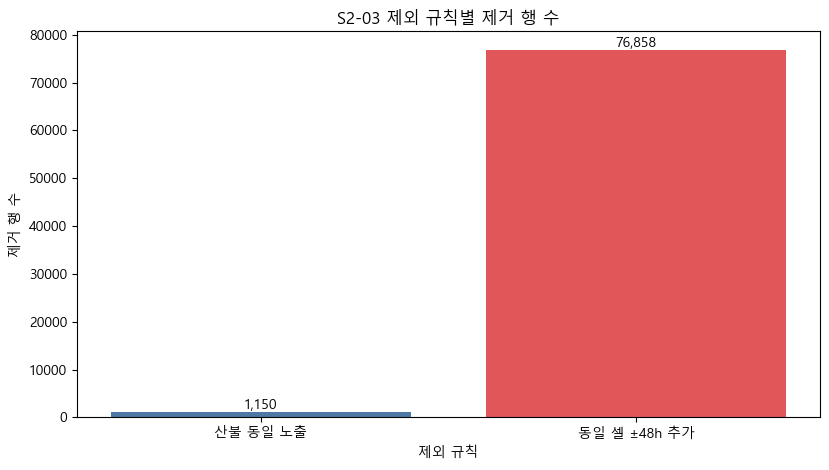

D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\plots\S2-03_exclusion_rule_counts.png


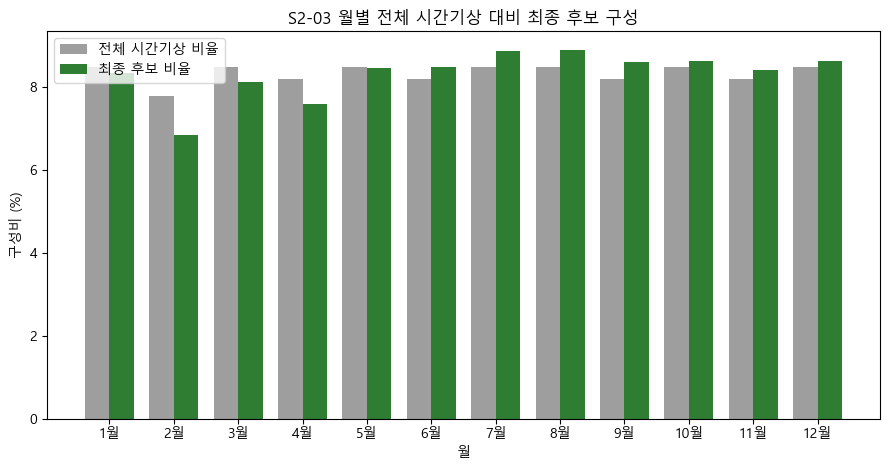

D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\plots\S2-03_monthly_candidate_composition.png


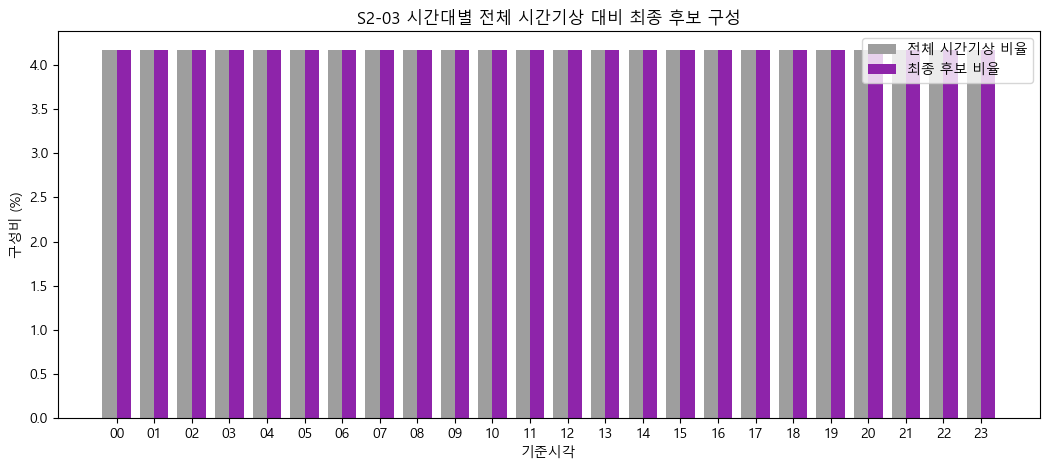

D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\plots\S2-03_hourly_candidate_composition.png


WindowsPath('D:/farm-system-public-02/jsw/강원_재_EDA/outputs/Step2/plots/S2-03_hourly_candidate_composition.png')

In [16]:
s2_03_plot_paths = []


def save_s2_03_plot(fig, filename):
    path = PLOT_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    s2_03_plot_paths.append(path)
    print(path)
    return path


fig, ax = plt.subplots(figsize=(8.4, 4.8))
removed = exclusion_rule_audit.iloc[1:3].copy()
ax.bar(removed["step"], removed["removed_in_step"], color=["#4E79A7", "#E15759"])
ax.set_title("S2-03 제외 규칙별 제거 행 수")
ax.set_xlabel("제외 규칙")
ax.set_ylabel("제거 행 수")
ax.set_xticklabels(["산불 동일 노출", "동일 셀 ±48h 추가"], rotation=0)
for idx, value in enumerate(removed["removed_in_step"]):
    ax.text(idx, value, f"{int(value):,}", ha="center", va="bottom", fontsize=10)
save_s2_03_plot(fig, "S2-03_exclusion_rule_counts.png")

month_labels = [f"{month}월" for month in candidate_monthly_summary["month"]]
x = np.arange(len(candidate_monthly_summary))
width = 0.38
fig, ax = plt.subplots(figsize=(9.0, 4.8))
ax.bar(x - width / 2, candidate_monthly_summary["full_share_pct"], width=width, color="#9E9E9E", label="전체 시간기상 비율")
ax.bar(x + width / 2, candidate_monthly_summary["candidate_share_pct"], width=width, color="#2E7D32", label="최종 후보 비율")
ax.set_title("S2-03 월별 전체 시간기상 대비 최종 후보 구성")
ax.set_xlabel("월")
ax.set_ylabel("구성비 (%)")
ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.legend(frameon=True)
save_s2_03_plot(fig, "S2-03_monthly_candidate_composition.png")

hour_labels = [f"{hour:02d}" for hour in candidate_hourly_summary["hour"]]
x = np.arange(len(candidate_hourly_summary))
fig, ax = plt.subplots(figsize=(10.6, 4.8))
ax.bar(x - width / 2, candidate_hourly_summary["full_share_pct"], width=width, color="#9E9E9E", label="전체 시간기상 비율")
ax.bar(x + width / 2, candidate_hourly_summary["candidate_share_pct"], width=width, color="#8E24AA", label="최종 후보 비율")
ax.set_title("S2-03 시간대별 전체 시간기상 대비 최종 후보 구성")
ax.set_xlabel("기준시각")
ax.set_ylabel("구성비 (%)")
ax.set_xticks(x)
ax.set_xticklabels(hour_labels)
ax.legend(frameon=True)
save_s2_03_plot(fig, "S2-03_hourly_candidate_composition.png")


### S2-03-5. 산출물 목록과 최종 감사 통과 확인

In [17]:
s2_03_artifact_manifest = pd.DataFrame(
    [
        {
            "artifact_type": "table",
            "filename": filename,
            "path": str(TABLE_DIR / filename),
            "rows": len(df),
            "columns": len(df.columns),
        }
        for filename, df in {"S2-03_analysis_scope.csv": s2_03_scope, **s2_03_tables}.items()
    ]
    + [
        {
            "artifact_type": "table",
            "filename": candidate_keys_path.name,
            "path": str(candidate_keys_path),
            "rows": len(nonfire_candidate_keys),
            "columns": len(nonfire_candidate_keys.columns),
        }
    ]
    + [
        {
            "artifact_type": "plot",
            "filename": path.name,
            "path": str(path),
            "rows": np.nan,
            "columns": np.nan,
        }
        for path in s2_03_plot_paths
    ]
)
s2_03_artifact_manifest.to_csv(TABLE_DIR / "S2-03_artifact_manifest.csv", index=False, encoding="utf-8-sig")

plot_file_audit = pd.DataFrame(
    [
        {"filename": path.name, "exists": path.exists(), "size_bytes": path.stat().st_size if path.exists() else 0}
        for path in s2_03_plot_paths
    ]
)
table_file_audit = pd.DataFrame(
    [
        {"filename": row["filename"], "exists": Path(row["path"]).exists(), "size_bytes": Path(row["path"]).stat().st_size if Path(row["path"]).exists() else 0}
        for _, row in s2_03_artifact_manifest[s2_03_artifact_manifest["artifact_type"] == "table"].iterrows()
    ]
)
display(s2_03_artifact_manifest)
display(table_file_audit)
display(plot_file_audit)

assert len(s2_03_plot_paths) == 3
assert table_file_audit["exists"].all()
assert (table_file_audit["size_bytes"] > 0).all()
assert plot_file_audit["exists"].all()
assert (plot_file_audit["size_bytes"] > 0).all()

print(f"{ANALYSIS_ID} execution complete")


,artifact_type,filename,path,rows,columns
0,table,S2-03_analysis_scope.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,9.0,2.0
1,table,S2-03_population_validation.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,16.0,3.0
2,table,S2-03_rolling_source_code_audit.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,4.0,3.0
3,table,S2-03_rolling_recalculation_audit.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,11.0,9.0
4,table,S2-03_d_lag_recalculation_audit.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,5.0,7.0
5,table,S2-03_timestamp_semantics_audit.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,1.0,10.0
6,table,S2-03_exclusion_rule_audit.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,4.0,5.0
7,table,S2-03_event_window_contamination_audit.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,1150.0,7.0
8,table,S2-03_candidate_missingness_audit.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,8.0,4.0
9,table,S2-03_candidate_duplicate_audit.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,5.0,3.0


,filename,exists,size_bytes
0,S2-03_analysis_scope.csv,True,999
1,S2-03_population_validation.csv,True,1126
2,S2-03_rolling_source_code_audit.csv,True,473
3,S2-03_rolling_recalculation_audit.csv,True,928
4,S2-03_d_lag_recalculation_audit.csv,True,426
5,S2-03_timestamp_semantics_audit.csv,True,466
6,S2-03_exclusion_rule_audit.csv,True,485
7,S2-03_event_window_contamination_audit.csv,True,65929
8,S2-03_candidate_missingness_audit.csv,True,240
9,S2-03_candidate_duplicate_audit.csv,True,264


,filename,exists,size_bytes
0,S2-03_exclusion_rule_counts.png,True,43578
1,S2-03_monthly_candidate_composition.png,True,36995
2,S2-03_hourly_candidate_composition.png,True,46325


S2-03 execution complete


## S2-04. 고정 1:5 매칭 대조군 생성과 품질 감사


In [18]:
ANALYSIS_ID = "S2-04"
S2_04_MATCH_RATIO = 5
S2_04_RANDOM_SEED = 42
S2_04_CANDIDATE_PATH = TABLE_DIR / "S2-03_nonfire_candidate_keys.csv.gz"

s2_04_scope = pd.DataFrame(
    [
        {"item": "분석 질문", "value": "동일 기상셀·연도·월·시각 조건으로 산불 고유 노출당 최대 5개의 고정 비발생 대조군을 생성할 수 있는가?"},
        {"item": "분석 ID", "value": ANALYSIS_ID},
        {"item": "분석 단위", "value": "산불 고유 기상노출 1개와 매칭 비발생 후보 cell-hour"},
        {"item": "모집단", "value": "S2-01~S2-03에서 확정한 산불 고유 노출 1,150개"},
        {"item": "비교집단", "value": "S2-03 최종 비발생 후보 중 Canadian FFMC/FWI as-of 키가 모두 존재하는 후보"},
        {"item": "기간", "value": "2020-01-01 00:00:00 <= 기준시각 < 2022-01-01 00:00:00"},
        {"item": "통제·층화·매칭 조건", "value": "동일 기상셀ID, 동일 연도, 동일 월, 동일 기준시각 hour. 조건 완화 없음. 사건당 최대 5개, seed 42."},
        {"item": "누수 제외 조건", "value": "S2-03 후보 파일에서 산불 동일 노출과 동일 셀 ±48시간이 이미 제외된 후보만 사용"},
        {"item": "Canadian 지수 가용성", "value": "S2-07~S2-08 공통 재사용을 위해 canadian_ffmc_available 및 canadian_fwi_available이 모두 True인 후보를 기본 매칭 풀로 사용"},
    ]
)
s2_04_scope.to_csv(TABLE_DIR / "S2-04_analysis_scope.csv", index=False, encoding="utf-8-sig")
display(s2_04_scope)
print(TABLE_DIR / "S2-04_analysis_scope.csv")


,item,value
0,분석 질문,동일 기상셀·연도·월·시각 조건으로 산불 고유 노출당 최대 5개의 고정 비발생 대조...
1,분석 ID,S2-04
2,분석 단위,산불 고유 기상노출 1개와 매칭 비발생 후보 cell-hour
3,모집단,"S2-01~S2-03에서 확정한 산불 고유 노출 1,150개"
4,비교집단,S2-03 최종 비발생 후보 중 Canadian FFMC/FWI as-of 키가 모...
5,기간,2020-01-01 00:00:00 <= 기준시각 < 2022-01-01 00:00:00
6,통제·층화·매칭 조건,"동일 기상셀ID, 동일 연도, 동일 월, 동일 기준시각 hour. 조건 완화 없음...."
7,누수 제외 조건,S2-03 후보 파일에서 산불 동일 노출과 동일 셀 ±48시간이 이미 제외된 후보만 사용
8,Canadian 지수 가용성,S2-07~S2-08 공통 재사용을 위해 canadian_ffmc_available...


D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\tables\S2-04_analysis_scope.csv


### S2-04-1. 후보 풀 로딩과 고정 매칭 생성


In [19]:
import hashlib


def deterministic_event_seed(event_id, base_seed=S2_04_RANDOM_SEED):
    digest = hashlib.sha256(f"{base_seed}-{event_id}".encode("utf-8")).hexdigest()
    return int(digest[:8], 16)


assert S2_04_CANDIDATE_PATH.exists(), S2_04_CANDIDATE_PATH

s2_04_candidates = pd.read_csv(
    S2_04_CANDIDATE_PATH,
    encoding="utf-8-sig",
    parse_dates=["기준시각", "캐나다지수_기준날짜", "캐나다지수_기준시각"],
)
s2_04_candidates["date"] = pd.to_datetime(s2_04_candidates["date"])
s2_04_candidates["match_key"] = (
    s2_04_candidates["기상셀ID"].astype(str)
    + "|"
    + s2_04_candidates["year"].astype(str)
    + "|"
    + s2_04_candidates["month"].astype(str)
    + "|"
    + s2_04_candidates["hour"].astype(str)
)
s2_04_candidates["canadian_both_available"] = (
    s2_04_candidates["canadian_ffmc_available"].astype(bool)
    & s2_04_candidates["canadian_fwi_available"].astype(bool)
)
s2_04_match_pool = s2_04_candidates.loc[s2_04_candidates["canadian_both_available"]].copy()

s2_04_fire_exposures = fire_exposure_keys.copy()
s2_04_fire_exposures["기준시각"] = pd.to_datetime(s2_04_fire_exposures["기준시각"])
s2_04_fire_exposures["year"] = s2_04_fire_exposures["기준시각"].dt.year.astype(int)
s2_04_fire_exposures["month"] = s2_04_fire_exposures["기준시각"].dt.month.astype(int)
s2_04_fire_exposures["hour"] = s2_04_fire_exposures["기준시각"].dt.hour.astype(int)
s2_04_fire_exposures["date"] = pd.to_datetime(s2_04_fire_exposures["기준시각"].dt.date)
s2_04_fire_exposures["match_key"] = (
    s2_04_fire_exposures["기상셀ID"].astype(str)
    + "|"
    + s2_04_fire_exposures["year"].astype(str)
    + "|"
    + s2_04_fire_exposures["month"].astype(str)
    + "|"
    + s2_04_fire_exposures["hour"].astype(str)
)
s2_04_fire_exposures = s2_04_fire_exposures.sort_values(["기상셀ID", "기준시각"]).reset_index(drop=True)

base_pool_counts = s2_04_candidates.groupby("match_key", observed=True).size().rename("base_pool_n")
canadian_pool_counts = s2_04_match_pool.groupby("match_key", observed=True).size().rename("canadian_pool_n")

matched_chunks = []
for _, fire_row in s2_04_fire_exposures.iterrows():
    event_id = fire_row["fire_exposure_id"]
    pool = s2_04_match_pool.loc[s2_04_match_pool["match_key"] == fire_row["match_key"]]
    if pool.empty:
        continue
    selected = pool.sample(
        n=min(S2_04_MATCH_RATIO, len(pool)),
        replace=False,
        random_state=deterministic_event_seed(event_id),
    ).copy()
    selected = selected.sort_values("기준시각").reset_index(drop=True)
    selected["fire_exposure_id"] = event_id
    selected["control_rank"] = np.arange(1, len(selected) + 1)
    selected["fire_기상셀ID"] = fire_row["기상셀ID"]
    selected["fire_기준시각"] = fire_row["기준시각"]
    selected["fire_year"] = fire_row["year"]
    selected["fire_month"] = fire_row["month"]
    selected["fire_hour"] = fire_row["hour"]
    selected["fire_date"] = fire_row["date"]
    selected["fire_climate_type"] = fire_row["climate_type"]
    selected["fire_raw_event_n"] = fire_row["raw_event_n"]
    selected["fire_ids"] = fire_row["fire_ids"]
    matched_chunks.append(selected)

s2_04_matched_controls = pd.concat(matched_chunks, ignore_index=True) if matched_chunks else pd.DataFrame()
if not s2_04_matched_controls.empty:
    s2_04_matched_controls["control_date"] = pd.to_datetime(s2_04_matched_controls["date"])
    s2_04_matched_controls["date_diff_days"] = (
        s2_04_matched_controls["control_date"] - s2_04_matched_controls["fire_date"]
    ).dt.days.astype(int)
    s2_04_matched_controls["abs_date_diff_days"] = s2_04_matched_controls["date_diff_days"].abs()
    s2_04_matched_controls["time_diff_hours"] = (
        s2_04_matched_controls["기준시각"] - s2_04_matched_controls["fire_기준시각"]
    ).dt.total_seconds() / 3600
    s2_04_matched_controls["abs_time_diff_hours"] = s2_04_matched_controls["time_diff_hours"].abs()

event_match_counts = s2_04_matched_controls.groupby("fire_exposure_id", observed=True).size().rename("matched_control_n")
event_gap_summary = s2_04_matched_controls.groupby("fire_exposure_id", observed=True).agg(
    min_abs_date_diff_days=("abs_date_diff_days", "min"),
    median_abs_date_diff_days=("abs_date_diff_days", "median"),
    max_abs_date_diff_days=("abs_date_diff_days", "max"),
    min_abs_time_diff_hours=("abs_time_diff_hours", "min"),
    median_abs_time_diff_hours=("abs_time_diff_hours", "median"),
    max_abs_time_diff_hours=("abs_time_diff_hours", "max"),
).reset_index()

s2_04_matching_quality = s2_04_fire_exposures[
    ["fire_exposure_id", "기상셀ID", "기준시각", "year", "month", "hour", "date", "climate_type", "raw_event_n", "fire_ids", "match_key"]
].copy()
s2_04_matching_quality = s2_04_matching_quality.merge(base_pool_counts, on="match_key", how="left")
s2_04_matching_quality = s2_04_matching_quality.merge(canadian_pool_counts, on="match_key", how="left")
s2_04_matching_quality = s2_04_matching_quality.merge(event_match_counts, on="fire_exposure_id", how="left")
s2_04_matching_quality = s2_04_matching_quality.merge(event_gap_summary, on="fire_exposure_id", how="left")
for col in ["base_pool_n", "canadian_pool_n", "matched_control_n"]:
    s2_04_matching_quality[col] = s2_04_matching_quality[col].fillna(0).astype(int)
s2_04_matching_quality["full_5_matched"] = s2_04_matching_quality["matched_control_n"] >= S2_04_MATCH_RATIO
s2_04_matching_quality["match_status"] = np.select(
    [
        s2_04_matching_quality["matched_control_n"] >= S2_04_MATCH_RATIO,
        (s2_04_matching_quality["base_pool_n"] > 0) & (s2_04_matching_quality["canadian_pool_n"] == 0),
        (s2_04_matching_quality["canadian_pool_n"] > 0) & (s2_04_matching_quality["matched_control_n"] < S2_04_MATCH_RATIO),
        s2_04_matching_quality["base_pool_n"] == 0,
    ],
    [
        "full_5",
        "no_candidates_after_canadian_filter",
        "fewer_than_5_after_canadian_filter",
        "no_candidates_before_canadian_filter",
    ],
    default="other",
)

matched_controls_path = TABLE_DIR / "S2-04_matched_controls.csv.gz"
s2_04_matched_controls.to_csv(matched_controls_path, index=False, encoding="utf-8-sig", compression="gzip")
matched_controls_sha256 = hashlib.sha256(matched_controls_path.read_bytes()).hexdigest()

s2_04_matching_quality.to_csv(TABLE_DIR / "S2-04_matching_quality.csv", index=False, encoding="utf-8-sig")

display(s2_04_matching_quality.head())
display(s2_04_matched_controls.head())
print(matched_controls_path)
print(matched_controls_sha256)


,fire_exposure_id,기상셀ID,기준시각,year,month,hour,date,climate_type,raw_event_n,fire_ids,match_key,base_pool_n,canadian_pool_n,matched_control_n,min_abs_date_diff_days,median_abs_date_diff_days,max_abs_date_diff_days,min_abs_time_diff_hours,median_abs_time_diff_hours,max_abs_time_diff_hours,full_5_matched,match_status
0,FE_00001,YD_0001,2020-01-01 12:00:00,2020,1,12,2020-01-01,영동 해안형,1,F_007615,YD_0001|2020|1|12,24,24,5,4,7.0,27,96.0,168.0,648.0,True,full_5
1,FE_00002,YD_0001,2020-01-13 11:00:00,2020,1,11,2020-01-13,영동 해안형,1,F_010705,YD_0001|2020|1|11,23,23,5,7,8.0,15,168.0,192.0,360.0,True,full_5
2,FE_00003,YD_0001,2020-02-08 12:00:00,2020,2,12,2020-02-08,영동 해안형,1,F_007649,YD_0001|2020|2|12,24,24,5,3,8.0,13,72.0,192.0,312.0,True,full_5
3,FE_00004,YD_0001,2020-03-24 11:00:00,2020,3,11,2020-03-24,영동 해안형,1,F_010804,YD_0001|2020|3|11,24,24,5,4,9.0,22,96.0,216.0,528.0,True,full_5
4,FE_00005,YD_0001,2020-03-26 18:00:00,2020,3,18,2020-03-26,영동 해안형,1,F_010816,YD_0001|2020|3|18,24,24,5,6,8.0,10,144.0,192.0,240.0,True,full_5


,candidate_seq,기상셀ID,기준시각,기후지형유형,year,month,hour,date,season,nearest_fire_delta_hours,캐나다지수_기준날짜,캐나다지수_기준시각,캐나다지수_시차시간,캐나다지수_시차일,캐나다지수_당일사용여부,canadian_ffmc_available,canadian_fwi_available,match_key,canadian_both_available,fire_exposure_id,control_rank,fire_기상셀ID,fire_기준시각,fire_year,fire_month,fire_hour,fire_date,fire_climate_type,fire_raw_event_n,fire_ids,control_date,date_diff_days,abs_date_diff_days,time_diff_hours,abs_time_diff_hours
0,48,YD_0001,2020-01-05 12:00:00,영동 해안형,2020,1,12,2020-01-05,겨울(12-2월),96.0,2020-01-05,2020-01-05 12:00:00,0.0,0.0,1,True,True,YD_0001|2020|1|12,True,FE_00001,1,YD_0001,2020-01-01 12:00:00,2020,1,12,2020-01-01,영동 해안형,1,F_007615,2020-01-05,4,4,96.0,96.0
1,72,YD_0001,2020-01-06 12:00:00,영동 해안형,2020,1,12,2020-01-06,겨울(12-2월),120.0,2020-01-06,2020-01-06 12:00:00,0.0,0.0,1,True,True,YD_0001|2020|1|12,True,FE_00001,2,YD_0001,2020-01-01 12:00:00,2020,1,12,2020-01-01,영동 해안형,1,F_007615,2020-01-06,5,5,120.0,120.0
2,120,YD_0001,2020-01-08 12:00:00,영동 해안형,2020,1,12,2020-01-08,겨울(12-2월),119.0,2020-01-08,2020-01-08 12:00:00,0.0,0.0,1,True,True,YD_0001|2020|1|12,True,FE_00001,3,YD_0001,2020-01-01 12:00:00,2020,1,12,2020-01-01,영동 해안형,1,F_007615,2020-01-08,7,7,168.0,168.0
3,144,YD_0001,2020-01-09 12:00:00,영동 해안형,2020,1,12,2020-01-09,겨울(12-2월),95.0,2020-01-09,2020-01-09 12:00:00,0.0,0.0,1,True,True,YD_0001|2020|1|12,True,FE_00001,4,YD_0001,2020-01-01 12:00:00,2020,1,12,2020-01-01,영동 해안형,1,F_007615,2020-01-09,8,8,192.0,192.0
4,503,YD_0001,2020-01-28 12:00:00,영동 해안형,2020,1,12,2020-01-28,겨울(12-2월),264.0,2020-01-28,2020-01-28 12:00:00,0.0,0.0,1,True,True,YD_0001|2020|1|12,True,FE_00001,5,YD_0001,2020-01-01 12:00:00,2020,1,12,2020-01-01,영동 해안형,1,F_007615,2020-01-28,27,27,648.0,648.0


D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\tables\S2-04_matched_controls.csv.gz
2b146b8d155bfdae843311839a298c5bcff1b7a734bfa1b7b261387411c312c3


### S2-04-2. 매칭 키·재사용·층화 감사


In [20]:
key_violation_n = int(
    (
        (s2_04_matched_controls["기상셀ID"] != s2_04_matched_controls["fire_기상셀ID"])
        | (s2_04_matched_controls["year"] != s2_04_matched_controls["fire_year"])
        | (s2_04_matched_controls["month"] != s2_04_matched_controls["fire_month"])
        | (s2_04_matched_controls["hour"] != s2_04_matched_controls["fire_hour"])
    ).sum()
)
direct_fire_overlap_n = int(
    (
        s2_04_matched_controls["기상셀ID"].astype(str)
        + "|"
        + s2_04_matched_controls["기준시각"].astype(str)
    ).isin(
        s2_04_fire_exposures["기상셀ID"].astype(str)
        + "|"
        + s2_04_fire_exposures["기준시각"].astype(str)
    ).sum()
)
within_48h_violation_n = int((s2_04_matched_controls["abs_time_diff_hours"] <= 48).sum())
control_duplicate_within_event_n = int(
    s2_04_matched_controls.duplicated(["fire_exposure_id", "candidate_seq"]).sum()
)
control_reuse = (
    s2_04_matched_controls.groupby(["candidate_seq", "기상셀ID", "기준시각"], observed=True)
    .agg(reuse_n=("fire_exposure_id", "nunique"))
    .reset_index()
)
reused_control_n = int((control_reuse["reuse_n"] > 1).sum())
max_reuse_n = int(control_reuse["reuse_n"].max()) if len(control_reuse) else 0

status_counts = s2_04_matching_quality["match_status"].value_counts().rename_axis("match_status").reset_index(name="exposure_n")
status_counts["exposure_pct"] = status_counts["exposure_n"] / len(s2_04_matching_quality) * 100

def stratified_summary(group_col, label):
    out = (
        s2_04_matching_quality.groupby(group_col, observed=True)
        .agg(
            exposure_n=("fire_exposure_id", "nunique"),
            full_5_n=("full_5_matched", "sum"),
            mean_matched_control_n=("matched_control_n", "mean"),
            median_canadian_pool_n=("canadian_pool_n", "median"),
            min_canadian_pool_n=("canadian_pool_n", "min"),
            median_abs_date_diff_days=("median_abs_date_diff_days", "median"),
            max_abs_date_diff_days=("max_abs_date_diff_days", "max"),
        )
        .reset_index()
        .rename(columns={group_col: "stratum"})
    )
    out["stratum_type"] = label
    out["full_5_pct"] = out["full_5_n"] / out["exposure_n"] * 100
    return out[
        [
            "stratum_type",
            "stratum",
            "exposure_n",
            "full_5_n",
            "full_5_pct",
            "mean_matched_control_n",
            "median_canadian_pool_n",
            "min_canadian_pool_n",
            "median_abs_date_diff_days",
            "max_abs_date_diff_days",
        ]
    ]

s2_04_stratified_summary = pd.concat(
    [
        stratified_summary("climate_type", "기후지형유형"),
        stratified_summary("year", "연도"),
        stratified_summary("month", "월"),
        stratified_summary("hour", "시간"),
    ],
    ignore_index=True,
)
s2_04_stratified_summary.to_csv(TABLE_DIR / "S2-04_stratified_summary.csv", index=False, encoding="utf-8-sig")

s2_04_audit_summary = pd.DataFrame(
    [
        {"check_name": "fire_exposure_n", "value": len(s2_04_fire_exposures), "pass": True},
        {"check_name": "candidate_pool_before_canadian_filter_n", "value": len(s2_04_candidates), "pass": True},
        {"check_name": "candidate_removed_by_canadian_filter_n", "value": int((~s2_04_candidates["canadian_both_available"]).sum()), "pass": True},
        {"check_name": "candidate_pool_after_canadian_filter_n", "value": len(s2_04_match_pool), "pass": True},
        {"check_name": "matched_control_row_n", "value": len(s2_04_matched_controls), "pass": True},
        {"check_name": "matched_exposure_n", "value": int((s2_04_matching_quality["matched_control_n"] > 0).sum()), "pass": True},
        {"check_name": "full_5_matched_exposure_n", "value": int(s2_04_matching_quality["full_5_matched"].sum()), "pass": True},
        {"check_name": "full_5_matched_pct", "value": float(s2_04_matching_quality["full_5_matched"].mean() * 100), "pass": bool((s2_04_matching_quality["full_5_matched"].mean() * 100) >= 95)},
        {"check_name": "less_than_5_exposure_n", "value": int((s2_04_matching_quality["matched_control_n"] < S2_04_MATCH_RATIO).sum()), "pass": True},
        {"check_name": "key_violation_n", "value": key_violation_n, "pass": key_violation_n == 0},
        {"check_name": "direct_fire_overlap_n", "value": direct_fire_overlap_n, "pass": direct_fire_overlap_n == 0},
        {"check_name": "within_48h_violation_n", "value": within_48h_violation_n, "pass": within_48h_violation_n == 0},
        {"check_name": "control_duplicate_within_event_n", "value": control_duplicate_within_event_n, "pass": control_duplicate_within_event_n == 0},
        {"check_name": "unique_control_n", "value": int(len(control_reuse)), "pass": True},
        {"check_name": "reused_control_n", "value": reused_control_n, "pass": True},
        {"check_name": "max_control_reuse_n", "value": max_reuse_n, "pass": True},
        {"check_name": "matched_controls_sha256", "value": matched_controls_sha256, "pass": True},
        {"check_name": "random_seed", "value": S2_04_RANDOM_SEED, "pass": True},
    ]
)
s2_04_audit_summary.to_csv(TABLE_DIR / "S2-04_audit_summary.csv", index=False, encoding="utf-8-sig")

display(s2_04_audit_summary)
display(status_counts)
display(s2_04_stratified_summary)

assert key_violation_n == 0
assert direct_fire_overlap_n == 0
assert within_48h_violation_n == 0
assert control_duplicate_within_event_n == 0
assert s2_04_matching_quality["full_5_matched"].mean() >= 0.95


,check_name,value,pass
0,fire_exposure_n,1150,True
1,candidate_pool_before_canadian_filter_n,1536040,True
2,candidate_removed_by_canadian_filter_n,1091,True
3,candidate_pool_after_canadian_filter_n,1534949,True
4,matched_control_row_n,5632,True
5,matched_exposure_n,1150,True
6,full_5_matched_exposure_n,1110,True
7,full_5_matched_pct,96.521739,True
8,less_than_5_exposure_n,40,True
9,key_violation_n,0,True


,match_status,exposure_n,exposure_pct
0,full_5,1110,96.521739
1,fewer_than_5_after_canadian_filter,40,3.478261


,stratum_type,stratum,exposure_n,full_5_n,full_5_pct,mean_matched_control_n,median_canadian_pool_n,min_canadian_pool_n,median_abs_date_diff_days,max_abs_date_diff_days
0,기후지형유형,고지·산간형,181,162,89.502762,4.618785,22.0,1,11.0,29
1,기후지형유형,영동 해안형,354,333,94.067797,4.861582,20.0,2,11.0,30
2,기후지형유형,영서 내륙형,615,615,100.000000,5.000000,21.0,6,11.0,30
3,연도,2020,415,415,100.000000,5.000000,24.0,7,11.0,30
4,연도,2021,735,695,94.557823,4.839456,19.0,1,11.0,29
5,월,1,107,107,100.000000,5.000000,24.0,13,13.0,29
6,월,2,390,350,89.743590,4.697436,14.0,1,12.0,28
7,월,3,162,162,100.000000,5.000000,24.0,17,10.0,30
8,월,4,208,208,100.000000,5.000000,21.0,11,11.0,29
9,월,5,89,89,100.000000,5.000000,26.0,19,13.0,30


### S2-04-3. 핵심 플롯 저장


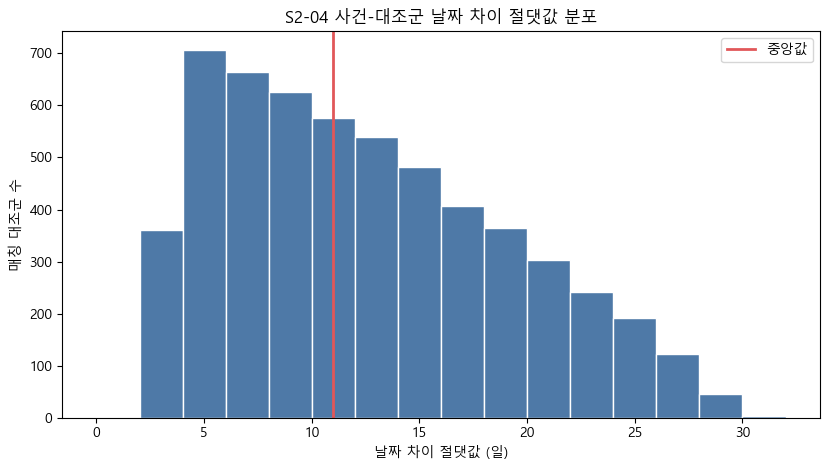

D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\plots\S2-04_abs_date_difference_distribution.png


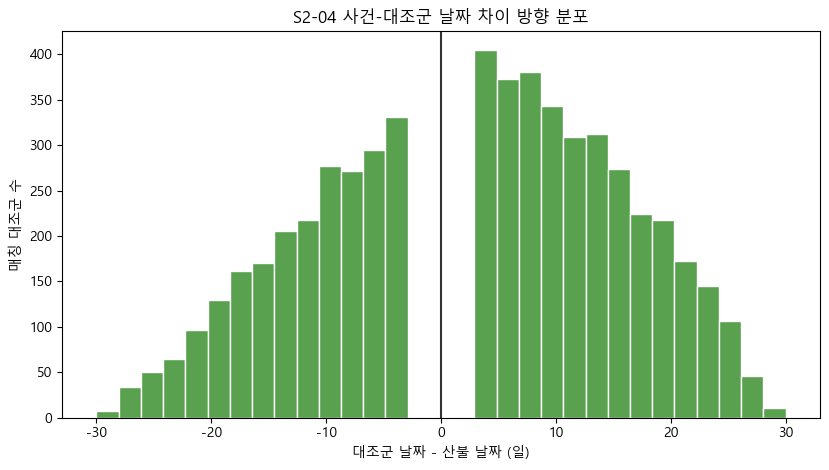

D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\plots\S2-04_signed_date_difference_distribution.png


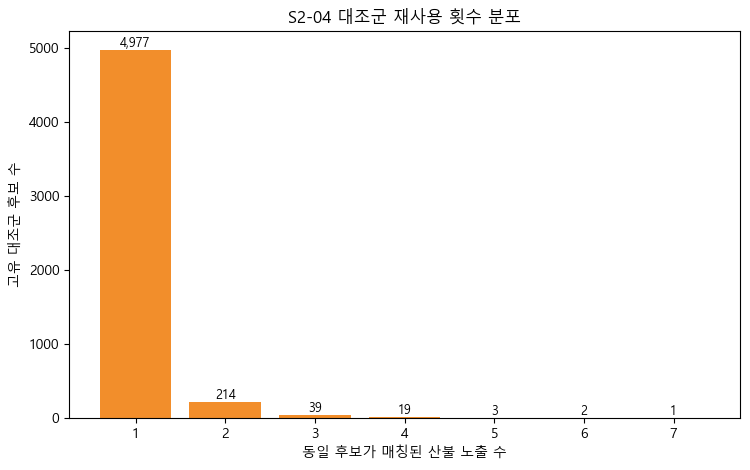

D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\plots\S2-04_control_reuse_distribution.png


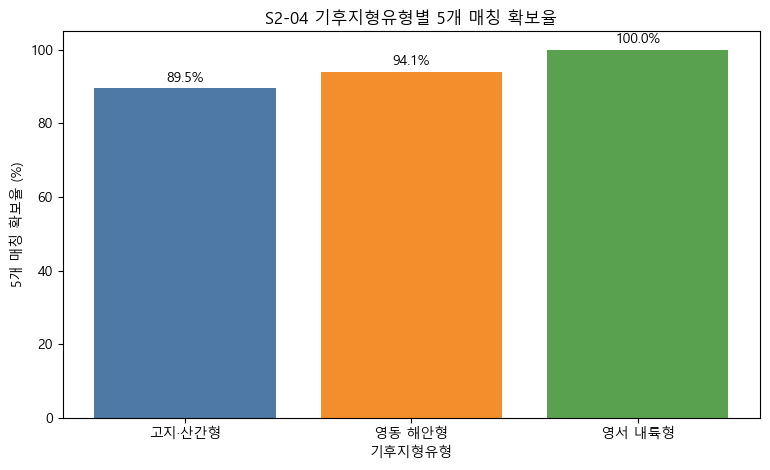

D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\plots\S2-04_climate_type_matching_success.png


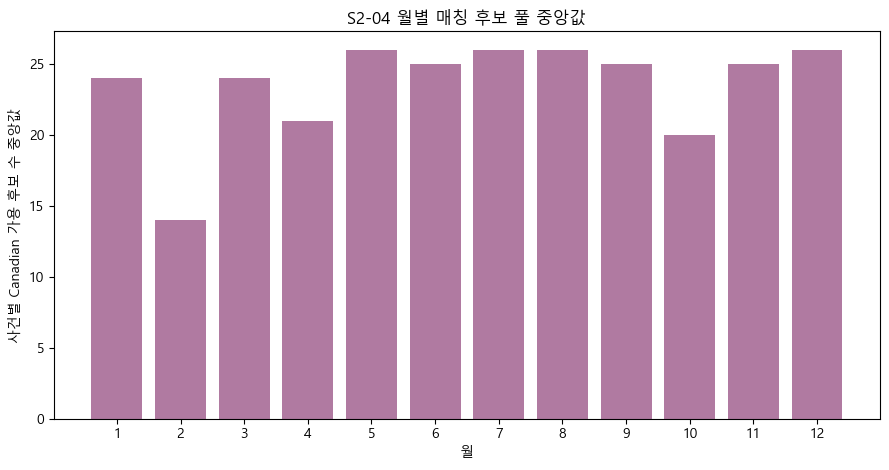

D:\farm-system-public-02\jsw\강원_재_EDA\outputs\Step2\plots\S2-04_monthly_candidate_pool_median.png


WindowsPath('D:/farm-system-public-02/jsw/강원_재_EDA/outputs/Step2/plots/S2-04_monthly_candidate_pool_median.png')

In [21]:
s2_04_plot_paths = []


def save_s2_04_plot(fig, filename):
    path = PLOT_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    s2_04_plot_paths.append(path)
    print(path)
    return path


fig, ax = plt.subplots(figsize=(8.4, 4.8))
bins = np.arange(0, s2_04_matched_controls["abs_date_diff_days"].max() + 3, 2)
ax.hist(s2_04_matched_controls["abs_date_diff_days"], bins=bins, color="#4E79A7", edgecolor="white")
ax.axvline(s2_04_matched_controls["abs_date_diff_days"].median(), color="#E15759", linewidth=2, label="중앙값")
ax.set_title("S2-04 사건-대조군 날짜 차이 절댓값 분포")
ax.set_xlabel("날짜 차이 절댓값 (일)")
ax.set_ylabel("매칭 대조군 수")
ax.legend(frameon=True)
save_s2_04_plot(fig, "S2-04_abs_date_difference_distribution.png")

fig, ax = plt.subplots(figsize=(8.4, 4.8))
ax.hist(s2_04_matched_controls["date_diff_days"], bins=31, color="#59A14F", edgecolor="white")
ax.axvline(0, color="#333333", linewidth=1.5)
ax.set_title("S2-04 사건-대조군 날짜 차이 방향 분포")
ax.set_xlabel("대조군 날짜 - 산불 날짜 (일)")
ax.set_ylabel("매칭 대조군 수")
save_s2_04_plot(fig, "S2-04_signed_date_difference_distribution.png")

reuse_counts = control_reuse["reuse_n"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7.6, 4.8))
ax.bar(reuse_counts.index.astype(str), reuse_counts.values, color="#F28E2B")
ax.set_title("S2-04 대조군 재사용 횟수 분포")
ax.set_xlabel("동일 후보가 매칭된 산불 노출 수")
ax.set_ylabel("고유 대조군 후보 수")
for idx, value in enumerate(reuse_counts.values):
    ax.text(idx, value, f"{int(value):,}", ha="center", va="bottom", fontsize=9)
save_s2_04_plot(fig, "S2-04_control_reuse_distribution.png")

climate_plot = s2_04_stratified_summary.loc[s2_04_stratified_summary["stratum_type"] == "기후지형유형"].copy()
fig, ax = plt.subplots(figsize=(7.8, 4.8))
ax.bar(climate_plot["stratum"], climate_plot["full_5_pct"], color=["#4E79A7", "#F28E2B", "#59A14F"])
ax.set_ylim(0, 105)
ax.set_title("S2-04 기후지형유형별 5개 매칭 확보율")
ax.set_xlabel("기후지형유형")
ax.set_ylabel("5개 매칭 확보율 (%)")
for idx, value in enumerate(climate_plot["full_5_pct"]):
    ax.text(idx, value + 1, f"{value:.1f}%", ha="center", va="bottom", fontsize=10)
save_s2_04_plot(fig, "S2-04_climate_type_matching_success.png")

month_plot = s2_04_stratified_summary.loc[s2_04_stratified_summary["stratum_type"] == "월"].copy()
month_plot["stratum"] = month_plot["stratum"].astype(int)
fig, ax = plt.subplots(figsize=(9.0, 4.8))
ax.bar(month_plot["stratum"].astype(str), month_plot["median_canadian_pool_n"], color="#B07AA1")
ax.set_title("S2-04 월별 매칭 후보 풀 중앙값")
ax.set_xlabel("월")
ax.set_ylabel("사건별 Canadian 가용 후보 수 중앙값")
save_s2_04_plot(fig, "S2-04_monthly_candidate_pool_median.png")


### S2-04-4. 산출물 목록과 최종 감사 통과 확인


In [22]:
s2_04_table_objects = {
    "S2-04_analysis_scope.csv": s2_04_scope,
    "S2-04_audit_summary.csv": s2_04_audit_summary,
    "S2-04_matching_quality.csv": s2_04_matching_quality,
    "S2-04_matched_controls.csv.gz": s2_04_matched_controls,
    "S2-04_stratified_summary.csv": s2_04_stratified_summary,
}
s2_04_artifact_manifest = pd.DataFrame(
    [
        {
            "artifact_type": "table",
            "filename": filename,
            "path": str(TABLE_DIR / filename),
            "rows": len(df),
            "columns": len(df.columns),
        }
        for filename, df in s2_04_table_objects.items()
    ]
    + [
        {
            "artifact_type": "plot",
            "filename": path.name,
            "path": str(path),
            "rows": np.nan,
            "columns": np.nan,
        }
        for path in s2_04_plot_paths
    ]
)
s2_04_artifact_manifest.to_csv(TABLE_DIR / "S2-04_artifact_manifest.csv", index=False, encoding="utf-8-sig")

s2_04_file_audit = pd.DataFrame(
    [
        {
            "filename": row["filename"],
            "exists": Path(row["path"]).exists(),
            "size_bytes": Path(row["path"]).stat().st_size if Path(row["path"]).exists() else 0,
        }
        for _, row in s2_04_artifact_manifest.iterrows()
    ]
)
display(s2_04_artifact_manifest)
display(s2_04_file_audit)

assert len(s2_04_plot_paths) == 5
assert s2_04_file_audit["exists"].all()
assert (s2_04_file_audit["size_bytes"] > 0).all()
assert s2_04_audit_summary["pass"].all()

print(f"{ANALYSIS_ID} execution complete")


,artifact_type,filename,path,rows,columns
0,table,S2-04_analysis_scope.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,9.0,2.0
1,table,S2-04_audit_summary.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,18.0,3.0
2,table,S2-04_matching_quality.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,1150.0,22.0
3,table,S2-04_matched_controls.csv.gz,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,5632.0,35.0
4,table,S2-04_stratified_summary.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,41.0,10.0
5,plot,S2-04_abs_date_difference_distribution.png,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,NaN,NaN
6,plot,S2-04_signed_date_difference_distribution.png,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,NaN,NaN
7,plot,S2-04_control_reuse_distribution.png,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,NaN,NaN
8,plot,S2-04_climate_type_matching_success.png,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,NaN,NaN
9,plot,S2-04_monthly_candidate_pool_median.png,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,NaN,NaN


,filename,exists,size_bytes
0,S2-04_analysis_scope.csv,True,983
1,S2-04_audit_summary.csv,True,710
2,S2-04_matching_quality.csv,True,180048
3,S2-04_matched_controls.csv.gz,True,165344
4,S2-04_stratified_summary.csv,True,2249
5,S2-04_abs_date_difference_distribution.png,True,38537
6,S2-04_signed_date_difference_distribution.png,True,36809
7,S2-04_control_reuse_distribution.png,True,36391
8,S2-04_climate_type_matching_success.png,True,40875
9,S2-04_monthly_candidate_pool_median.png,True,33561


S2-04 execution complete


## S2-05. 산불 대 전체 비발생 기상 탐색 비교

### S2-05-1. 분석 범위 및 통계 비교

In [23]:
ANALYSIS_ID = "S2-05"
import scipy.stats as stats

# BH FDR correction
def bh_adjust(p_vals):
    p_vals = np.asarray(p_vals, dtype=float)
    q_vals = np.full(len(p_vals), np.nan)
    valid = ~np.isnan(p_vals)
    if not valid.any():
        return q_vals
    valid_indices = np.where(valid)[0]
    order = np.argsort(p_vals[valid])
    ranked = p_vals[valid][order]
    m = len(ranked)
    adjusted = ranked * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    q_vals[valid_indices[order]] = np.clip(adjusted, 0, 1)
    return q_vals

# 1. Load data
fire_exposures = pd.read_csv(TABLE_DIR / "S2-02_unique_weather_exposures.csv", parse_dates=["기준시각"])
candidate_keys = pd.read_csv(TABLE_DIR / "S2-03_nonfire_candidate_keys.csv.gz", parse_dates=["기준시각"])

derived_cols = [
    "기상셀ID", "일시",
    # Main variables
    "직전24h_최소습도", "직전24h_평균습도", "직전24h_평균풍속", "직전24h_최대풍속", "직전24h_강수량합", "D-1_최소습도_pct", "D-1_강수량합_mm",
    # Sub variables
    "직전48h_평균풍속", "직전48h_최대풍속", "직전48h_평균습도", "직전48h_최소습도", "직전48h_강수량합", 
    "D-2_최소습도_pct", "D-3_최소습도_pct", "기압변동_3h", "서풍계열_여부", "풍향_sin", "풍향_cos",
    # Tech (concurrent) variables
    "시점_기온_C", "시점_습도_pct", "시점_풍속_m_s", "시점_현지기압_hPa"
]

weather_derived = pd.read_csv(
    REPO_ROOT / "data" / "학습데이터" / "기상_시간단위_파생.csv",
    usecols=derived_cols,
    parse_dates=["일시"]
).rename(columns={"일시": "기준시각"})

# Merge weather features
fire_data = fire_exposures[["기상셀ID", "기준시각"]].merge(weather_derived, on=["기상셀ID", "기준시각"], how="inner")
nonfire_data = candidate_keys[["기상셀ID", "기준시각"]].merge(weather_derived, on=["기상셀ID", "기준시각"], how="inner")

# Check rows
assert len(fire_data) == 1150
assert len(nonfire_data) == 1536040

# Variable lists
features_main = [
    "직전24h_최소습도", "직전24h_평균습도", "직전24h_평균풍속", "직전24h_최대풍속", 
    "직전24h_강수량합", "D-1_최소습도_pct", "D-1_강수량합_mm"
]
features_sub = [
    "직전48h_평균풍속", "직전48h_최대풍속", "직전48h_평균습도", "직전48h_최소습도", "직전48h_강수량합",
    "D-2_최소습도_pct", "D-3_최소습도_pct", "기압변동_3h", "서풍계열_여부", "풍향_sin", "풍향_cos"
]
features_tech = [
    "시점_기온_C", "시점_습도_pct", "시점_풍속_m_s", "시점_현지기압_hPa"
]
features_all = features_main + features_sub + features_tech

# Expected direction mapping
expected_directions = {
    "직전24h_최소습도": "lower",
    "직전24h_평균습도": "lower",
    "직전24h_강수량합": "lower",
    "D-1_최소습도_pct": "lower",
    "D-1_강수량합_mm": "lower",
    "직전48h_평균습도": "lower",
    "직전48h_최소습도": "lower",
    "직전48h_강수량합": "lower",
    "D-2_최소습도_pct": "lower",
    "D-3_최소습도_pct": "lower",
    "시점_습도_pct": "lower",
    
    "직전24h_평균풍속": "higher",
    "직전24h_최대풍속": "higher",
    "직전48h_평균풍속": "higher",
    "직전48h_최대풍속": "higher",
    "시점_풍속_m_s": "higher",
}

# Date key for block bootstrap
fire_data["date_key"] = fire_data["기준시각"].dt.date
nonfire_data["date_key"] = nonfire_data["기준시각"].dt.date
unique_dates = sorted(list(set(fire_data["date_key"].dropna().unique()).union(set(nonfire_data["date_key"].dropna().unique()))))
n_dates = len(unique_dates)
date_to_idx = {d: i for i, d in enumerate(unique_dates)}

fire_data["date_idx"] = fire_data["date_key"].map(date_to_idx)
nonfire_data["date_idx"] = nonfire_data["date_key"].map(date_to_idx)

# Precompute stats per date for fast bootstrap
precomputed_stats = {}
for col in features_all:
    f_n = fire_data.groupby("date_idx")[col].count()
    f_s = fire_data.groupby("date_idx")[col].sum()
    f_sq_s = (fire_data[col]**2).groupby(fire_data["date_idx"]).sum()
    f_stat = pd.DataFrame({"n": f_n, "s": f_s, "sq_s": f_sq_s}).reindex(range(n_dates)).fillna(0.0)
    
    nf_n = nonfire_data.groupby("date_idx")[col].count()
    nf_s = nonfire_data.groupby("date_idx")[col].sum()
    nf_sq_s = (nonfire_data[col]**2).groupby(nonfire_data["date_idx"]).sum()
    nf_stat = pd.DataFrame({"n": nf_n, "s": nf_s, "sq_s": nf_sq_s}).reindex(range(n_dates)).fillna(0.0)
    
    precomputed_stats[col] = {
        "fire": {
            "n": f_stat["n"].to_numpy(),
            "s": f_stat["s"].to_numpy(),
            "sq_s": f_stat["sq_s"].to_numpy()
        },
        "nonfire": {
            "n": nf_stat["n"].to_numpy(),
            "s": nf_stat["s"].to_numpy(),
            "sq_s": nf_stat["sq_s"].to_numpy()
        }
    }

def run_block_bootstrap(col, n_iterations=2000, seed=42):
    np.random.seed(seed)
    stats_dict = precomputed_stats[col]
    
    f_n = stats_dict["fire"]["n"]
    f_s = stats_dict["fire"]["s"]
    f_sq_s = stats_dict["fire"]["sq_s"]
    
    nf_n = stats_dict["nonfire"]["n"]
    nf_s = stats_dict["nonfire"]["s"]
    nf_sq_s = stats_dict["nonfire"]["sq_s"]
    
    diff_means = []
    cohens_ds = []
    
    for _ in range(n_iterations):
        idx = np.random.choice(n_dates, size=n_dates, replace=True)
        
        sum_f_n = f_n[idx].sum()
        sum_f_s = f_s[idx].sum()
        sum_f_sq_s = f_sq_s[idx].sum()
        
        sum_nf_n = nf_n[idx].sum()
        sum_nf_s = nf_s[idx].sum()
        sum_nf_sq_s = nf_sq_s[idx].sum()
        
        if sum_f_n < 2 or sum_nf_n < 2:
            diff_means.append(np.nan)
            cohens_ds.append(np.nan)
            continue
            
        mean_f = sum_f_s / sum_f_n
        mean_nf = sum_nf_s / sum_nf_n
        diff_mean = mean_f - mean_nf
        
        var_f = (sum_f_sq_s - (sum_f_s**2) / sum_f_n) / (sum_f_n - 1)
        var_nf = (sum_nf_sq_s - (sum_nf_s**2) / sum_nf_n) / (sum_nf_n - 1)
        
        var_f = max(var_f, 0.0)
        var_nf = max(var_nf, 0.0)
        
        pooled_sd = np.sqrt(((sum_f_n - 1) * var_f + (sum_nf_n - 1) * var_nf) / (sum_f_n + sum_nf_n - 2))
        
        cohen_d = diff_mean / pooled_sd if pooled_sd > 0 else 0.0
        
        diff_means.append(diff_mean)
        cohens_ds.append(cohen_d)
        
    diff_means = np.array(diff_means)
    cohens_ds = np.array(cohens_ds)
    
    ci_diff = np.nanpercentile(diff_means, [2.5, 97.5])
    ci_d = np.nanpercentile(cohens_ds, [2.5, 97.5])
    
    return ci_diff, ci_d

# Perform comparison calculations
results = []
p_values = []

for col in features_all:
    f_series = fire_data[col].dropna()
    nf_series = nonfire_data[col].dropna()
    
    fire_n = len(f_series)
    fire_mean = f_series.mean()
    fire_median = f_series.median()
    fire_q25 = f_series.quantile(0.25)
    fire_q75 = f_series.quantile(0.75)
    
    nonfire_n = len(nf_series)
    nonfire_mean = nf_series.mean()
    nonfire_median = nf_series.median()
    nonfire_q25 = nf_series.quantile(0.25)
    nonfire_q75 = nf_series.quantile(0.75)
    
    # Welch's t-test
    t_stat, p_val = stats.ttest_ind(f_series, nf_series, equal_var=False)
    p_values.append(p_val)
    
    # Standardized Effect Size (Cohen's d)
    var_f = f_series.var()
    var_nf = nf_series.var()
    pooled_sd = np.sqrt(((fire_n - 1) * var_f + (nonfire_n - 1) * var_nf) / (fire_n + nonfire_n - 2))
    mean_diff = fire_mean - nonfire_mean
    cohen_d = mean_diff / pooled_sd if pooled_sd > 0 else 0.0
    
    # Bootstrap CI
    ci_diff, ci_d = run_block_bootstrap(col)
    
    # Expected direction matching
    direction = expected_directions.get(col, None)
    if direction == "lower":
        match_dir = mean_diff < 0
    elif direction == "higher":
        match_dir = mean_diff > 0
    else:
        match_dir = np.nan
        
    results.append({
        "variable": col,
        "fire_n": fire_n,
        "fire_mean": fire_mean,
        "fire_median": fire_median,
        "fire_q25": fire_q25,
        "fire_q75": fire_q75,
        "nonfire_n": nonfire_n,
        "nonfire_mean": nonfire_mean,
        "nonfire_median": nonfire_median,
        "nonfire_q25": nonfire_q25,
        "nonfire_q75": nonfire_q75,
        "mean_difference": mean_diff,
        "mean_diff_ci_lower": ci_diff[0],
        "mean_diff_ci_upper": ci_diff[1],
        "cohen_d": cohen_d,
        "cohen_d_ci_lower": ci_d[0],
        "cohen_d_ci_upper": ci_d[1],
        "p_value": p_val,
        "expected_direction": direction if direction else "N/A",
        "expected_direction_match": match_dir if not pd.isna(match_dir) else np.nan
    })

q_values = bh_adjust(p_values)
for i, res in enumerate(results):
    res["q_value"] = q_values[i]

s2_05_weather_comparison = pd.DataFrame(results)

cols_order = [
    "variable", "fire_n", "fire_mean", "fire_median", "fire_q25", "fire_q75",
    "nonfire_n", "nonfire_mean", "nonfire_median", "nonfire_q25", "nonfire_q75",
    "mean_difference", "mean_diff_ci_lower", "mean_diff_ci_upper",
    "cohen_d", "cohen_d_ci_lower", "cohen_d_ci_upper",
    "p_value", "q_value", "expected_direction", "expected_direction_match"
]
s2_05_weather_comparison = s2_05_weather_comparison[cols_order]

# Save tables
s2_05_weather_comparison.to_csv(TABLE_DIR / "S2-05_weather_comparison.csv", index=False, encoding="utf-8-sig")

# 1. Scope
s2_05_scope = pd.DataFrame([
    {"item": "분석 질문", "value": "전체 배경과 비교할 때 저습·저강수·강풍 방향이 어느 정도 나타나는가? 기온 차이는 계절 교란에 의해 왜곡되는가? ECDF 교차와 극단 꼬리 차이가 있는가?"},
    {"item": "분석 ID", "value": "S2-05"},
    {"item": "분석 단위", "value": "고유 기상셀ID×기준시각 노출"},
    {"item": "모집단", "value": "data/학습데이터/산불발생_정제.csv의 고유 기상 노출 1,150개"},
    {"item": "비교집단", "value": "S2-03에서 생성된 전체 비발생 후보 1,536,040개"},
    {"item": "기간", "value": "2020-01-01 00:00:00 <= 기준시각 < 2022-01-01 00:00:00"},
    {"item": "통제·층화·매칭 조건", "value": "통제·층화·매칭은 적용하지 않음 (전체 비발생 대비 탐색적 비교)"},
    {"item": "포함 조건", "value": "S2-02의 1,150개 고유 산불 노출 및 S2-03의 1,536,040개 비발생 후보"},
    {"item": "제외 조건", "value": "산불 발생 노출 및 동일 셀의 산불 전후 48시간 내의 비발생 후보(S2-03에 의해 제외됨)"}
])
s2_05_scope.to_csv(TABLE_DIR / "S2-05_analysis_scope.csv", index=False, encoding="utf-8-sig")

# 2. Population validation
s2_05_population_validation = pd.DataFrame([
    {"metric": "analysis_id", "value": "S2-05", "notes": "산불 대 전체 비발생 기상 탐색 비교"},
    {"metric": "period", "value": "2020-01-01 <= 기준시각 < 2022-01-01", "notes": "Step1 고정 범위"},
    {"metric": "fire_exposure_rows", "value": 1150, "notes": "고유 산불 노출 수"},
    {"metric": "nonfire_candidate_rows", "value": 1536040, "notes": "전체 비발생 후보 수"},
    {"metric": "fire_merged_rows", "value": len(fire_data), "notes": "기상 결합 성공한 산불 노출 수"},
    {"metric": "nonfire_merged_rows", "value": len(nonfire_data), "notes": "기상 결합 성공한 비발생 후보 수"},
    {"metric": "missing_keys_total", "value": int(fire_data["기준시각"].isna().sum() + nonfire_data["기준시각"].isna().sum()), "notes": "결합 키 결측 수"},
    {"metric": "duplicate_cell_time_rows", "value": int(fire_data.duplicated(["기상셀ID", "기준시각"]).sum() + nonfire_data.duplicated(["기상셀ID", "기준시각"]).sum()), "notes": "중복 키 존재 수"}
])
s2_05_population_validation.to_csv(TABLE_DIR / "S2-05_population_validation.csv", index=False, encoding="utf-8-sig")

# 3. Missingness audit
s2_05_missingness_audit = pd.DataFrame([
    {
        "column": col,
        "fire_missing_n": int(fire_data[col].isna().sum()),
        "nonfire_missing_n": int(nonfire_data[col].isna().sum()),
        "total_missing_n": int(fire_data[col].isna().sum() + nonfire_data[col].isna().sum())
    }
    for col in features_all
])
s2_05_missingness_audit.to_csv(TABLE_DIR / "S2-05_missingness_audit.csv", index=False, encoding="utf-8-sig")

# 4. Duplicate key audit
s2_05_duplicate_key_audit = pd.DataFrame([
    {"check_name": "fire_key_duplicates", "duplicate_n": int(fire_data.duplicated(["기상셀ID", "기준시각"]).sum()), "pass": bool(fire_data.duplicated(["기상셀ID", "기준시각"]).sum() == 0)},
    {"check_name": "nonfire_key_duplicates", "duplicate_n": int(nonfire_data.duplicated(["기상셀ID", "기준시각"]).sum()), "pass": bool(nonfire_data.duplicated(["기상셀ID", "기준시각"]).sum() == 0)},
    {"check_name": "fire_nonfire_overlap_key_n", "duplicate_n": int(len(set(fire_data["기상셀ID"] + "_" + fire_data["기준시각"].astype(str)).intersection(set(nonfire_data["기상셀ID"] + "_" + nonfire_data["기준시각"].astype(str))))), "pass": bool(len(set(fire_data["기상셀ID"] + "_" + fire_data["기준시각"].astype(str)).intersection(set(nonfire_data["기상셀ID"] + "_" + nonfire_data["기준시각"].astype(str)))) == 0)}
])
s2_05_duplicate_key_audit.to_csv(TABLE_DIR / "S2-05_duplicate_key_audit.csv", index=False, encoding="utf-8-sig")

# 5. Sample group counts
s2_05_sample_group_counts = pd.DataFrame([
    {"sample_group": "Target_1", "n": len(fire_data), "pct": len(fire_data) / (len(fire_data) + len(nonfire_data)) * 100},
    {"sample_group": "Target_0_candidate", "n": len(nonfire_data), "pct": len(nonfire_data) / (len(fire_data) + len(nonfire_data)) * 100}
])
s2_05_sample_group_counts.to_csv(TABLE_DIR / "S2-05_sample_group_counts.csv", index=False, encoding="utf-8-sig")


### S2-05-2. 핵심 플롯 저장

In [24]:
s2_05_plot_paths = []

# 1. ECDF for main variables
for col in features_main:
    plt.figure(figsize=(6, 4.5))
    
    x_f = np.sort(fire_data[col].dropna())
    y_f = np.arange(1, len(x_f) + 1) / len(x_f)
    plt.plot(x_f, y_f, label="산불 노출 (n=1,150)", color="crimson", linewidth=2)
    
    x_nf = np.sort(nonfire_data[col].dropna())
    y_nf = np.arange(1, len(x_nf) + 1) / len(x_nf)
    if len(x_nf) > 2000:
        indices = np.linspace(0, len(x_nf) - 1, 2000, dtype=int)
        x_nf = x_nf[indices]
        y_nf = y_nf[indices]
        
    plt.plot(x_nf, y_nf, label="전체 비발생 후보 (n=1,536,040)", color="royalblue", linewidth=1.5, linestyle="--")
    
    plt.title(f"{col}의 누적분포함수 (ECDF) 비교", fontsize=12, fontweight="bold", pad=10)
    plt.xlabel(col, fontsize=10)
    plt.ylabel("누적 확률 (F(x))", fontsize=10)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="best")
    plt.tight_layout()
    
    save_path = PLOT_DIR / f"S2-05_ecdf_{col}.png"
    plt.savefig(save_path, dpi=150)
    plt.close()
    s2_05_plot_paths.append(save_path)

# 2. Forest plot for main variables
main_results = s2_05_weather_comparison[s2_05_weather_comparison["variable"].isin(features_main)].copy()
plt.figure(figsize=(8, 5))
y_pos = np.arange(len(main_results))
err_left = main_results["cohen_d"] - main_results["cohen_d_ci_lower"]
err_right = main_results["cohen_d_ci_upper"] - main_results["cohen_d"]
xerr = np.array([err_left, err_right])

plt.errorbar(main_results["cohen_d"], y_pos, xerr=xerr, fmt="o", color="darkred", 
             ecolor="black", elinewidth=1.5, capsize=5, label="Cohen's d (95% CI)")
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.yticks(y_pos, main_results["variable"], fontsize=10)
plt.xlabel("표준화 효과크기 (Cohen's d)", fontsize=11)
plt.title("산불 노출 vs 전체 비발생 후보 기상 변수 효과크기 (Cohen's d)", fontsize=12, fontweight="bold", pad=12)
plt.grid(True, linestyle=":", alpha=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()

forest_path = PLOT_DIR / "S2-05_effect_size_forest_plot.png"
plt.savefig(forest_path, dpi=150)
plt.close()
s2_05_plot_paths.append(forest_path)


### S2-05-3. 산출물 목록과 최종 감사 통과 확인

In [25]:
s2_05_table_objects = {
    "S2-05_analysis_scope.csv": s2_05_scope,
    "S2-05_population_validation.csv": s2_05_population_validation,
    "S2-05_missingness_audit.csv": s2_05_missingness_audit,
    "S2-05_duplicate_key_audit.csv": s2_05_duplicate_key_audit,
    "S2-05_sample_group_counts.csv": s2_05_sample_group_counts,
    "S2-05_weather_comparison.csv": s2_05_weather_comparison,
}
s2_05_artifact_manifest = pd.DataFrame(
    [
        {
            "artifact_type": "table",
            "filename": filename,
            "path": str(TABLE_DIR / filename),
            "rows": len(df),
            "columns": len(df.columns),
        }
        for filename, df in s2_05_table_objects.items()
    ]
    + [
        {
            "artifact_type": "plot",
            "filename": path.name,
            "path": str(path),
            "rows": np.nan,
            "columns": np.nan,
        }
        for path in s2_05_plot_paths
    ]
)
s2_05_artifact_manifest.to_csv(TABLE_DIR / "S2-05_artifact_manifest.csv", index=False, encoding="utf-8-sig")

s2_05_file_audit = pd.DataFrame(
    [
        {
            "filename": row["filename"],
            "exists": Path(row["path"]).exists(),
            "size_bytes": Path(row["path"]).stat().st_size if Path(row["path"]).exists() else 0,
        }
        for _, row in s2_05_artifact_manifest.iterrows()
    ]
)
display(s2_05_artifact_manifest)
display(s2_05_file_audit)

assert len(s2_05_plot_paths) == 8
assert s2_05_file_audit["exists"].all()
assert (s2_05_file_audit["size_bytes"] > 0).all()
assert s2_05_duplicate_key_audit["pass"].all()

print(f"{ANALYSIS_ID} execution complete")


,artifact_type,filename,path,rows,columns
0,table,S2-05_analysis_scope.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,9.0,2.0
1,table,S2-05_population_validation.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,8.0,3.0
2,table,S2-05_missingness_audit.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,22.0,4.0
3,table,S2-05_duplicate_key_audit.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,3.0,3.0
4,table,S2-05_sample_group_counts.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,2.0,3.0
5,table,S2-05_weather_comparison.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,22.0,21.0
6,plot,S2-05_ecdf_직전24h_최소습도.png,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,NaN,NaN
7,plot,S2-05_ecdf_직전24h_평균습도.png,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,NaN,NaN
8,plot,S2-05_ecdf_직전24h_평균풍속.png,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,NaN,NaN
9,plot,S2-05_ecdf_직전24h_최대풍속.png,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,NaN,NaN


,filename,exists,size_bytes
0,S2-05_analysis_scope.csv,True,887
1,S2-05_population_validation.csv,True,502
2,S2-05_missingness_audit.csv,True,709
3,S2-05_duplicate_key_audit.csv,True,126
4,S2-05_sample_group_counts.csv,True,104
5,S2-05_weather_comparison.csv,True,6961
6,S2-05_ecdf_직전24h_최소습도.png,True,62821
7,S2-05_ecdf_직전24h_평균습도.png,True,61961
8,S2-05_ecdf_직전24h_평균풍속.png,True,59531
9,S2-05_ecdf_직전24h_최대풍속.png,True,53970


S2-05 execution complete


## S2-06. 산불 대 전체 비발생 캐나다 지수 탐색 비교

### S2-06-1. 분석 범위 및 통계 비교

In [26]:
ANALYSIS_ID = "S2-06"
import scipy.stats as stats

# BH FDR correction
def bh_adjust(p_vals):
    p_vals = np.asarray(p_vals, dtype=float)
    q_vals = np.full(len(p_vals), np.nan)
    valid = ~np.isnan(p_vals)
    if not valid.any():
        return q_vals
    valid_indices = np.where(valid)[0]
    order = np.argsort(p_vals[valid])
    ranked = p_vals[valid][order]
    m = len(ranked)
    adjusted = ranked * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    q_vals[valid_indices[order]] = np.clip(adjusted, 0, 1)
    return q_vals

# 1. Load data
fire_exposures = pd.read_csv(TABLE_DIR / "S2-02_unique_weather_exposures.csv", parse_dates=["기준시각"])
candidate_keys = pd.read_csv(TABLE_DIR / "S2-03_nonfire_candidate_keys.csv.gz", parse_dates=["기준시각", "캐나다지수_기준날짜"], compression="gzip")

# Filter candidates for Canadian availability
nonfire_data = candidate_keys[candidate_keys["canadian_ffmc_available"] & candidate_keys["canadian_fwi_available"]].copy()

# Add Canadian as-of metadata to fire exposures
def add_canadian_asof_metadata(df, time_col):
    out = df.copy()
    timestamps = pd.to_datetime(out[time_col])
    asof_date = timestamps.dt.floor("D")
    asof_date = asof_date.where(timestamps.dt.hour >= 12, asof_date - pd.Timedelta(days=1))
    asof_time = asof_date + pd.Timedelta(hours=12)
    out["캐나다지수_기준날짜"] = asof_date
    out["캐나다지수_기준시각"] = asof_time
    out["캐나다지수_시차시간"] = (timestamps - asof_time).dt.total_seconds() / 3600
    out["캐나다지수_시차일"] = out["캐나다지수_시차시간"] / 24
    out["캐나다지수_당일사용여부"] = (timestamps.dt.floor("D") == asof_date).astype(int)
    return out

fire_exposure_asof = add_canadian_asof_metadata(fire_exposures, "기준시각")

# Merge with Canadian index tables
CANADA_FFMC_PATH = REPO_ROOT / "data" / "학습데이터" / "캐나다_FFMC_선행연구_일단위.csv"
CANADA_FWI_PATH = REPO_ROOT / "data" / "학습데이터" / "캐나다_FWI_일단위.csv"

ffmc_df = pd.read_csv(CANADA_FFMC_PATH, encoding="utf-8-sig", parse_dates=["날짜"])
fwi_df = pd.read_csv(CANADA_FWI_PATH, encoding="utf-8-sig", parse_dates=["날짜"])
ffmc_df = ffmc_df.drop_duplicates(["기상셀ID", "날짜"])
fwi_df = fwi_df.drop_duplicates(["기상셀ID", "날짜"])

canadian_df = pd.merge(
    ffmc_df[["기상셀ID", "날짜", "FFMC", "FFMC_10일평균", "Indexed_FFMC", "FFMC_논문식_발생확률"]],
    fwi_df[["기상셀ID", "날짜", "DMC", "DC", "ISI", "BUI", "FWI"]],
    on=["기상셀ID", "날짜"],
    how="inner"
).rename(columns={"날짜": "캐나다지수_기준날짜"})

# Ensure datetimes align
canadian_df["캐나다지수_기준날짜"] = pd.to_datetime(canadian_df["캐나다지수_기준날짜"])
fire_exposure_asof["캐나다지수_기준날짜"] = pd.to_datetime(fire_exposure_asof["캐나다지수_기준날짜"])
nonfire_data["캐나다지수_기준날짜"] = pd.to_datetime(nonfire_data["캐나다지수_기준날짜"])

fire_data = fire_exposure_asof.merge(canadian_df, on=["기상셀ID", "캐나다지수_기준날짜"], how="inner")
nonfire_data = nonfire_data.merge(canadian_df, on=["기상셀ID", "캐나다지수_기준날짜"], how="inner")

# Check rows
assert len(fire_data) == 1150
assert len(nonfire_data) == 1534949

# Unify climate type column name in fire exposures
fire_data = fire_data.rename(columns={"climate_type": "기후지형유형"})

# Variable lists
features_main = ["FFMC", "DMC", "DC", "ISI", "BUI", "FWI"]
features_sub = ["FFMC_10일평균", "Indexed_FFMC", "FFMC_논문식_발생확률"]
features_all = features_main + features_sub

# Expected direction mapping (All higher for Canadian fire risk indices)
expected_directions = {col: "higher" for col in features_all}

# Date key for block bootstrap
fire_data["date_key"] = fire_data["기준시각"].dt.date
nonfire_data["date_key"] = nonfire_data["기준시각"].dt.date
unique_dates = sorted(list(set(fire_data["date_key"].dropna().unique()).union(set(nonfire_data["date_key"].dropna().unique()))))
n_dates = len(unique_dates)
date_to_idx = {d: i for i, d in enumerate(unique_dates)}

fire_data["date_idx"] = fire_data["date_key"].map(date_to_idx)
nonfire_data["date_idx"] = nonfire_data["date_key"].map(date_to_idx)

# Precompute stats per date for fast bootstrap
precomputed_stats = {}
for col in features_all:
    f_n = fire_data.groupby("date_idx")[col].count()
    f_s = fire_data.groupby("date_idx")[col].sum()
    f_sq_s = (fire_data[col]**2).groupby(fire_data["date_idx"]).sum()
    f_stat = pd.DataFrame({"n": f_n, "s": f_s, "sq_s": f_sq_s}).reindex(range(n_dates)).fillna(0.0)
    
    nf_n = nonfire_data.groupby("date_idx")[col].count()
    nf_s = nonfire_data.groupby("date_idx")[col].sum()
    nf_sq_s = (nonfire_data[col]**2).groupby(nonfire_data["date_idx"]).sum()
    nf_stat = pd.DataFrame({"n": nf_n, "s": nf_s, "sq_s": nf_sq_s}).reindex(range(n_dates)).fillna(0.0)
    
    precomputed_stats[col] = {
        "fire": {
            "n": f_stat["n"].to_numpy(),
            "s": f_stat["s"].to_numpy(),
            "sq_s": f_stat["sq_s"].to_numpy()
        },
        "nonfire": {
            "n": nf_stat["n"].to_numpy(),
            "s": nf_stat["s"].to_numpy(),
            "sq_s": nf_stat["sq_s"].to_numpy()
        }
    }

def run_block_bootstrap(col, n_iterations=2000, seed=42):
    np.random.seed(seed)
    stats_dict = precomputed_stats[col]
    
    f_n = stats_dict["fire"]["n"]
    f_s = stats_dict["fire"]["s"]
    f_sq_s = stats_dict["fire"]["sq_s"]
    
    nf_n = stats_dict["nonfire"]["n"]
    nf_s = stats_dict["nonfire"]["s"]
    nf_sq_s = stats_dict["nonfire"]["sq_s"]
    
    diff_means = []
    cohens_ds = []
    
    for _ in range(n_iterations):
        idx = np.random.choice(n_dates, size=n_dates, replace=True)
        
        sum_f_n = f_n[idx].sum()
        sum_f_s = f_s[idx].sum()
        sum_f_sq_s = f_sq_s[idx].sum()
        
        sum_nf_n = nf_n[idx].sum()
        sum_nf_s = nf_s[idx].sum()
        sum_nf_sq_s = nf_sq_s[idx].sum()
        
        if sum_f_n < 2 or sum_nf_n < 2:
            diff_means.append(np.nan)
            cohens_ds.append(np.nan)
            continue
            
        mean_f = sum_f_s / sum_f_n
        mean_nf = sum_nf_s / sum_nf_n
        diff_mean = mean_f - mean_nf
        
        var_f = (sum_f_sq_s - (sum_f_s**2) / sum_f_n) / (sum_f_n - 1)
        var_nf = (sum_nf_sq_s - (sum_nf_s**2) / sum_nf_n) / (sum_nf_n - 1)
        
        var_f = max(var_f, 0.0)
        var_nf = max(var_nf, 0.0)
        
        pooled_sd = np.sqrt(((sum_f_n - 1) * var_f + (sum_nf_n - 1) * var_nf) / (sum_f_n + sum_nf_n - 2))
        
        cohen_d = diff_mean / pooled_sd if pooled_sd > 0 else 0.0
        
        diff_means.append(diff_mean)
        cohens_ds.append(cohen_d)
        
    diff_means = np.array(diff_means)
    cohens_ds = np.array(cohens_ds)
    
    ci_diff = np.nanpercentile(diff_means, [2.5, 97.5])
    ci_d = np.nanpercentile(cohens_ds, [2.5, 97.5])
    
    return ci_diff, ci_d

# Perform comparison calculations
results = []
p_values = []

for col in features_all:
    f_series = fire_data[col].dropna()
    nf_series = nonfire_data[col].dropna()
    
    fire_n = len(f_series)
    fire_mean = f_series.mean()
    fire_median = f_series.median()
    fire_q25 = f_series.quantile(0.25)
    fire_q75 = f_series.quantile(0.75)
    
    nonfire_n = len(nf_series)
    nonfire_mean = nf_series.mean()
    nonfire_median = nf_series.median()
    nonfire_q25 = nf_series.quantile(0.25)
    nonfire_q75 = nf_series.quantile(0.75)
    
    # Welch's t-test
    t_stat, p_val = stats.ttest_ind(f_series, nf_series, equal_var=False)
    p_values.append(p_val)
    
    # Standardized Effect Size (Cohen's d)
    var_f = f_series.var()
    var_nf = nf_series.var()
    pooled_sd = np.sqrt(((fire_n - 1) * var_f + (nonfire_n - 1) * var_nf) / (fire_n + nonfire_n - 2))
    mean_diff = fire_mean - nonfire_mean
    cohen_d = mean_diff / pooled_sd if pooled_sd > 0 else 0.0
    
    # Bootstrap CI
    ci_diff, ci_d = run_block_bootstrap(col)
    
    # Expected direction matching
    direction = expected_directions.get(col, None)
    if direction == "lower":
        match_dir = mean_diff < 0
    elif direction == "higher":
        match_dir = mean_diff > 0
    else:
        match_dir = np.nan
        
    results.append({
        "variable": col,
        "fire_n": fire_n,
        "fire_mean": fire_mean,
        "fire_median": fire_median,
        "fire_q25": fire_q25,
        "fire_q75": fire_q75,
        "nonfire_n": nonfire_n,
        "nonfire_mean": nonfire_mean,
        "nonfire_median": nonfire_median,
        "nonfire_q25": nonfire_q25,
        "nonfire_q75": nonfire_q75,
        "mean_difference": mean_diff,
        "mean_diff_ci_lower": ci_diff[0],
        "mean_diff_ci_upper": ci_diff[1],
        "cohen_d": cohen_d,
        "cohen_d_ci_lower": ci_d[0],
        "cohen_d_ci_upper": ci_d[1],
        "p_value": p_val,
        "expected_direction": direction if direction else "N/A",
        "expected_direction_match": match_dir if not pd.isna(match_dir) else np.nan
    })

q_values = bh_adjust(p_values)
for i, res in enumerate(results):
    res["q_value"] = q_values[i]

comparison_df = pd.DataFrame(results)

cols_order = [
    "variable", "fire_n", "fire_mean", "fire_median", "fire_q25", "fire_q75",
    "nonfire_n", "nonfire_mean", "nonfire_median", "nonfire_q25", "nonfire_q75",
    "mean_difference", "mean_diff_ci_lower", "mean_diff_ci_upper",
    "cohen_d", "cohen_d_ci_lower", "cohen_d_ci_upper",
    "p_value", "q_value", "expected_direction", "expected_direction_match"
]
comparison_df = comparison_df[cols_order]

# Split primary vs secondary
s2_06_canadian_comparison = comparison_df[comparison_df["variable"].isin(features_main)].copy()
s2_06_reference_comparison = comparison_df[comparison_df["variable"].isin(features_sub)].copy()

# Save tables
s2_06_canadian_comparison.to_csv(TABLE_DIR / "S2-06_canadian_comparison.csv", index=False, encoding="utf-8-sig")
s2_06_reference_comparison.to_csv(TABLE_DIR / "S2-06_reference_comparison.csv", index=False, encoding="utf-8-sig")

# 1. Scope
s2_06_scope = pd.DataFrame([
    {"item": "분석 질문", "value": "캐나다 산불위험지수(FWI 계열)가 전체 배경보다 유의하게 높은가? 영동 겨울·영서/산간 봄의 높은 FWI 배경이 반영되는가? FFMC와 다른 지수의 차이가 Step1 배경 분포와 일치하는가?"},
    {"item": "분석 ID", "value": "S2-06"},
    {"item": "분석 단위", "value": "고유 기상셀ID×기준시각 노출"},
    {"item": "모집단", "value": "data/학습데이터/산불발생_정제.csv의 고유 기상 노출 1,150개"},
    {"item": "비교집단", "value": "S2-03에서 생성된 전체 비발생 후보 중 캐나다 지수가 있는 1,534,949개"},
    {"item": "기간", "value": "2020-01-01 00:00:00 <= 기준시각 < 2022-01-01 00:00:00"},
    {"item": "통제·층화·매칭 조건", "value": "통제·층화·매칭은 적용하지 않음 (전체 비발생 대비 탐색적 비교)"},
    {"item": "포함 조건", "value": "S2-02의 1,150개 고유 산불 노출 및 S2-03의 1,534,949개 비발생 후보 (canadian_ffmc/fwi_available == True)"},
    {"item": "제외 조건", "value": "산불 발생 노출 및 동일 셀의 산불 전후 48시간 내의 비발생 후보"}
])
s2_06_scope.to_csv(TABLE_DIR / "S2-06_analysis_scope.csv", index=False, encoding="utf-8-sig")

# 2. Population validation
s2_06_population_validation = pd.DataFrame([
    {"metric": "analysis_id", "value": "S2-06", "notes": "산불 대 전체 비발생 캐나다 지수 탐색 비교"},
    {"metric": "period", "value": "2020-01-01 <= 기준시각 < 2022-01-01", "notes": "Step1 고정 범위"},
    {"metric": "fire_exposure_rows", "value": 1150, "notes": "고유 산불 노출 수"},
    {"metric": "nonfire_candidate_rows_before_filter", "value": 1536040, "notes": "전체 비발생 후보 수"},
    {"metric": "nonfire_candidate_rows_after_filter", "value": 1534949, "notes": "캐나다 지수 사용 가능한 비발생 후보 수"},
    {"metric": "fire_merged_rows", "value": len(fire_data), "notes": "캐나다 지수 결합 성공한 산불 노출 수"},
    {"metric": "nonfire_merged_rows", "value": len(nonfire_data), "notes": "캐나다 지수 결합 성공한 비발생 후보 수"},
    {"metric": "missing_keys_total", "value": int(fire_data["기준시각"].isna().sum() + nonfire_data["기준시각"].isna().sum()), "notes": "결합 키 결측 수"},
    {"metric": "duplicate_cell_time_rows", "value": int(fire_data.duplicated(["기상셀ID", "기준시각"]).sum() + nonfire_data.duplicated(["기상셀ID", "기준시각"]).sum()), "notes": "중복 키 존재 수"}
])
s2_06_population_validation.to_csv(TABLE_DIR / "S2-06_population_validation.csv", index=False, encoding="utf-8-sig")

# 3. Missingness audit
s2_06_missingness_audit = pd.DataFrame([
    {
        "column": col,
        "fire_missing_n": int(fire_data[col].isna().sum()),
        "nonfire_missing_n": int(nonfire_data[col].isna().sum()),
        "total_missing_n": int(fire_data[col].isna().sum() + nonfire_data[col].isna().sum())
    }
    for col in features_all
])
s2_06_missingness_audit.to_csv(TABLE_DIR / "S2-06_missingness_audit.csv", index=False, encoding="utf-8-sig")

# 4. Duplicate key audit
s2_06_duplicate_key_audit = pd.DataFrame([
    {"check_name": "fire_key_duplicates", "duplicate_n": int(fire_data.duplicated(["기상셀ID", "기준시각"]).sum()), "pass": bool(fire_data.duplicated(["기상셀ID", "기준시각"]).sum() == 0)},
    {"check_name": "nonfire_key_duplicates", "duplicate_n": int(nonfire_data.duplicated(["기상셀ID", "기준시각"]).sum()), "pass": bool(nonfire_data.duplicated(["기상셀ID", "기준시각"]).sum() == 0)},
    {"check_name": "fire_nonfire_overlap_key_n", "duplicate_n": int(len(set(fire_data["기상셀ID"] + "_" + fire_data["기준시각"].astype(str)).intersection(set(nonfire_data["기상셀ID"] + "_" + nonfire_data["기준시각"].astype(str))))), "pass": bool(len(set(fire_data["기상셀ID"] + "_" + fire_data["기준시각"].astype(str)).intersection(set(nonfire_data["기상셀ID"] + "_" + nonfire_data["기준시각"].astype(str)))) == 0)}
])
s2_06_duplicate_key_audit.to_csv(TABLE_DIR / "S2-06_duplicate_key_audit.csv", index=False, encoding="utf-8-sig")

# 5. Sample group counts
s2_06_sample_group_counts = pd.DataFrame([
    {"sample_group": "Target_1", "n": len(fire_data), "pct": len(fire_data) / (len(fire_data) + len(nonfire_data)) * 100},
    {"sample_group": "Target_0_candidate", "n": len(nonfire_data), "pct": len(nonfire_data) / (len(fire_data) + len(nonfire_data)) * 100}
])
s2_06_sample_group_counts.to_csv(TABLE_DIR / "S2-06_sample_group_counts.csv", index=False, encoding="utf-8-sig")

# 6. Climate type x Season crosstab table
crosstab_fire = pd.crosstab(fire_data["기후지형유형"], fire_data["season"]).rename_axis(None, axis=1).reset_index()
crosstab_fire.insert(0, "group", "fire")
crosstab_nonfire = pd.crosstab(nonfire_data["기후지형유형"], nonfire_data["season"]).rename_axis(None, axis=1).reset_index()
crosstab_nonfire.insert(0, "group", "nonfire")
s2_06_climate_season_crosstab = pd.concat([crosstab_fire, crosstab_nonfire], ignore_index=True)
s2_06_climate_season_crosstab.to_csv(TABLE_DIR / "S2-06_climate_season_crosstab.csv", index=False, encoding="utf-8-sig")


### S2-06-2. 핵심 플롯 저장

In [27]:
s2_06_plot_paths = []

# 1. ECDF for primary variables
for col in features_main:
    plt.figure(figsize=(6, 4.5))
    
    x_f = np.sort(fire_data[col].dropna())
    y_f = np.arange(1, len(x_f) + 1) / len(x_f)
    plt.plot(x_f, y_f, label="산불 노출 (n=1,150)", color="crimson", linewidth=2)
    
    x_nf = np.sort(nonfire_data[col].dropna())
    y_nf = np.arange(1, len(x_nf) + 1) / len(x_nf)
    if len(x_nf) > 2000:
        indices = np.linspace(0, len(x_nf) - 1, 2000, dtype=int)
        x_nf = x_nf[indices]
        y_nf = y_nf[indices]
        
    plt.plot(x_nf, y_nf, label="전체 비발생 후보 (n=1,534,949)", color="royalblue", linewidth=1.5, linestyle="--")
    
    plt.title(f"{col}의 누적분포함수 (ECDF) 비교", fontsize=12, fontweight="bold", pad=10)
    plt.xlabel(col, fontsize=10)
    plt.ylabel("누적 확률 (F(x))", fontsize=10)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="best")
    plt.tight_layout()
    
    save_path = PLOT_DIR / f"S2-06_ecdf_{col}.png"
    plt.savefig(save_path, dpi=150)
    plt.close()
    s2_06_plot_paths.append(save_path)

# 2. Forest plot for primary variables
main_results = s2_06_canadian_comparison[s2_06_canadian_comparison["variable"].isin(features_main)].copy()
plt.figure(figsize=(8, 5))
y_pos = np.arange(len(main_results))
err_left = main_results["cohen_d"] - main_results["cohen_d_ci_lower"]
err_right = main_results["cohen_d_ci_upper"] - main_results["cohen_d"]
xerr = np.array([err_left, err_right])

plt.errorbar(main_results["cohen_d"], y_pos, xerr=xerr, fmt="o", color="darkred", 
             ecolor="black", elinewidth=1.5, capsize=5, label="Cohen's d (95% CI)")
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.yticks(y_pos, main_results["variable"], fontsize=10)
plt.xlabel("표준화 효과크기 (Cohen's d)", fontsize=11)
plt.title("산불 노출 vs 전체 비발생 후보 캐나다 지수 효과크기 (Cohen's d)", fontsize=12, fontweight="bold", pad=12)
plt.grid(True, linestyle=":", alpha=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()

forest_path = PLOT_DIR / "S2-06_effect_size_forest_plot.png"
plt.savefig(forest_path, dpi=150)
plt.close()
s2_06_plot_paths.append(forest_path)


### S2-06-3. 산출물 목록과 최종 감사 통과 확인

In [28]:
s2_06_table_objects = {
    "S2-06_analysis_scope.csv": s2_06_scope,
    "S2-06_population_validation.csv": s2_06_population_validation,
    "S2-06_missingness_audit.csv": s2_06_missingness_audit,
    "S2-06_duplicate_key_audit.csv": s2_06_duplicate_key_audit,
    "S2-06_sample_group_counts.csv": s2_06_sample_group_counts,
    "S2-06_climate_season_crosstab.csv": s2_06_climate_season_crosstab,
    "S2-06_canadian_comparison.csv": s2_06_canadian_comparison,
    "S2-06_reference_comparison.csv": s2_06_reference_comparison,
}
s2_06_artifact_manifest = pd.DataFrame(
    [
        {
            "artifact_type": "table",
            "filename": filename,
            "path": str(TABLE_DIR / filename),
            "rows": len(df),
            "columns": len(df.columns),
        }
        for filename, df in s2_06_table_objects.items()
    ]
    + [
        {
            "artifact_type": "plot",
            "filename": path.name,
            "path": str(path),
            "rows": np.nan,
            "columns": np.nan,
        }
        for path in s2_06_plot_paths
    ]
)
s2_06_artifact_manifest.to_csv(TABLE_DIR / "S2-06_artifact_manifest.csv", index=False, encoding="utf-8-sig")

s2_06_file_audit = pd.DataFrame(
    [
        {
            "filename": row["filename"],
            "exists": Path(row["path"]).exists(),
            "size_bytes": Path(row["path"]).stat().st_size if Path(row["path"]).exists() else 0,
        }
        for _, row in s2_06_artifact_manifest.iterrows()
    ]
)
display(s2_06_artifact_manifest)
display(s2_06_file_audit)

assert len(s2_06_plot_paths) == 7
assert s2_06_file_audit["exists"].all()
assert (s2_06_file_audit["size_bytes"] > 0).all()
assert s2_06_duplicate_key_audit["pass"].all()

print(f"{ANALYSIS_ID} execution complete")


,artifact_type,filename,path,rows,columns
0,table,S2-06_analysis_scope.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,9.0,2.0
1,table,S2-06_population_validation.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,9.0,3.0
2,table,S2-06_missingness_audit.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,9.0,4.0
3,table,S2-06_duplicate_key_audit.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,3.0,3.0
4,table,S2-06_sample_group_counts.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,2.0,3.0
5,table,S2-06_climate_season_crosstab.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,6.0,6.0
6,table,S2-06_canadian_comparison.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,6.0,21.0
7,table,S2-06_reference_comparison.csv,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,3.0,21.0
8,plot,S2-06_ecdf_FFMC.png,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,NaN,NaN
9,plot,S2-06_ecdf_DMC.png,D:\farm-system-public-02\jsw\강원_재_EDA\outputs\...,NaN,NaN


,filename,exists,size_bytes
0,S2-06_analysis_scope.csv,True,960
1,S2-06_population_validation.csv,True,646
2,S2-06_missingness_audit.csv,True,205
3,S2-06_duplicate_key_audit.csv,True,126
4,S2-06_sample_group_counts.csv,True,103
5,S2-06_climate_season_crosstab.csv,True,355
6,S2-06_canadian_comparison.csv,True,2272
7,S2-06_reference_comparison.csv,True,1251
8,S2-06_ecdf_FFMC.png,True,57155
9,S2-06_ecdf_DMC.png,True,53310


S2-06 execution complete
